In [1]:
import torch
import torch.optim
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from torch.distributions import Normal, Independent, kl_divergence
from math import cos, sin, pi, sqrt, tan

### Quadrotor Dynamical Data Generator

In [2]:
class Quadrotor_Dynamics_Generator():

  def __init__(self,
               x_size=23,
               y_size=12,
               traj_length=2,
               normalize=True,
               xy_offset=20,
               min_Z=0,
               max_Z=50,
               xydot_offset=60.0,
               min_Zdot = -30,
               max_Zdot = 30,
               min_accel_xy = -50,
               max_accel_xy = 50,
               min_accel_z = -50,
               max_accel_z = 50, 
               min_omega=-80,
               max_omega=80,
               min_omegadot=-80,
               max_omegadot=80,
               min_rp = -pi/2 + 0.1,
               max_rp = pi/2 - 0.1,
               min_rotor_rps = 0,
               max_rotor_rps = 1000,
               perturb_rps=10,
               ground_effect=False,
               Z_thresh=2,
               quad_mass=20,
               device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
              ):

    self.device = device
    self.x_size = x_size
    self.y_size = y_size
    self.traj_length = traj_length
    self.normalize = normalize
    self.xy_offset = xy_offset
    self.min_Z = min_Z
    self.max_Z = max_Z
    self.xydot_offset = xydot_offset

    self.min_rp = min_rp
    self.max_rp = max_rp
    self.min_rotor_bound = min_rotor_rps
    self.max_rotor_bound = max_rotor_rps
    self.perturb_rps = perturb_rps
    self.ground_effect = ground_effect
    self.Z_thresh = Z_thresh
    self.m = quad_mass
    self.constants = self.constants_init()

    # Initialize minmax data needed for relavent simulation parameters
    self.minmax_data = torch.tensor([[0, 0], #dt
                                    [min_rotor_rps, max_rotor_rps],
                                    [min_rotor_rps, max_rotor_rps],
                                    [min_rotor_rps, max_rotor_rps],
                                    [min_rotor_rps, max_rotor_rps],          
                                    [-self.xydot_offset, self.xydot_offset],
                                    [-self.xydot_offset, self.xydot_offset],
                                    [min_Zdot, max_Zdot],
                                    [min_accel_xy, max_accel_xy],
                                    [min_accel_xy, max_accel_xy],
                                    [min_accel_z, max_accel_z],
                                    [min_omega, max_omega],
                                    [min_omega, max_omega],
                                    [min_omega, max_omega],
                                    [min_omegadot, max_omegadot],
                                    [min_omegadot, max_omegadot],
                                    [min_omegadot, max_omegadot]], device=self.device)
    

  # Evolves the dynamics of quadrotor
  def eqn_mtn(self, state_vec, uu, dt, V_w, rotor_disturbances=False, rotor_spike_bound=100, linvel_offset=torch.zeros([3,]), angvel_offset=torch.zeros([3,])):

    ########     NESTED FUNCTION     ########

    # Verify boundness of Euler angles
    def theta_check(theta):
      # Parsing euler angles
      roll = theta[0]
      pitch = theta[1]
      yaw = theta[2]

      # Ensuring euler angles remain within [-pi, pi]
      roll_offset = torch.abs(torch.floor(roll / (2*pi)))
      pitch_offset = torch.abs(torch.floor(pitch / (2*pi)))
      yaw_offset = torch.abs(torch.floor(yaw / (2*pi)))

      if roll > pi:
        roll -= roll_offset * (2*pi)
      elif roll < -pi:
        roll += roll_offset * (2*pi)

      if pitch > pi:
        pitch -= pitch_offset * (2*pi)
      elif pitch < -pi:
        pitch += pitch_offset * (2*pi)

      if yaw > pi:
        yaw -= yaw_offset * (2*pi)
      elif yaw < -pi:
        yaw += yaw_offset * (2*pi)

      theta_transformed = torch.tensor([roll, pitch, yaw], device=self.device)
      return theta_transformed
    
    ###########   END OF NESTED FUNCTION   ###########
    
    # Parsing positional and velocity states
    x = state_vec[:3]
    theta = state_vec[3:6]
    xdot = state_vec[6:9]
    thetadot = state_vec[9:12]
    omega = state_vec[12:15]
    omegadot = state_vec[15:18]
    a = state_vec[18:]
    
    # Checking if current altitude is at ground effect threshold  
    if x[2] <= 2 and x[2] > 0:
      self.ground_effect = True
    else:
      self.ground_effect = False  
      
   # print(f'EQN_MTN BEFORE: xdot_prev: {xdot}, a: {a}, omega_prev: {omega}, omegadot: {omegadot}')

    # Initializing needed constants
    I = self.constants['I']
    I_r = self.constants['I_r']
    g = self.constants['g']
    m = self.constants['m']
    L = self.constants['L']
    b = self.constants['b']
    kf = self.constants['kf']
    km = self.constants['km']
    kd = self.constants['kd']
    d_array = self.constants['d_array']

    # Incorporating rotor spiking (if applicable)
    if rotor_disturbances == True:
      uu_observed = uu.clone()
      uu = self.perturb_rv(uu_observed, rotor_spike_bound=rotor_spike_bound)

    # Integrating body rates
    omega = omega + dt * omegadot

    # Ensuring commanded velocities keep quadrotor within defined state space
    if linvel_offset.any():
      xdot = linvel_offset
    else:
      xdot = xdot + dt * a
      
    if angvel_offset.any():
      thetadot = angvel_offset
    else: 
      thetadot = self.omega2thetadot(omega, theta)

    # Integrating positional states
    theta = theta + dt * thetadot
    x = x + dt * xdot

    # Ensuring euler angles lie within appropriate bounds
    theta = theta_check(theta)
    
    # Transforming inputs into $\omega_{i}^2$
    uu = torch.pow(uu, 2)

    # Computing quadrotor body rates from updated euler data
    omega = self.thetadot2omega(thetadot, theta)
    
    # Computing forces and moments from external perturbations
    V_w, F_w = self.inject_wind_peturb(V_w, dt)
    Vr_array = self.compute_rotor_linvels(xdot, theta, omega, d_array, V_w)
    F_bf, F_bf_array = self.inject_blade_flapping_force(theta, uu, Vr_array)
    F_id, F_id_array = self.inject_induced_drag_force(theta, uu, Vr_array)
    
    if self.ground_effect: 
      Fg = self.inject_ground_effect(z=x[2],z_thresh=2)
    else:
      Fg = torch.zeros_like(F_bf, device=self.device)

    # Computing exogenous disturbances
    F_aero = F_bf + F_id + Fg + F_w
    tau_aero = self.inject_torque_perturb(F_bf_array, F_id_array, d_array)
    
    # Compute linear and angular accelerations.
    a = self.acceleration(uu, theta, xdot, m, g, kf, kd, F_aero, prev_a=a)
    omegadot = self.angular_acceleration(uu, omega, I, I_r, L, b, km, tau_aero, prev_ωdot=omegadot)

    # Updating state vector
    state_vec = torch.concat([x, theta, xdot, thetadot, omega, omegadot, a], dim=0)
    #print(f'EQN_MTN AFTER: xdot_prev: {xdot}, a: {a}, omega_prev: {omega}, omegadot: {omegadot}, V_w: {V_w}')
    
    return state_vec, V_w, F_aero, tau_aero
  
  ####   QUADROTOR PHYSICS FUNCTIONS   ####
  
  # Compute translational accelerations
  def acceleration(self, inputs, angles, xdot, m, g, kf, kd, F_aero, prev_a=torch.zeros([3,])):
    gravity = torch.tensor([0,0,-g], device=self.device)
    R = self.rotation(angles)
    T = R @ self.thrust(inputs, kf)
    Fd = -kd * xdot
    a = gravity + (1/m) * (T + Fd + F_aero) - kd * prev_a.to(self.device)
    return a

  # Compute angular accelerations
  def angular_acceleration(self, inputs, omega, I, I_r, L, b, km, tau_aero, prev_ωdot=torch.zeros([3,])):
    tau_m = self.motor_torques(inputs, L, b, km)
    tau_g = self.gyroscopic_torques(inputs, omega, I_r)
    
    #print(f'tau_m: {tau_m}, tau_aero: {tau_aero}, tau_g: {tau_g}\n')
    tau = (tau_m + tau_aero - tau_g)
    omegadot = torch.inverse(I) @ (tau - torch.linalg.cross(omega, I @ omega)) - km * prev_ωdot.to(self.device)
    return omegadot
  
  # Compute torques, given current inputs, length of arm, drag coefficient, and moment coefficient.
  def motor_torques(self, inputs, L, b, km):
    # Inputs are values for ${\omega_i}^2$
    tau = torch.tensor([
        L * km * (inputs[0] - inputs[2]),
        L * km * (inputs[1] - inputs[3]),
        b * (inputs[0] - inputs[1] + inputs[2] - inputs[3])
    ], device=self.device)
    return tau
  
  # Compute thrust given current inputs and thrust coefficient.
  def thrust(self, inputs, kf):
    # Inputs are values for ${\omega_i}^2$
    T = torch.tensor([0, 0, kf * torch.sum(inputs)], device=self.device)
    return T

  # Compute gyroscopic torques on quadrotor
  def gyroscopic_torques(self, inputs, omega, I_r):
    # Parsing body rates
    pp = omega[0]
    qq = omega[1]
    
    # Untransforming squared inputs
    inputs = torch.sqrt(inputs)
    
    # Computing gyroscopic torques
    tau_g = torch.zeros([3,], device=self.device)
    tau_g[0] = I_r*qq*(inputs[0] - inputs[1] + inputs[2] - inputs[3])
    tau_g[1] = -I_r*pp*(inputs[0] - inputs[1] + inputs[2] - inputs[3])
    
    return tau_g

  ####    END OF PHYSICS FUNCTIONS     ####


  ####  PERTURBATION/NOISE FUNCTIONS   ####

  def perturb_rv(self, uu, rotor_spike_bound=100):

    # High: perturb_rps minmax = -100, 100
    # Medium: perturb_rps_minmax = -50, 50

    max_rotor_perturb_rps = rotor_spike_bound
    min_rotor_perturb_rps = -rotor_spike_bound
    
    # Sampling rotor spiking values
    dω1 = random.random() * (max_rotor_perturb_rps - min_rotor_perturb_rps) + min_rotor_perturb_rps
    dω2 = random.random() * (max_rotor_perturb_rps - min_rotor_perturb_rps) + min_rotor_perturb_rps
    dω3 = random.random() * (max_rotor_perturb_rps - min_rotor_perturb_rps) + min_rotor_perturb_rps
    dω4 = random.random() * (max_rotor_perturb_rps - min_rotor_perturb_rps) + min_rotor_perturb_rps
    
    # Applying spiking values to rotor velocities
    uu[0] += dω1
    uu[1] += dω2
    uu[2] += dω3
    uu[3] += dω4

     # Applying saturation limits
    for rotor in range(uu.shape[0]):
      if uu[rotor] > self.max_rotor_bound:
        uu[rotor] = self.max_rotor_bound - 20
      elif uu[rotor] < self.min_rotor_bound:
        uu[rotor] = self.min_rotor_bound + 20
    
    return uu
  
  def model_rotor_vels(self, uu, noise_bias=10, noise_std=15):
    
    # Sampling noise vector to perturb rotor velocities in realistic manner
    noise_uu = torch.normal(mean=torch.tensor(noise_bias), std=torch.tensor(noise_std), size=[4,])
    
    # Applying noise to rotor velocities
    uu += noise_uu
    
    # Applying saturation limits
    for rotor in range(uu.shape[0]):
      if uu[rotor] > self.max_rotor_bound:
        uu[rotor] = self.max_rotor_bound - 20
      elif uu[rotor] < self.min_rotor_bound:
        uu[rotor] = self.min_rotor_bound + 20
    
    # Applying quantization step
    uu = torch.round(uu)
    
    return uu


  def compute_rotor_linvels(self, xdot, theta, omega, d_array, V_w):
    # VECTORIZE
    
    # Computing rotation matrix for  (Body -> Inertial)
    R = self.rotation(theta)

    # Computing rotor linear velocities for each rotor
    Vr_array = torch.zeros([4,3], device=self.device)
    for rotor in range(4):
      Vr_array[rotor,:] = R.T @ (xdot - V_w) + torch.linalg.cross(omega, d_array[rotor,:])
    
    return Vr_array
    

  def inject_blade_flapping_force(self, theta, uu, Vr_array):
    # VECTORIZE
    
    # Defining needed aerodynamic coefficients
    Ct = 2e-3
    Ca = 5e-4
    Cb = 5e-4

    # Computing rotation matrix  (Body -> Inertial)
    R = self.rotation(theta)

    # Computing sum of blade flapping forces coming from all rotors
    F_bf = torch.zeros([3,])
    F_bf_array = torch.zeros([4,3])
    mat = torch.tensor([[Ca,-Cb,0],
                        [Cb,Ca,0],
                        [0,0,0]])
    
    for rotor in range(uu.shape[0]):
      rotor_F_bf = -Ct * uu[rotor] * R @ mat @ Vr_array[rotor,:]
      F_bf += rotor_F_bf
      F_bf_array[rotor,:] = rotor_F_bf

    return F_bf, F_bf_array

  def inject_induced_drag_force(self, theta, uu, Vr_array):
    # VECTORIZE
    # Defining needed aerodynamic coefficients
    Ct = 2e-3
    Cdx = 5e-4
    Cdy = 5e-4

    # Computing rotation matrix  (Body -> Inertial)
    R = self.rotation(theta)

    # Computing sum of induced drag forces from all rotors
    F_id = torch.zeros(3,)
    F_id_array = torch.zeros([4,3]) 
    mat = torch.tensor([[Cdx,0,0],
                        [0,Cdy,0],
                        [0,0,0]])
    
    for rotor in range(uu.shape[0]):
      rotor_F_id = -Ct * uu[rotor] * R @ mat @ Vr_array[rotor,:]
      F_id += rotor_F_id
      F_id_array[rotor,:] = rotor_F_id

    return F_id, F_id_array
  
  def inject_ground_effect(self, z, z_thresh):
  
    # Defining needed aerodynamic coefficient
    Cg = 1e-3

    # Computing ground effect force
    Fg_coeff = Cg / (4*z**2) - Cg / (z_thresh - z) ** 2
    Fg = Fg_coeff * torch.tensor([0,0,1])
    
    # Computing maximum allowed ground effect force based on quadrotor weight
    Fg_max = 0.4 * (self.m * 9.8)
    
    # Constraining ground effect force to be within realistic bounds
    if Fg[2] > Fg_max:
      Fg[2] = Fg_max
    elif Fg[2] < -Fg_max:
      Fg[2] = -Fg_max

    return Fg


  def inject_torque_perturb(self, F_bf_array, F_id_array, d_array):
    # VECTORIZE
    def skew_symmetric(d):
      Sd = torch.tensor([[0,-d[2],d[1]],
                        [d[2],0,-d[0]],
                        [-d[1],d[0],0]])
      return Sd

    tau_perturb = torch.zeros([3,])
    for rotor in range(4):
      d = d_array[rotor,:]
      F_bf = F_bf_array[rotor,:]
      F_id = F_id_array[rotor,:] 

      Sd = skew_symmetric(d)

      tau_perturb += Sd @ (F_bf + F_id)
    
    return tau_perturb
  
  def inject_wind_peturb(self, V_w, dt):
  
    # Computing matrices needed for wind update
    w_array1 = torch.tensor([80,75,24], dtype=torch.float32)
    w_array1 = torch.diag(w_array1)

    w_array2 = torch.tensor([1.65,1.5,1.9])
    w_array2 = torch.inverse(torch.diag(w_array2))

    # Computing updated wind force
    F_w = torch.tensor([
                    0.05 * V_w[0]**2 * torch.sign(V_w[0]), 
                    0.05 * V_w[1]**2 * torch.sign(V_w[1]),
                    0.1 * V_w[2]**2 * torch.sign(V_w[2])
                  ])

    # Computing updated wind velocity
    w_d = torch.normal(mean=0, std=0.2, size=[3,])
    V_wdot = w_array2 @ (-V_w + w_array1 @ w_d)

    V_w += V_wdot * dt
    
    return V_w, F_w
  

  def apply_mm_gaussian_noise(self, xdot, a, ω, ωdot, max_num_peaks=5, num_points=500, gps_err_bias1=5e-2, gps_err_std1=1e-2, gyro_err_bias1=1e-2, gyro_err_std1=5e-2, 
                              gps_err_bias2=5e-1, gps_err_std2=6e-1, gyro_err_bias2=5e-1, gyro_err_std2=1.0, max_motion_scale=6e-3, min_motion_scale=5e-4):

    # Large Noise: gps_err_bias=0.2, gps_err_std=0.6, gyro_err_bias=5e-1, gyro_err_std=1e-3
    # Medium Noise: gps_err_bias=5e-2, gps_err_std=6e-3, gyro_err_bias=1e-2, gyro_err_std=1e-3

    # Preventing in-place computations
    xdot = xdot.clone()
    a = a.clone()
    ω = ω.clone()
    ωdot = ωdot.clone()
  
    num_peaks = random.randint(2,max_num_peaks)
    peak_weights = torch.rand([num_peaks,])
    peak_weights /= torch.sum(peak_weights)

    for i in range(num_peaks):
      
      # Computing sample size for noise peak
      N = int(torch.ceil(num_points * peak_weights[i])) if int(torch.ceil(num_points * peak_weights[i])) > 3 else 3

      # Sampling sensor noise characteristics
      gps_err_bias = random.random() * (gps_err_bias2 - gps_err_bias1) + gps_err_bias1
      gps_err_std = random.random() * (gps_err_std2 - gps_err_std1) + gps_err_std1
      gyro_err_bias = random.random() * (gyro_err_bias2 - gyro_err_bias1) + gyro_err_bias1
      gyro_err_std = random.random() * (gyro_err_std2 - gyro_err_std1) + gyro_err_std1

      # Instantiating zero-mean gaussian noise for translational and angular data
      noise_xdot = torch.normal(mean=torch.tensor(gps_err_bias), std=torch.tensor(gps_err_std), size=[N,])
      noise_a = torch.normal(mean=torch.tensor(gps_err_bias*1.5), std=torch.tensor(gps_err_std*1.5), size=[N,])
      noise_ω = torch.normal(mean=torch.tensor(gyro_err_bias), std=torch.tensor(gyro_err_std), size=[N,])
      noise_ωdot = torch.normal(mean=torch.tensor(gyro_err_bias*1.5), std=torch.tensor(gyro_err_std*1.5), size=[N,])

      # Shuffle the elements of the multimodal distribution
      shuffled_dist_xdot = noise_xdot[torch.randperm(len(noise_xdot))]
      shuffled_dist_a = noise_a[torch.randperm(len(noise_a))]
      shuffled_dist_ω = noise_ω[torch.randperm(len(noise_ω))]
      shuffled_dist_ωdot = noise_ωdot[torch.randperm(len(noise_ωdot))]

      # Parsing multimodal gaussian noise to disrupt sensor data
      noise_xdot = shuffled_dist_xdot[torch.randperm(3)]
      noise_a = shuffled_dist_a[torch.randperm(3)]
      noise_ω = shuffled_dist_ω[torch.randperm(3)]
      noise_ωdot = shuffled_dist_ωdot[torch.randperm(3)]


    # Applying additive/multiplicative noise to dynamic signals
    motion_scale = random.random() * (max_motion_scale - min_motion_scale) + min_motion_scale
    xdot += noise_xdot
    a += noise_a
    ω += noise_ω
    ωdot += noise_ωdot
    
    xdot *= (1 + motion_scale * xdot)
    a *= (1 + motion_scale * a)
    ω *= (1 + motion_scale * ω)
    ωdot *= (1 + motion_scale * ωdot)

    return xdot, a, ω, ωdot
  
  ####   END OF PERTURBATION/NOISE FUNCTIONS    ####
  
  # Initializing needed constants for simulation
  def constants_init(self):
      # Move constants to the specified device (GPU or CPU)
      m = torch.tensor([self.m], device=self.device)                            # Mass of quadrotor (kg)
      g = torch.tensor(9.806, device=self.device)                               # Gravitational force (m/s^2)
      L = torch.pow((m / 2.5), 1/3)                                        # Length of quadrotor arm (rotor-to-center) (m)
      r_prop = L / 4                                                      # Radius of quadrotor propellor
      A = torch.pi * r_prop**2                                             # Cross-sectional area of propellor

      # Defining inertia tensor of quadrotor (kg*m^2)
      I = torch.zeros([3, 3], device=self.device)
      I[0, 0] = 0.35 * m
      I[1, 1] = 0.35 * m
      I[2, 2] = 0.40 * m

      # Defining rotor inertia (kg*m^2)
      I_r = 4e-5 * self.m * L**2

      # Defining quadrotor aerodynamic properties
      force_reg = torch.tensor(1e-3, device=self.device)
      torque_reg = torch.tensor(5e-4, device=self.device)
      rho = torch.tensor(1.225, device=self.device)                             # Air density (kg/m^3)
      ω_hover = torch.sqrt((m * g) / (4 * 1e-3))                           # Angular velocity of rotors needed to hover (rad/s)
      km = (2.5 * m * g) / (4 * ω_hover**2) * torque_reg                  # Aerodynamic moment coefficient (N*s^2)
      kf = 5e-3 * force_reg * m                                            # Aerodynamic force coefficient (N*s^2)
      C_d = torch.tensor(1.5, device=self.device)                               # Aerodynamic drag coefficient

      # Translational and moment drag coefficient
      kd = 0.5 * rho * C_d * A
      b = 0.5 * r_prop**3 * rho * C_d * A * torque_reg

      # Defining individual rotor distances to quadrotor center of mass
      d_array = torch.zeros([4, 3], device=self.device)
      rotor_angle = torch.tensor([torch.pi/4, 3*torch.pi/4, 5*torch.pi/4, 7*torch.pi/4], device=self.device)
      for rotor in range(d_array.shape[0]):
          d_array[rotor, 0] = L * torch.sin(rotor_angle[rotor])
          d_array[rotor, 1] = L * torch.cos(rotor_angle[rotor])
          d_array[rotor, 2] = 0.2 * L

      # Updating internal quadrotor inertial properties
      constants = {'I': I, 'I_r': I_r, 'g': g, 'm': m, 'L': L, 'b': b, 'kf': kf, 'km': km, 'kd': kd, 'd_array': d_array}
      return constants



  # Computing ZYZ rotation matrix (Body -> Inertial)
  def rotation(self, theta):
    # Parsing euler angles
    roll = theta[0]
    pitch = theta[1]
    yaw = theta[2]

    # Computing rotation matrix
    R = torch.tensor([[cos(roll)*cos(yaw) - cos(pitch)*sin(roll)*sin(yaw), -cos(yaw)*sin(roll) - cos(roll)*cos(pitch)*sin(yaw), sin(pitch)*sin(yaw)],
                      [cos(pitch)*cos(yaw)*sin(roll) + cos(roll)*sin(yaw), cos(roll)*cos(pitch)*cos(yaw) - sin(roll)*sin(yaw), -cos(yaw)*sin(pitch)],
                      [sin(roll)*sin(pitch), cos(roll)*sin(pitch), cos(pitch)]])

    return R

  def linvel_control(self, Z):
    # Applying appropriate translational velocity offsets based on
    # quadrotor's current pose outside of defined regions (in m/s)
    linvel_offset = torch.zeros([3,])
  
    # Altitude control.
    if Z > self.max_Z:
      linvel_offset[2] = -10
    elif Z < self.min_Z:
      linvel_offset[2] = 10

    return linvel_offset


  def roll_pitch_control(self, ROLL, PITCH):
    # Applying appropriate roll/pitch velocity offset based on
    # quadrotor's current attitude (in rad/s)
    euler_offset = torch.zeros([3,])

    if ROLL < self.min_rp:
      euler_offset[0] = pi/2
    elif ROLL > self.max_rp:
      euler_offset[0] = -(pi/2)

    if PITCH < self.min_rp:
      euler_offset[1] = pi/2
    elif PITCH > self.max_rp:
      euler_offset[1] = -(pi/2)

    return euler_offset
  

  def sample_quad_states(self, uu, rollpitch_bounds=pi/2,yaw_bounds=pi,linvel_bounds=10,angvel_bounds=4*pi,windvel_bounds=20):
    # Sample random initial simulation states
    X = random.random() * (self.xy_offset + self.xy_offset) - self.xy_offset
    Y = random.random() * (self.xy_offset + self.xy_offset) - self.xy_offset
    Z = random.random() * (self.max_Z - self.min_Z) + self.min_Z
    x = torch.tensor([X, Y, Z], device=self.device)
    
    # Ground effect check
    if Z <= self.Z_thresh:
      self.ground_effect=True
    else:
      self.ground_effect=False

    ROLL = random.random() * (rollpitch_bounds + rollpitch_bounds) - rollpitch_bounds
    PITCH = random.random() * (rollpitch_bounds + rollpitch_bounds) - rollpitch_bounds
    YAW = random.random() * (yaw_bounds + yaw_bounds) - yaw_bounds
    theta = torch.tensor([ROLL, PITCH, YAW], device=self.device)

    X_dot = random.random() * (linvel_bounds + linvel_bounds) - linvel_bounds
    Y_dot = random.random() * (linvel_bounds + linvel_bounds) - linvel_bounds
    Z_dot = random.random() * (linvel_bounds + linvel_bounds) - linvel_bounds
    xdot = torch.tensor([X_dot, Y_dot, Z_dot], device=self.device)

    ROLL_dot = random.random() * (angvel_bounds + angvel_bounds) - angvel_bounds
    PITCH_dot = random.random() * (angvel_bounds + angvel_bounds) - angvel_bounds
    YAW_dot = random.random() * (angvel_bounds + angvel_bounds) - angvel_bounds
    thetadot = torch.tensor([ROLL_dot, PITCH_dot, YAW_dot], device=self.device)

    # Initializing needed constants
    I = self.constants['I']
    I_r = self.constants['I_r']
    g = self.constants['g']
    m = self.constants['m']
    L = self.constants['L']
    b = self.constants['b']
    kf = self.constants['kf']
    km = self.constants['km']
    kd = self.constants['kd']
    d_array = self.constants['d_array']

    # Transforming inputs into $\omega_{i}^2$
    uu = torch.pow(uu, 2)

    # Computing quadrotor body rates
    omega = self.thetadot2omega(thetadot, theta)

    # Computing forces and moments from external perturbations
    V_w = torch.zeros([3,])
    V_w[0] = random.random() * (windvel_bounds + windvel_bounds) - windvel_bounds
    V_w[1] = random.random() * (windvel_bounds + windvel_bounds) - windvel_bounds
    V_w[2] = random.random() * (windvel_bounds + windvel_bounds) - windvel_bounds

    F_w = torch.tensor([
                    0.05 * V_w[0]**2 * torch.sign(V_w[0]), 
                    0.05 * V_w[1]**2 * torch.sign(V_w[1]),
                    0.1 * V_w[2]**2 * torch.sign(V_w[2])
    ], device=self.device)
    
    Vr_array = self.compute_rotor_linvels(xdot, theta, omega, d_array, V_w)
    F_bf, F_bf_array = self.inject_blade_flapping_force(theta, uu, Vr_array)
    F_id, F_id_array = self.inject_induced_drag_force(theta, uu, Vr_array)
    
    if self.ground_effect: 
      Fg = self.inject_ground_effect(Z,self.Z_thresh)
    else:
      Fg = torch.zeros_like(F_bf)

    F_aero = F_bf + F_id + Fg + F_w
    tau_aero = self.inject_torque_perturb(F_bf_array, F_id_array, d_array)
    
    # Computing translational+rotational accelerations from sampled states
    a = self.acceleration(uu, theta, xdot, m, g, kf, kd, F_aero)
    omegadot = self.angular_acceleration(uu, omega, I, I_r, L, b, km, tau_aero)
   # print(f'(sampled accel): {a}, omegadot: {omegadot}\n')

    # Saving randomized states into state vector
    state_vec = torch.concat([x, theta, xdot, thetadot, omega, omegadot, a], dim=0)

    return state_vec, V_w


  def state_space_verify(self, Z, ROLL, PITCH):
    # Boolean that checks if quadrotor's states are within defined state space
    state_verified = False

    if Z > self.min_Z and abs(ROLL) < self.max_rp and abs(PITCH) < self.max_rp:

      state_verified = True

    return state_verified
  
  def quad_vel_verify(self, prev_state_vec, next_state_vec, linvel_offset, pitch_offset):
    vel_verified = True
    xdot_prev = prev_state_vec[6:9]
    thetadot_prev = prev_state_vec[9:12]

    xdot_next = next_state_vec[6:9]
    thetadot_next = next_state_vec[9:12]
    
    # Check to prevent offset velocities being included in 'quadout'
    if (xdot_next == linvel_offset).any() or (xdot_prev == linvel_offset).any() or \
      (thetadot_next == pitch_offset).any() or (thetadot_prev == pitch_offset).any():
        vel_verified = False

    return vel_verified

  def thetadot2omega(self, thetadot, theta):
    # Parsing euler angles
    roll = theta[0]
    pitch = theta[1]

    # Computing rotation matrix (Inertial -> Body)
    R = torch.tensor([[1, 0, -sin(pitch)],
                      [0, cos(roll), cos(pitch)*sin(roll)],
                      [0, -sin(roll), cos(pitch)*cos(roll)]])

    # Computing angular body rates
    omega = R @ thetadot

    return omega


  def omega2thetadot(self, omega, theta):
    # Parsing euler angles
    roll = theta[0]
    pitch = theta[1]

    # Computing rotation matrix (Body -> Inertial)
    R_inv = torch.tensor([[1, sin(roll)*tan(pitch), cos(roll)*tan(pitch)],
                          [0, cos(roll), -sin(roll)],
                          [0, sin(roll)/cos(pitch), cos(roll)/cos(pitch)]])

    # Computing angular body rates
    thetadot = R_inv @ omega

    return thetadot

  
  def update_controls(self, uu, rotor_rps_bound=20):

    # Computing randomly-selected change in each rotor velocity of quadrotor
    dw1 = random.random() * (rotor_rps_bound + rotor_rps_bound) - rotor_rps_bound
    dw2 = random.random() * (rotor_rps_bound + rotor_rps_bound) - rotor_rps_bound
    dw3 = random.random() * (rotor_rps_bound + rotor_rps_bound) - rotor_rps_bound
    dw4 = random.random() * (rotor_rps_bound + rotor_rps_bound) - rotor_rps_bound

    # Updating rotor velocities
    uu[0] += dw1
    uu[1] += dw2
    uu[2] += dw3
    uu[3] += dw4

    # Applying saturation limits
    for rotor in range(uu.shape[0]):
      if uu[rotor] > self.max_rotor_bound:
        uu[rotor] = self.max_rotor_bound - 20
      elif uu[rotor] < self.min_rotor_bound:
        uu[rotor] = self.min_rotor_bound + 20

    return uu
  
  
  def index_data_stacker(self, dataset, unnorm=False):
    # Parsing relevant data shapes
    num_targets = dataset.shape[0]
    traj_length = dataset.shape[1]
    stack_iters = dataset.shape[2]

    # Initializing index data objects needed for computation
    idx = torch.randperm(num_targets)
    idx = torch.unsqueeze(idx, dim=-1)
    idx_array = torch.tensor([])
    idx_tnsr = torch.zeros([num_targets, traj_length, stack_iters])
    
    # Ensuring idx_array.shape == idx_tnsr[:,:,i].shape 
    for _ in range(traj_length):
      idx_array = torch.concat([idx_array, idx], dim=1)
    idx_array = torch.unsqueeze(idx_array, dim=-1)

    # Updating each dimension of idx_tnsr with idx_array
    for stack in range(stack_iters):
      idx_tnsr[:,:,stack:stack+1] = idx_array
      
    if unnorm:
      idx_tnsr_unnorm = torch.tile(idx_tnsr[:,0,0:1], (1,35))
      return idx_tnsr.to(dtype=torch.int64), idx_tnsr_unnorm.to(dtype=torch.int64)

    return idx_tnsr.to(dtype=torch.int64) # ensure all entries are integers
  
  
  # Minmax normalization function
  def minmax_norm(self, dataset):
    # Parsing relevant data shapes
    batch_size = dataset.shape[0]
    dynamical_data_dim = dataset.shape[2]
    prev_dim = 0
    next_dim = 1
    prev_dim_skips = [0]
    next_dim_skips = list(range(5))
    print('Starting minmax normalization of dataset...')
    for batch in range(batch_size):
      for dim in range(dynamical_data_dim):
        # Skipping sampling rate dimension to avoid normalization
        if dim in prev_dim_skips:
          continue

        curr_sequence = dataset[batch,prev_dim,dim:dim+1]
        curr_min = self.minmax_data[dim,0]
        curr_max = self.minmax_data[dim,1]

        dataset[batch,prev_dim,dim:dim+1] = (curr_sequence - curr_min) / (curr_max - curr_min)
        
        
    for batch in range(batch_size):
      for dim in range(dynamical_data_dim):
        # Skipping sampling rate dimension to avoid normalization
        if dim in next_dim_skips:
          continue

        curr_sequence = dataset[batch,next_dim,dim:dim+1]
        curr_min = self.minmax_data[dim,0]
        curr_max = self.minmax_data[dim,1]

        dataset[batch,next_dim,dim:dim+1] = (curr_sequence - curr_min) / (curr_max - curr_min)
    
    print('Minmax normalization of dataset complete!\n')        
    return dataset
  
 
  # Minmax unnormalization function
  def minmax_unnorm(self, target_y, pred_y, var):

    batch_size = target_y.shape[0]
    state_dim = target_y.shape[2]
    
    # Unnormalizing input array trajectory-by-trajectory
    for batch in range(batch_size):
      for i,dim in enumerate(range(5, 5+state_dim)):

        min_value = self.minmax_data[dim, 0]
        max_value = self.minmax_data[dim, 1]

        target_y[batch,:,i] = target_y[batch,:,i] * (max_value - min_value) + min_value
        pred_y[batch,:,i] = pred_y[batch,:,i] * (max_value - min_value) + min_value
        var[batch,:,i] = torch.sqrt(var[batch,:,i] * (max_value - min_value))

    return target_y, pred_y , var


   # Minmax unnormalization function (for residuals)
  def residual_minmax_unnorm(self, x, x_pred):

    state_dim = x.shape[1]

    # Unnormalizing input array trajectory-by-trajectory
    for dim in range(state_dim):

      min_value = self.minmax_data[dim, 0]
      max_value = self.minmax_data[dim, 1]

      x[:,dim] = x[:,dim] * (max_value - min_value) + min_value
      x_pred[:,dim] = x_pred[:,dim] * (max_value - min_value) + min_value

    return x, x_pred
  
  
  # Converts dataset tensor into new format for NP training/predictions
  def convert2new(self, quadout):
    
    # Parsing important data shapes
    sample_size = quadout.shape[0]
    traj_length = quadout.shape[1]
    
    # Reshaping pytorch tensor to new format for NP consumption
    updated_quadout = torch.empty([sample_size*traj_length,traj_length,17])

    data_idx = 0
    print_after = 1e5
    for i in range(sample_size):
        if i % print_after == 0: print(f'NP-CONVERT: Processing sample {i}.')
        for j in range(traj_length):
            
            # Parsing data from current sample
            curr_sample = quadout[i,j,:]
            
            xdot_prev = curr_sample[:3]
            a = curr_sample[3:6]
            omega_prev = curr_sample[6:9]
            omegadot = curr_sample[9:12]
            dt = curr_sample[12:13]
            uu = curr_sample[13:17]
            xdot_next = curr_sample[23:26]
            a_next = curr_sample[26:29]
            omega_next = curr_sample[29:32]
            omegadot_next = curr_sample[32:]
            
            # Storing current transition in 'updated_quadout'
            updated_quadout[data_idx,0,:1] = torch.zeros([1,])
            updated_quadout[data_idx,0,1:5] = uu
            updated_quadout[data_idx,0,5:8] = xdot_prev
            updated_quadout[data_idx,0,8:11] = a
            updated_quadout[data_idx,0,11:14] = omega_prev
            updated_quadout[data_idx,0,14:17] = omegadot

            updated_quadout[data_idx,1,:1] = dt
            updated_quadout[data_idx,1,1:5] = torch.zeros([4,]) # Padded zeros for uu
            updated_quadout[data_idx,1,5:8] = xdot_next
            updated_quadout[data_idx,1,8:11] = a_next
            updated_quadout[data_idx,1,11:14] = omega_next
            updated_quadout[data_idx,1,14:17] = omegadot_next

            data_idx += 1

    print(f'NP-CONVERT: Conversion complete. New dataset shape: {updated_quadout.shape}\n')
    return updated_quadout
  

  def generate_random_signs(self, size):
    # Generate random integers (0 or 1)
    random_ints = torch.randint(0, 2, (size,))
    
    # Map 0 to -1 and 1 to 1
    signs = 2 * random_ints - 1
    
    return signs
  
  def generate_test_traj(self, seq_length, perturb_params, gaussian_noise=True):
    
    # Initializing quadrotor output array
    quadout = torch.zeros([seq_length, self.traj_length, self.x_size+self.y_size], device=self.device)
    
    # Parsing sensor perturb parameters
    rotor_spike_bound = perturb_params[0]
    wind_profile = perturb_params[1]
    V_w = wind_profile * self.generate_random_signs(size=3)
  
    disturb_quad_at = 1
    disturbance_iter = 0
    

    # Initializing input trajectory from our controller.
    w1 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
    w2 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
    w3 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
    w4 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
    uu = torch.tensor([w1, w2, w3, w4], device=self.device)
      
    # Sampling initial quadrotor states
    state_vec, V_w = self.sample_quad_states(uu)
    
    # Sampling initial sampling rate
    dt = random.random() * (0.2 - 0.0001) + 0.0001

    # Saving current state as previous one
    prev_state_vec = state_vec
    
    for i in range(seq_length):

      while True:
        
        transition_complete = False
        for j in range(self.traj_length):
          
          # Integrating dynamical states
          if disturbance_iter % disturb_quad_at == 0:
            next_state_vec, _, _, _  = self.eqn_mtn(prev_state_vec, uu, dt, V_w, rotor_disturbances=True, rotor_spike_bound=rotor_spike_bound)

            # Resetting irregular disturbance count
            disturb_quad_at = np.ceil(random.random() * 10)
            disturbance_iter = 0
          else:
            next_state_vec, _, _, _ = self.eqn_mtn(prev_state_vec, uu, dt, V_w)
            
          Z = next_state_vec[2]
          ROLL = next_state_vec[3]
          PITCH = next_state_vec[4]

          # Verifying that candidate next state is within defined state space
          state_verified = self.state_space_verify(Z, ROLL, PITCH)
          #print(state_verified)
          if not state_verified: 
            
            # Evolving states with forcing terms until quadrotor back in admissible state space
            while True:
              linvel_offset = self.linvel_control(Z)
              rp_offset = self.roll_pitch_control(ROLL, PITCH)
              
              next_state_vec, _, _, _  = self.eqn_mtn(prev_state_vec, uu, dt, V_w=torch.zeros([3,]), 
                                                      linvel_offset=linvel_offset, angvel_offset=rp_offset)
              
              Z = next_state_vec[2]
              ROLL = next_state_vec[3]
              PITCH = next_state_vec[4]
              
              # Verifying that candidate next state is within defined state space
              state_verified = self.state_space_verify(Z, ROLL, PITCH)
              no_vel_offsets = self.quad_vel_verify(prev_state_vec, next_state_vec, linvel_offset, rp_offset)
              
              #print(f'Z: {Z}, Roll: {ROLL}, Pitch: {PITCH}, no_vel_offsets: {no_vel_offsets}\n')
              # Resetting states until quadrotor back in admissible state space
              prev_state_vec = next_state_vec
              if state_verified and no_vel_offsets:
                linvel_offset = torch.zeros([3,], device=self.device)
                rp_offset = torch.zeros([3,], device=self.device)
                break
      
            # Reset for loop that was forming current transistion in 'quadout' tensor
            break
          
          else:
            # Capturing previous/next positional, velocity, and angular states, current sampling rate, and controls (rotor speeds)
            # of quadrotor
            xdot_prev = prev_state_vec[6:9]
            omega_prev = prev_state_vec[12:15]
            omegadot = prev_state_vec[15:18]
            a = prev_state_vec[18:]
            
            theta_next = next_state_vec[3:6]
            thetadot_next = next_state_vec[9:12]
            xdot_next = next_state_vec[6:9]
            omega_next = next_state_vec[12:15]
            omegadot_next = next_state_vec[15:18]
            a_next = next_state_vec[18:]
            
            # Applying multimodal Gaussian noise to previous states
            if gaussian_noise: xdot_prev, a, omega_prev, omegadot = self.apply_mm_gaussian_noise(xdot_prev, a, omega_prev, omegadot)
            
            # MODEL INPUTS
            quadout[i,j,:3] = xdot_prev
            quadout[i,j,3:6] = a
            quadout[i,j,6:9] = omega_prev
            quadout[i,j,9:12] = omegadot
            quadout[i,j,12:13] = dt
            quadout[i,j,13:17] = self.model_rotor_vels(uu)
            quadout[i,j,17:20] = theta_next 
            quadout[i,j,20:23] = thetadot_next
            
            # MODEL OUTPUTS
            quadout[i,j,23:26] = xdot_next
            quadout[i,j,26:29] = a_next
            quadout[i,j,29:32] = omega_next
            quadout[i,j,32:] = omegadot_next
            
            # If valid transitions formed, break while loop
            if j == self.traj_length-1: transition_complete = True 
            
            # Setting new states to previous ones
            prev_state_vec = next_state_vec
            
            disturbance_iter += 1
        
        # Updating rotor velocities and sampling next dt
        uu = self.update_controls(uu)
        dt = random.random() * (0.2 - 0.0001) + 0.0001
        
        if transition_complete: break  
    
    # Normalize data entries (if applicable)
    if self.normalize: quadout = self.minmax_norm(quadout)

    return quadout
    
      
  
  def generate_rand_dynamical_dataset(self, sample_size):
    # Initializing quadrotor output array
    quadout = torch.zeros([sample_size, self.traj_length, self.x_size+self.y_size], device=self.device)

    # Setting print checkpoint variable
    print_after = int(sample_size / 50)

    # Implemented try-except catch in case early data generation stoppage
    try:

      # Step through the simulation, updating the state.
      disturbance_iter = 0
      disturb_quad_at = 500
      for i in range(sample_size):

        # Initializing input trajectory from our controller.
        w1 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
        w2 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
        w3 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
        w4 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
        uu = torch.tensor([w1, w2, w3, w4], device=self.device)
          
        # Sampling initial quadrotor states
        state_vec, V_w = self.sample_quad_states(uu)

        # Resampling next sampling rate
        dt = random.random() * (0.2 - 0.0001) + 0.0001

        # Saving current state as previous one
        prev_state_vec = state_vec

        while True:
          
          transition_complete = False
          for j in range(self.traj_length):
            
            # Integrating dynamical states
            if disturbance_iter % disturb_quad_at == 0:
              next_state_vec, V_w, _, _  = self.eqn_mtn(prev_state_vec, uu, dt, V_w, rotor_disturbances=True)

              # Resetting irregular disturbance count
              disturb_quad_at = np.ceil(random.random() * 2000)
              disturbance_iter = 0
            else:
              next_state_vec, V_w, _, _ = self.eqn_mtn(prev_state_vec, uu, dt, V_w)
              
            Z = next_state_vec[2]
            ROLL = next_state_vec[3]
            PITCH = next_state_vec[4]

            # Verifying that candidate next state is within defined state space
            state_verified = self.state_space_verify(Z, ROLL, PITCH)
            
            if not state_verified:
              # Sampling new rotor velocities from our controller.
              w1 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
              w2 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
              w3 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
              w4 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
              uu = torch.tensor([w1, w2, w3, w4], device=self.device)
              
              # Sampling new quadrotor states until admissible transistion(s) is received
              state_vec, V_w = self.sample_quad_states(uu)
              prev_state_vec = state_vec
              break
            
            else:
              # Capturing previous/next positional, velocity, and angular states, current sampling rate, and controls (rotor speeds)
              # of quadrotor
              xdot_prev = prev_state_vec[6:9]
              omega_prev = prev_state_vec[12:15]
              omegadot = prev_state_vec[15:18]
              a = prev_state_vec[18:]
              
              theta_next = next_state_vec[3:6]
              thetadot_next = next_state_vec[9:12]
              xdot_next = next_state_vec[6:9]
              omega_next = next_state_vec[12:15]
              omegadot_next = next_state_vec[15:18]
              a_next = next_state_vec[18:]
              
              # MODEL INPUTS
              quadout[i,j,:3] = xdot_prev
              quadout[i,j,3:6] = a
              quadout[i,j,6:9] = omega_prev
              quadout[i,j,9:12] = omegadot
              quadout[i,j,12:13] = dt
              quadout[i,j,13:17] = self.model_rotor_vels(uu)
              quadout[i,j,17:20] = theta_next 
              quadout[i,j,20:23] = thetadot_next
              
              # MODEL OUTPUTS
              quadout[i,j,23:26] = xdot_next
              quadout[i,j,26:29] = a_next
              quadout[i,j,29:32] = omega_next
              quadout[i,j,32:] = omegadot_next
              
              # If valid transitions formed, break while loop
              if j == self.traj_length-1: transition_complete = True 
              
              # Updating rotor velocities and sampling next dt
              uu = self.update_controls(uu)
              dt = random.random() * (0.2 - 0.0001) + 0.0001
              
              # Setting new states to previous ones
              prev_state_vec = next_state_vec
              disturbance_iter += 1
          
          if transition_complete: break  
          
        if i % print_after == 0: print(f"Sample {i} reached!\n")
      
      print(f"Sample {i+1} reached. All samples collected!\n")

      # Normalize data entries (if applicable)
      if self.normalize: quadout = self.minmax_norm(quadout.clone())

      return quadout
    
    except KeyboardInterrupt:
      # Printing data generation stoppage message and initializing dataset needed for early stoppage 
      print(f"Data generation stopped at sample {i}. Will need to normalize data separately for model consumption! (use db.minmax_norm(traj_dataset))")
      quadout_early = torch.empty([i, self.traj_length, self.x_size+self.y_size], device=self.device)
      quadout_early = quadout[:i,:,:]
      
      return quadout_early
     


Run the cell below to generate the trajectory dataset

In [3]:
db = Quadrotor_Dynamics_Generator(normalize=False, traj_length=2, device='cpu')

traj_dataset = db.generate_rand_dynamical_dataset(sample_size=int(2e5))

Sample 0 reached!

Sample 4000 reached!

Sample 8000 reached!

Sample 12000 reached!

Sample 16000 reached!

Sample 20000 reached!

Sample 24000 reached!

Sample 28000 reached!

Sample 32000 reached!

Sample 36000 reached!

Sample 40000 reached!

Sample 44000 reached!

Sample 48000 reached!

Sample 52000 reached!

Sample 56000 reached!

Sample 60000 reached!

Sample 64000 reached!

Sample 68000 reached!

Sample 72000 reached!

Sample 76000 reached!

Sample 80000 reached!

Sample 84000 reached!

Sample 88000 reached!

Sample 92000 reached!

Sample 96000 reached!

Sample 100000 reached!

Sample 104000 reached!

Sample 108000 reached!

Sample 112000 reached!

Sample 116000 reached!

Sample 120000 reached!

Sample 124000 reached!

Sample 128000 reached!

Sample 132000 reached!

Sample 136000 reached!

Sample 140000 reached!

Sample 144000 reached!

Sample 148000 reached!

Sample 152000 reached!

Sample 156000 reached!

Sample 160000 reached!

Sample 164000 reached!

Sample 168000 reached!


Post-Processing Functions for Trajectory Dataset

In [3]:
def inject_mm_noise(traj_dataset):
    db = Quadrotor_Dynamics_Generator()
    print_after = 1e5
    for i in range(traj_dataset.shape[0]):
        if i % print_after == 0: print(f'INJECT MM-NOISE: Sample {i} passed.')
        for j in range(traj_dataset.shape[1]):

            curr_sample = traj_dataset[i,j,:]
            xdot = curr_sample[:3]
            a = curr_sample[3:6]
            ω = curr_sample[6:9]
            ωdot = curr_sample[9:12]

            xdot, a, ω, ωdot = db.apply_mm_gaussian_noise(xdot, a, ω, ωdot)

            traj_dataset[i,j,:3] = xdot
            traj_dataset[i,j,3:6] = a
            traj_dataset[i,j,6:9] = ω
            traj_dataset[i,j,9:12] = ωdot

    print(f'INJECT MM-NOISE: Sample {i+1} passed!\n')
    return traj_dataset


def sequential_split(quadout):

    quadout = quadout.clone()
    combined_quad_array = np.empty([quadout.shape[0]*2, 35])
    print_after = 1e5
    for iter,i in enumerate(range(0, 2*quadout.shape[0], 2)):
        if i % print_after == 0: print(f'SEQ-SPLIT: Sample {i} passed.')
        
        added_inputs1 = quadout[iter:iter+1,0,12:23]
        added_inputs2 = quadout[iter:iter+1,1,12:23]

        traj1 = quadout[iter:iter+1,0,:12]
        traj2 = quadout[iter:iter+1,0,23:]
        traj3 = quadout[iter:iter+1,1,:12]
        traj4 = quadout[iter:iter+1,1,23:]
        array1 = torch.concat([traj1,added_inputs1,traj2], dim=-1)
        array2 = torch.concat([traj3,added_inputs2,traj4], dim=-1)

        traj_array = np.concatenate([array1, array2], axis=0)
        combined_quad_array[i:i+2,:] = traj_array

    print(f'SEQ-SPLIT: Sample {i+2} passed.\n')
    return combined_quad_array


def sequential_combine(df):

    quadout = torch.empty([int(df.shape[0]/2),2,35])
    print_after = 1e5
    for iter,i in enumerate(range(0, df.shape[0], 2)):
        if i % print_after == 0: print(f'SEQ-COMBINE: Sample {i} passed.')

        curr_sample = torch.from_numpy(df.iloc[i:i+2,:].values)
        prev_states = curr_sample[0:1,:12]
        prev_add_inputs = curr_sample[0:1,12:23]
        prev_trans_states = curr_sample[0:1,23:]
        next_trans_states = curr_sample[1:2,:12]
        next_add_inputs = curr_sample[1:2,12:23]
        next_states = curr_sample[1:2,23:]

        # Storing observed and latent states back into quadout tensor
        quadout[iter,0:1,:12] = prev_states
        quadout[iter,0:1,12:23] = prev_add_inputs
        quadout[iter,0:1,23:] = prev_trans_states
        quadout[iter,1:2,:12] = next_trans_states
        quadout[iter,1:2,12:23] = next_add_inputs
        quadout[iter,1:2,23:] = next_states

    print(f'SEQ-COMBINE: Sample {i+2} passed.\n')
    return quadout


def filter_df(df):

    df_filtered = df.copy()
    num_samples = df.shape[0]
    idx_array = []
    print('DATA FILTER: Starting filtering process...')
    for i in range(0,num_samples,2):

        curr_trans = df_filtered.iloc[i:i+2,:]
        if (np.abs(curr_trans['next_wx']) > 80).any() or (np.abs(curr_trans['next_wy']) > 80).any() or (np.abs(curr_trans['next_wz']) > 80).any() or \
            (np.abs(curr_trans['next_wxdot']) > 80).any() or (np.abs(curr_trans['next_wydot']) > 80).any() or (np.abs(curr_trans['next_wzdot']) > 80).any() or \
            (np.abs(curr_trans['next_rolldot']) > 80).any() or (np.abs(curr_trans['next_pitchdot']) > 80).any() or (np.abs(curr_trans['next_yawdot']) > 80).any():
            idx_array.extend([i, i+1])


    df_filtered.drop(idx_array, inplace=True)
    print('DATA FILTER: Filtering process complete!\n')
    return df_filtered

Running post-processing steps

In [5]:
print('Beginning post-processing...')
traj_dataset = sequential_split(inject_mm_noise(traj_dataset))

data = {'prev_xdot':traj_dataset[:,0],'prev_ydot':traj_dataset[:,1],'prev_zdot':traj_dataset[:,2],
    'prev_ax':traj_dataset[:,3],'prev_ay':traj_dataset[:,4],'prev_az':traj_dataset[:,5],
    'prev_wx':traj_dataset[:,6],'prev_wy':traj_dataset[:,7],'prev_wz':traj_dataset[:,8],
    'prev_wxdot':traj_dataset[:,9],'prev_wydot':traj_dataset[:,10],'prev_wzdot':traj_dataset[:,11], 'dt':traj_dataset[:,12],
    'R1':traj_dataset[:,13],'R2':traj_dataset[:,14],'R3':traj_dataset[:,15],'R4':traj_dataset[:,16],
    'next_roll':traj_dataset[:,17],'next_pitch':traj_dataset[:,18],'next_yaw':traj_dataset[:,19],
    'next_rolldot':traj_dataset[:,20],'next_pitchdot':traj_dataset[:,21],'next_yawdot':traj_dataset[:,22],
    'next_xdot':traj_dataset[:,23],'next_ydot':traj_dataset[:,24],'next_zdot':traj_dataset[:,25],
    'next_ax':traj_dataset[:,26],'next_ay':traj_dataset[:,27],'next_az':traj_dataset[:,28],
    'next_wx':traj_dataset[:,29],'next_wy':traj_dataset[:,30],'next_wz':traj_dataset[:,31],
    'next_wxdot':traj_dataset[:,32],'next_wydot':traj_dataset[:,33],'next_wzdot':traj_dataset[:,34]}


df = pd.DataFrame(data)
df = filter_df(df)
filtered_quadout = sequential_combine(df.copy())
quadout = torch.from_numpy(sequential_split(filtered_quadout.clone()))
norm_quadout = db.minmax_norm(db.convert2new(filtered_quadout.clone()))

print('Post-processing complete!')

Beginning post-processing...
INJECT MM-NOISE: Sample 0 passed.
INJECT MM-NOISE: Sample 100000 passed.
INJECT MM-NOISE: Sample 200000 passed!

SEQ-SPLIT: Sample 0 passed.
SEQ-SPLIT: Sample 100000 passed.
SEQ-SPLIT: Sample 200000 passed.
SEQ-SPLIT: Sample 300000 passed.
SEQ-SPLIT: Sample 400000 passed.

DATA FILTER: Starting filtering process...
DATA FILTER: Filtering process complete!

SEQ-COMBINE: Sample 0 passed.
SEQ-COMBINE: Sample 100000 passed.
SEQ-COMBINE: Sample 200000 passed.
SEQ-COMBINE: Sample 300000 passed.
SEQ-COMBINE: Sample 399940 passed.

SEQ-SPLIT: Sample 0 passed.
SEQ-SPLIT: Sample 100000 passed.
SEQ-SPLIT: Sample 200000 passed.
SEQ-SPLIT: Sample 300000 passed.
SEQ-SPLIT: Sample 399940 passed.

NP-CONVERT: Processing sample 0.
NP-CONVERT: Processing sample 100000.
NP-CONVERT: Conversion complete. New dataset shape: torch.Size([399940, 2, 17])

Starting minmax normalization of dataset...
Minmax normalization of dataset complete!

Post-processing complete!


Save your generated dataset tensors (optional)

In [ ]:
np.save('dataset_tensor.npy', norm_quadout.detach().numpy())
np.save('dataset_tensor_unnorm.npy', quadout.detach().numpy())

### General MLP

In [4]:
class MLP(nn.Module):

  def __init__(
      self,
      input_size,
      output_size,
      hidden_size=128,
      n_hidden_layers=1,
      activation=nn.ReLU(),
      is_bias=True,
      dropout=0,
      aggregate_step=False,
      num_latents=0,
      device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')):

    super(MLP, self).__init__()
    self.input_size = input_size
    self.output_size = output_size
    self.hidden_size = hidden_size
    self.n_hidden_layers = n_hidden_layers

    self.dropout = nn.Dropout(p=dropout) if dropout > 0 else nn.Identity()
    self.activation = activation

    self.to_hidden = nn.Linear(self.input_size, self.hidden_size, bias=is_bias).to(device)
    self.linears = nn.ModuleList(
        [
            nn.Linear(self.hidden_size, self.hidden_size, bias=is_bias)
            for _ in range(self.n_hidden_layers - 1)
        ]
    ).to(device)

    self.out = nn.Linear(self.hidden_size, self.output_size, bias=is_bias).to(device)
    self.aggregate_step = aggregate_step
    if self.aggregate_step:
      self.num_latents = num_latents
      self.latent_hidden = int((hidden_size+num_latents)/2)
      self.penultimate_layer = nn.Linear(output_size, self.latent_hidden, bias=is_bias).to(device)
      self.mu_layer = nn.Linear(self.latent_hidden, num_latents).to(device)
      self.log_sigma_layer = nn.Linear(self.latent_hidden, num_latents).to(device)


  def forward(self, x):
    # Ensure input tensor is on the same device as the model
    x = x.to(self.to_hidden.weight.device)

    out = self.to_hidden(x)
    out = self.activation(out)
    x = self.dropout(out)

    for linear in self.linears:
      out = linear(x)
      out = self.activation(out)
      out = self.dropout(out)
      x = out

    out = self.out(out)

    # Add-in for latent encoder steps
    if self.aggregate_step:
      out = torch.mean(out, dim=1)
      out = self.penultimate_layer(out)
      mu = self.mu_layer(out)
      log_sigma = self.log_sigma_layer(out)

      return mu, log_sigma

    else:
      return out

### Custom ELBO Loss

In [5]:
class LossFunc(nn.Module):
  def __init__(self):
    super(LossFunc, self).__init__()

  def forward(self, log_p, kl):
    # Get the device of log_p (assuming both log_p and kl should be on the same device)
    device = log_p.device
    
    # Ensure that both tensors are on the same device
    log_p = log_p.to(device)
    kl = kl.to(device)
    
    # Computing total loss
    loss = -torch.mean((log_p - kl))
    
    return loss


### Combining Encoder, Decoder, Cross-Attention, and Latent Models for Training and Evaluating Purposes.

In [7]:
class FeatureSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.ln = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        return self.ln(x + attn_out)

class AttLNP(nn.Module):

    def __init__(self, state_dim, control_dim, R_dim=128, num_heads=4, device='cpu'):
        super().__init__()
        self.R_dim = R_dim

        self.combined_encoder = MLP(state_dim + control_dim + 1, R_dim, device=device)
        self.self_attn = FeatureSelfAttention(R_dim, num_heads)

        self.query_proj = nn.Linear(control_dim+1, R_dim)

        self.decoder = MLP(2*R_dim + control_dim + 1, state_dim * 2, device=device)

        self.latent_encoder = MLP(state_dim + control_dim + 1, R_dim, aggregate_step=True, num_latents=R_dim, device=device)

        self.device = device

    def latent_path(self, context_x, context_y):
        combined = torch.cat([context_y, context_x], dim=-1)
      #  print(f'combined shape: {combined.shape}')
      #  print(f'context_x: {context_x.shape}, context_y: {context_y.shape}')
        mu, log_sigma = self.latent_encoder(combined)
        sigma = 0.9 * torch.sigmoid(log_sigma) + 0.1
        return Normal(mu, sigma)

    def forward(self, query, target_y=torch.tensor([]), is_testing=False):

        # Parsing data from dataset query
        (context_x, context_y), target_x = query
        num_targets = target_x.shape[1]

        prior = self.latent_path(context_x, context_y)

        if is_testing:
            z = prior.rsample().unsqueeze(1).repeat(1, num_targets, 1)
        else:
            posterior = self.latent_path(target_x, target_y)
            z = posterior.rsample().unsqueeze(1).repeat(1, num_targets, 1)

        combined = torch.cat([context_y, context_x], dim=-1)
        rep = self.combined_encoder(combined)
        rep = self.self_attn(rep)
        k = v = rep
        q = self.query_proj(target_x)

        attn_scores = torch.matmul(q, k.transpose(-2, -1)) / (self.R_dim ** 0.5)
        attn_weights = F.softmax(attn_scores, dim=-1)
        deterministic_rep = torch.matmul(attn_weights, v)

        rep = torch.cat([deterministic_rep, z], dim=-1)
        
        # Computing predictive distribution over 'target_y'
        decoder_in = torch.cat([rep, target_x], dim=-1)
        decoder_out = self.decoder(decoder_in)

        mu, log_sigma = torch.chunk(decoder_out, 2, dim=-1)
        sigma = 0.9 * F.softplus(log_sigma) + 0.1

        dist = Independent(Normal(mu, sigma), 1)

        # Compute loss parameters and return predictions 
        if target_y.any():
            posterior = self.latent_path(target_x, target_y)
            kl = kl_divergence(posterior, prior).sum(-1, keepdim=True).repeat(1, num_targets)
            log_prob = dist.log_prob(target_y)
            return log_prob, kl, mu, sigma

        return mu, sigma


Model parameter counter

In [34]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

model = torch.load('trained-model-epoch-70.pt')
print(f'model parameters: {count_parameters(model)}')

model parameters: 200612


/tmp/ipykernel_526456/3366320357.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('trained-model-epoch-70.pt')


Training helper functions

In [9]:
def compute_RMSE(target_y, pred_y):
    """
    Compute the batch-averaged sum of RMSEs for each state at the final time step.
    
    Args:
        target_y (np.ndarray): Shape (batch_size, time_steps, state_dim)
        pred_y (np.ndarray): Shape (batch_size, time_steps, state_dim)
    
    Returns:
        float: Scalar RMSE value averaged over the batch.
    """
    # Compute squared error at the final time step
    state_diff_squared = (target_y[:, -1, :] - pred_y[:, -1, :]) ** 2  # Shape: (batch_size, state_dim)
    
    # RMSE for each state in each sample
    rmse_per_state = np.sqrt(state_diff_squared)  # Shape: (batch_size, state_dim)
    
    # Sum RMSE across states for each sample
    summed_rmse_per_sample = np.sum(rmse_per_state, axis=1)  # Shape: (batch_size,)
    
    # Compute average and standard deviation of RMSE across the batch
    batch_rmse = np.mean(summed_rmse_per_sample)
    batch_rmse_std = np.std(summed_rmse_per_sample)

    return batch_rmse, batch_rmse_std


def shuffle_data(traj_dataset, traj_dataset_unnorm, TRAIN_TEST_SPLIT=0, shuffle_test=False):
    idx_tnsr, idx_tnsr_unnorm = db.index_data_stacker(traj_dataset, unnorm=True)
    #print(f'idx_tnsr: {idx_tnsr}, idx_tnsr_unnorm: {idx_tnsr_unnorm}')
    if shuffle_test:
        train_dataset = torch.gather(traj_dataset, dim=0, index=idx_tnsr[TRAIN_TEST_SPLIT:, :])
        train_dataset_unnorm = torch.gather(traj_dataset_unnorm, dim=0, index=idx_tnsr_unnorm[TRAIN_TEST_SPLIT:,:])
        test_dataset = torch.gather(traj_dataset, dim=0, index=idx_tnsr[:TRAIN_TEST_SPLIT,:])
        test_dataset_unnorm = torch.gather(traj_dataset_unnorm, dim=0, index=idx_tnsr_unnorm[:TRAIN_TEST_SPLIT,:])

        return train_dataset, test_dataset, train_dataset_unnorm, test_dataset_unnorm

    train_dataset = torch.gather(traj_dataset, dim=0, index=idx_tnsr)
    train_dataset_unnorm = torch.gather(traj_dataset_unnorm, dim=0, index=idx_tnsr_unnorm)
    return train_dataset, train_dataset_unnorm


def compute_avg_nll(target_y, pred_y, var):
    """
    Compute the Average Negative Log-Likelihood (NLL) for a batch of data.

    Args:
    - target_y (torch.Tensor): Ground truth states of shape [batch_size, num_states].
    - pred_y (torch.Tensor): Predicted means of shape [batch_size, num_states].
    - var (torch.Tensor): Predicted variances of shape [batch_size, num_states].

    Returns:
    - avg_nll (torch.Tensor): Average Negative Log-Likelihood value.
    """
    # Ensure that variances are positive (avoid numerical issues with zero/negative variances)
    epsilon = 1e-8  # Small value to prevent division by zero
    var = torch.maximum(var, torch.tensor(epsilon, device=var.device))  # Make sure variance is positive

    # Calculate the NLL for each state in the batch
    nll_per_state = 0.5 * torch.log(2 * torch.pi * var) + 0.5 * ((target_y - pred_y) ** 2) / var

    # Compute the average NLL over all samples and states
    avg_nll_array = torch.mean(nll_per_state, dim=1) # Shape: [batch_size]
    avg_nll = torch.mean(avg_nll_array)  # Scalar value
    nll_std = torch.std(avg_nll_array)  # Standard deviation of NLL across the batch

    return avg_nll, nll_std

def compute_marginal_empirical_coverage(target_y, pred_y, var):
    """
    Computes the empirical coverage of unscaled predictive intervals 
    (i.e., checks if the absolute error is within 1 std of the prediction).

    Args:
    - target_y (torch.Tensor): True target states (batch_size, time_steps, num_states).
    - pred_y (torch.Tensor): Predicted states (batch_size, time_steps, num_states).
    - var (torch.Tensor): Predicted variances (batch_size, time_steps, num_states).

    Returns:
    - coverage (torch.Tensor): Empirical coverage for each state (num_states,).
    """
    num_states = target_y.shape[2]
    marginal_coverage = torch.zeros(num_states)

    for i in range(num_states):
        target_state = target_y[:, -1, i]  # (batch_size,)
        pred_state   = pred_y[:, -1, i]    # (batch_size,)
        var_state    = var[:, -1, i]       # (batch_size,)
        std_state    = torch.sqrt(var_state)

        abs_errors = torch.abs(target_state - pred_state)  # (batch_size,)
        within_bounds = abs_errors <= std_state  # check 1-sigma interval

        marginal_coverage[i] = within_bounds.float().mean()

    return marginal_coverage



def plot_all_functions(context_x, context_y, target_x, target_y, pred_y, var, num_rows=2, num_cols=3):

  # Detaching gradients of tensors for plotting purposes
  context_x = context_x.detach().numpy()
  context_y = context_y.detach().numpy()
  target_x = target_x.detach().numpy()
  target_y = target_y.detach().numpy()
  pred_y = pred_y.detach().numpy()
  var = var.detach().numpy()

  # Computing batch absolute error and logging error of first sample
  plt_idx = random.randint(0, pred_y.shape[0]-1)
  AE_array = compute_AE(target_y, pred_y)
  print(f"Average Absolute Prediction Error (AAE) of Plotted Sample: {AE_array[plt_idx]}")

  # TO DO
  batch_size = pred_y.shape[0]
  pred_plot_array = np.zeros([2,12])
  pred_plot_array[0,:] = target_y[plt_idx,0,:]
  pred_plot_array[1,:] = pred_y[plt_idx,1,:]

  # Defining plot figures for both velocity/acceleration predictions
  figure, axis = plt.subplots(num_rows, num_cols)
  figure2, axis2 = plt.subplots(num_rows, num_cols)

  # Obtaining simulation time vector 'tspan'
  t = 0
  tspan = np.zeros_like(target_x[0,:,0])
  for i in range(tspan.shape[0]):
    tspan[i] = t
    t += target_x[plt_idx,-1,0]

  # Plotting everything for the first sample in the test batch
  y_labels = [r'$\dot{X}$ (m/s)', r'$\dot{Y}$ (m/s)', r'$\dot{Z}$ (m/s)', 
              r'$\ddot{X}$ (m/$s^{2}$)', r'$\ddot{Y}$ (m/$s^{2}$)', r'$\ddot{Z}$ (m/$s^{2}$)',
              r'$\omega_x$ ($rad/s$)', r'$\omega_y$ ($rad/s$)', r'$\omega_z$ ($rad/s$)',
              r'$\dot{\omega}_x$ ($rad/s^{2}$)', r'$\dot{\omega}_y$ ($rad/s^{2}$)', r'$\dot{\omega}_z$ ($rad/s^{2}$)']

  i = 0
  for row in range(num_rows):
    for col in range(num_cols):
      # Determine the upper and lower uncertainty bounds for each model prediction
      pred_ub = pred_plot_array[-1, i] + var[plt_idx, -1, i]
      pred_lb = pred_plot_array[-1, i] - var[plt_idx, -1, i]
      var_range = np.linspace(pred_lb, pred_ub, 20)
      dt_range = np.linspace(tspan[-1], tspan[-1], 20)

      # Obtaining prediction performance for each positional state
      axis[row,col].plot(tspan, target_y[plt_idx,:,i], 'ko', markersize=7.5)
      axis[row,col].plot(tspan[-1], pred_plot_array[-1,i], 'b*', markersize=7.5)
      axis[row,col].plot(tspan[-1], pred_ub, 'b_', linewidth=1)
      axis[row,col].plot(tspan[-1], pred_lb, 'b_', linewidth=1)
      axis[row,col].plot(dt_range, var_range, 'b--', linewidth=0.5)
      time_offset = 0.33*(tspan[1] - tspan[0])
      axis[row,col].set_xlim(tspan[0] - time_offset, tspan[1] + time_offset)
      axis[row,col].set_ylabel(y_labels[i], fontsize=12)
      """
      axis[row].fill_between(
          tspan,
          pred_plot_array[:, row] - var[0, :, row],
          pred_plot_array[:, row] + var[0, :, row],
          alpha=0.2,
          facecolor='#65c9f7',
          interpolate=True)
      """
      if row == 0 and col == 0: axis[row,col].legend(['pred','real'], fontsize=6)
      plt.plot()
      axis[row,col].grid(False)
      i += 1

  figure.supxlabel(r"Time $(s)$")
  figure.tight_layout(pad=1.0)
  
  # Looping over velocity predictions
  for row in range(num_rows):
    for col in range(num_cols):
      # Determine the upper and lower uncertainty bounds for each model prediction
      pred_ub = pred_plot_array[-1, i] + var[plt_idx, -1, i]
      pred_lb = pred_plot_array[-1, i] - var[plt_idx, -1, i]
      var_range = np.linspace(pred_lb, pred_ub, 20)
      dt_range = np.linspace(tspan[-1], tspan[-1], 20)

      # Obtaining prediction performance for each positional state
      axis2[row,col].plot(tspan, target_y[plt_idx,:,i], 'ko', markersize=7.5)
      axis2[row,col].plot(tspan[-1], pred_plot_array[-1,i], 'b*', markersize=7.5)
      axis2[row,col].plot(tspan[-1], pred_ub, 'b_', linewidth=1)
      axis2[row,col].plot(tspan[-1], pred_lb, 'b_', linewidth=1)
      axis2[row,col].plot(dt_range, var_range, 'b--', linewidth=0.5)
      time_offset = 0.33*(tspan[1] - tspan[0])
      axis2[row,col].set_xlim(tspan[0] - time_offset, tspan[1] + time_offset)
      axis2[row,col].set_ylabel(y_labels[i], fontsize=12)

      if row == 0 and col == 0: axis[row,col].legend(['pred','real'], fontsize=6)
      plt.plot()
      axis2[row,col].grid(False)
      i += 1

  figure2.supxlabel(r"Time $(s)$")
  figure2.tight_layout(pad=1.0)
  plt.show()

### Training Loop

Initializing training step parameters

In [ ]:
NUM_EPOCHS = 100
PLOT_AFTER = 1
BATCH_SIZE = 1000
TRAJ_LENGTH = 2
COLLECT_TRAINING_LOSS_AFTER = int(5e1)
SAVE_MODEL_AFTER = 5 # epochs

Loading training and testing datasets

In [ ]:
# Transfer all tensors to the same device as the input tensor
device = 'cpu' #torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # Get device of the input tensor (GPU/CPU)
db = Quadrotor_Dynamics_Generator(traj_length=TRAJ_LENGTH, device=device)

# Loading training and testing datasets
norm_quadout = torch.from_numpy(np.load('dataset_tensor_benchmark-pt2.npy'))
quadout = torch.from_numpy(np.load('dataset_tensor_unnorm_benchmark-pt2.npy'))

TRAIN_TEST_SPLIT = norm_quadout.shape[0] - 250000 # Number of test samples
traj_dataset = norm_quadout.clone().to(device=device)  # Normalized data
traj_dataset_unnorm  = quadout.clone().to(torch.float32).to(device=device)  # Unnormalized data
train_dataset, test_dataset, train_dataset_unnorm, test_dataset_unnorm = shuffle_data(traj_dataset, traj_dataset_unnorm, 
                                                                                      TRAIN_TEST_SPLIT=TRAIN_TEST_SPLIT, shuffle_test=True)

# Sampling initial training and testing batches from dynamical dataset
batch_dataset = train_dataset[:BATCH_SIZE, :, :]  # Slicing to create batch
input = batch_dataset[:, :, :5]  # Extracting input features
output = batch_dataset[:, :, 5:]  # Extracting output features

# Defining context and target sets
context_x = input[:, 0:1, :].clone()  # Context input (first timestep)
context_y = output[:, 0:1, :].clone()  # Context output (first timestep)
target_x = input.clone()  # Full input for target
target_y = output.clone()  # Full output for target

# Move all relevant tensors to the same device
train_dataset = train_dataset.to(device)
test_dataset = test_dataset.to(device)
train_dataset_unnorm = train_dataset_unnorm.to(device)
test_dataset_unnorm = test_dataset_unnorm.to(device)

Running training loop

Epoch: 0, Batch Testing Loss: 10.649456024169922, Batch Testing Average RMSE: 807.6585083007812 w/ Standard Deviation: 46.94573974609375
Batch Testing Average NLL: 279.76165771484375 w/ Standard Deviation: 33.14986038208008

Average Absolute Prediction Error (AAE) of Plotted Sample: 795.8046264648438


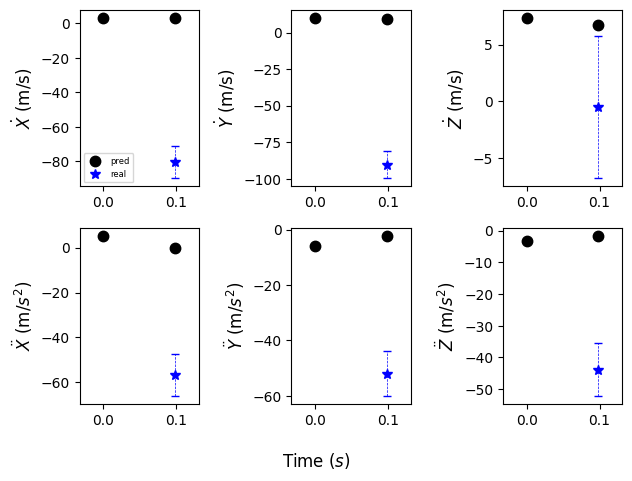

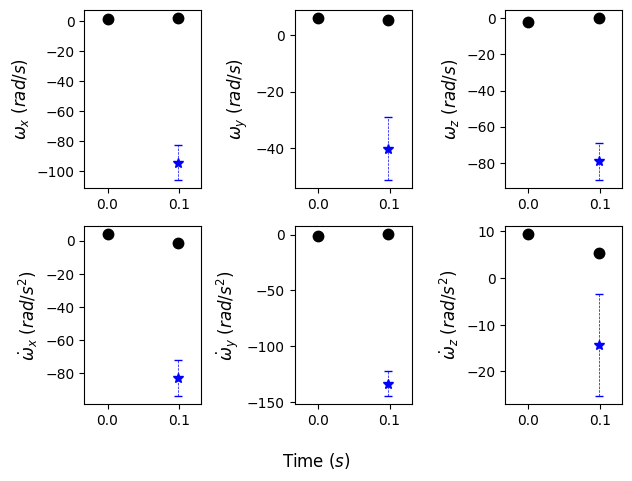

Current Batch Train Loss: 8.624539375305176

Current Batch Train Loss: -14.87265682220459

Current Batch Train Loss: -15.481108665466309

Current Batch Train Loss: -15.3602876663208

Current Batch Train Loss: -15.928987503051758

Epoch: 1, Batch Testing Loss: -16.002220153808594, Batch Testing Average RMSE: 39.35447692871094 w/ Standard Deviation: 18.546329498291016
Batch Testing Average NLL: 4.585346221923828 w/ Standard Deviation: 4.506260871887207

Average Absolute Prediction Error (AAE) of Plotted Sample: 26.597190856933594


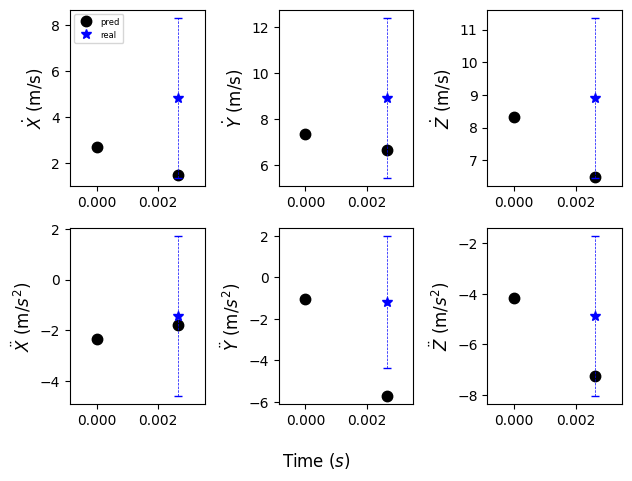

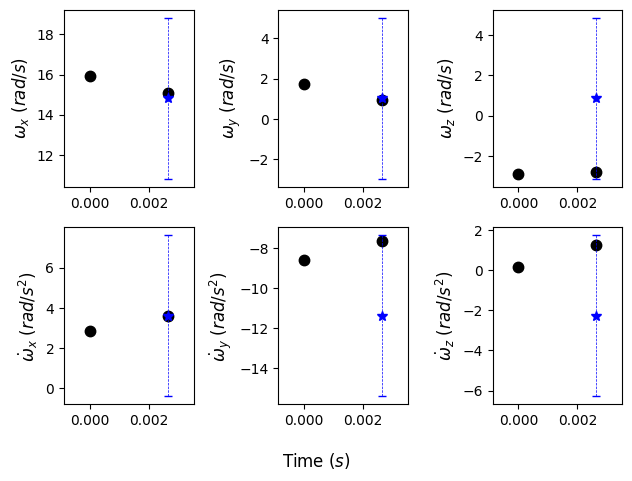

Current Batch Train Loss: -16.076507568359375

Current Batch Train Loss: -16.04783058166504

Current Batch Train Loss: -16.17340660095215

Current Batch Train Loss: -16.15376091003418

Current Batch Train Loss: -16.221982955932617

Epoch: 2, Batch Testing Loss: -16.14198875427246, Batch Testing Average RMSE: 35.71092987060547 w/ Standard Deviation: 17.604097366333008
Batch Testing Average NLL: 3.9737792015075684 w/ Standard Deviation: 3.8834054470062256

Average Absolute Prediction Error (AAE) of Plotted Sample: 73.0267105102539


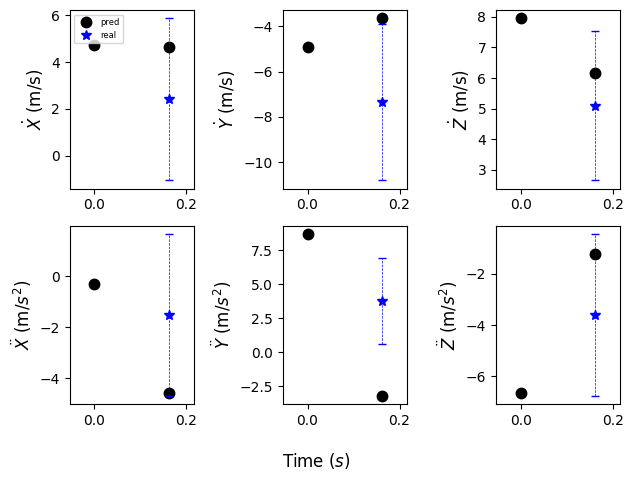

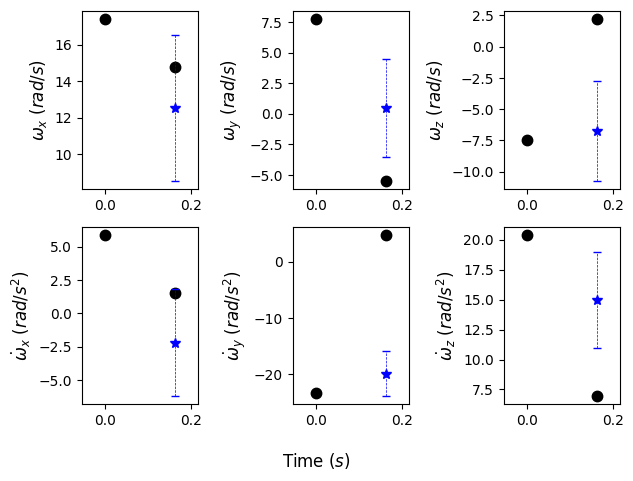

Current Batch Train Loss: -16.124483108520508

Current Batch Train Loss: -16.19059944152832

Current Batch Train Loss: -16.105398178100586

Current Batch Train Loss: -16.263368606567383

Current Batch Train Loss: -16.202592849731445

Epoch: 3, Batch Testing Loss: -16.010154724121094, Batch Testing Average RMSE: 41.23888397216797 w/ Standard Deviation: 15.630495071411133
Batch Testing Average NLL: 4.3897905349731445 w/ Standard Deviation: 2.874431848526001

Average Absolute Prediction Error (AAE) of Plotted Sample: 38.634220123291016


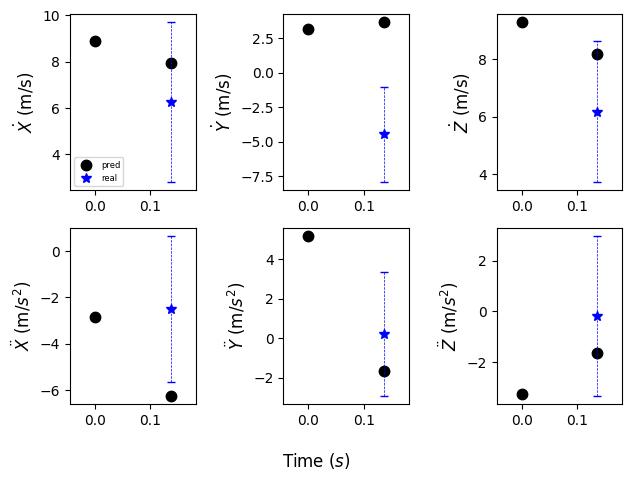

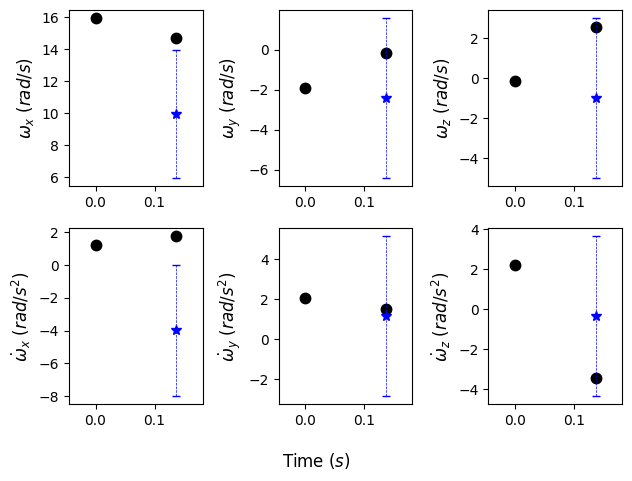

Current Batch Train Loss: -15.98625373840332

Current Batch Train Loss: -16.25584602355957

Current Batch Train Loss: -16.17667007446289

Current Batch Train Loss: -16.190704345703125

Current Batch Train Loss: -16.271493911743164

Epoch: 4, Batch Testing Loss: -16.287147521972656, Batch Testing Average RMSE: 29.783769607543945 w/ Standard Deviation: 15.321961402893066
Batch Testing Average NLL: 3.475482940673828 w/ Standard Deviation: 2.64296293258667

Average Absolute Prediction Error (AAE) of Plotted Sample: 24.396236419677734


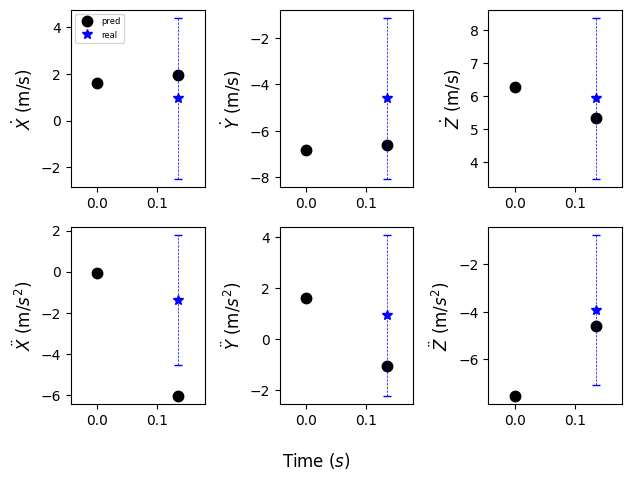

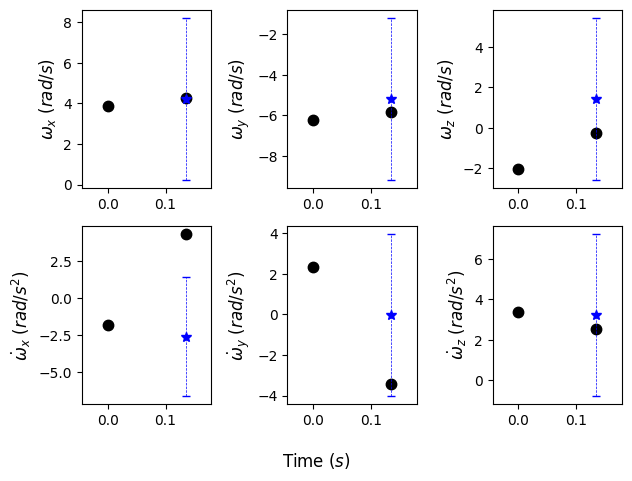

Current Batch Train Loss: -16.252309799194336

Current Batch Train Loss: -16.270742416381836

Current Batch Train Loss: -16.253339767456055

Current Batch Train Loss: -16.272268295288086

Current Batch Train Loss: -16.256019592285156

Epoch: 5, Batch Testing Loss: -16.290679931640625, Batch Testing Average RMSE: 29.066211700439453 w/ Standard Deviation: 17.545989990234375
Batch Testing Average NLL: 3.590557336807251 w/ Standard Deviation: 3.4559519290924072

Average Absolute Prediction Error (AAE) of Plotted Sample: 54.39193344116211


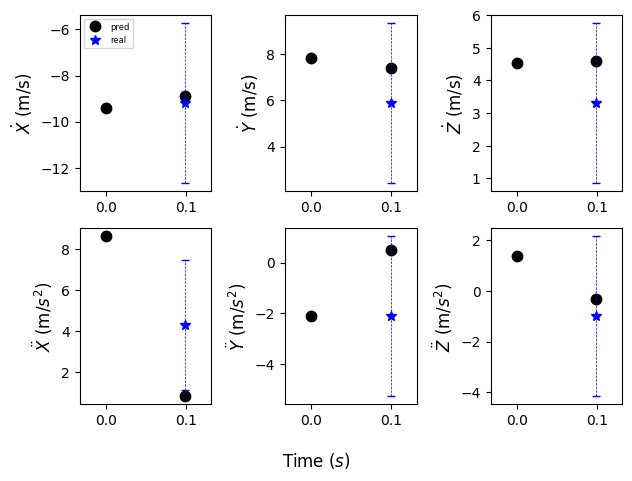

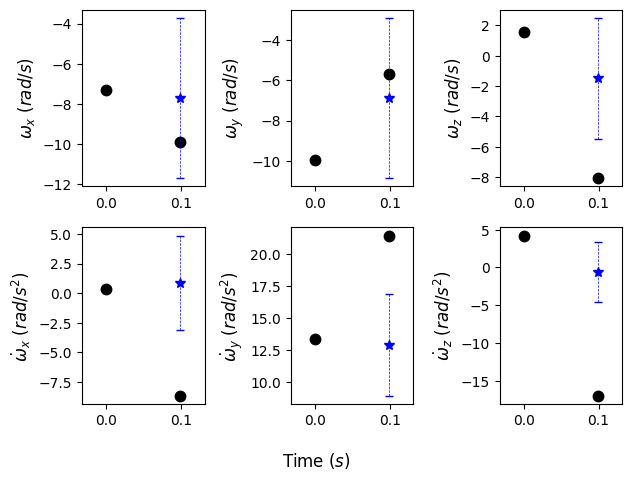

Current Batch Train Loss: -16.292116165161133

Current Batch Train Loss: -16.24895477294922

Current Batch Train Loss: -16.161645889282227

Current Batch Train Loss: -16.322025299072266

Current Batch Train Loss: -16.275707244873047

Epoch: 6, Batch Testing Loss: -16.2650089263916, Batch Testing Average RMSE: 30.47452163696289 w/ Standard Deviation: 17.723188400268555
Batch Testing Average NLL: 3.714311361312866 w/ Standard Deviation: 5.177606582641602

Average Absolute Prediction Error (AAE) of Plotted Sample: 27.24839210510254


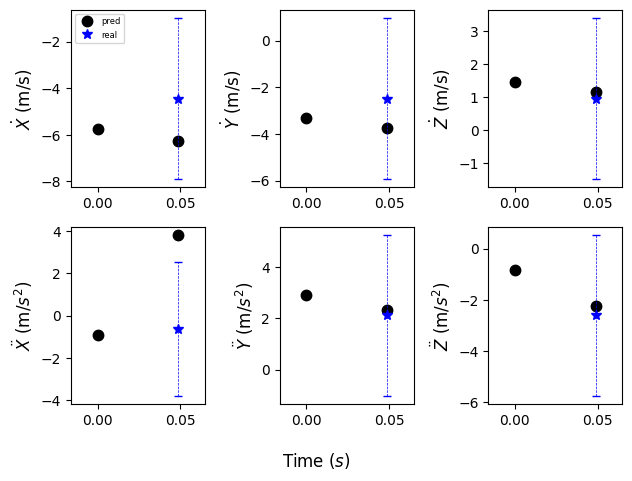

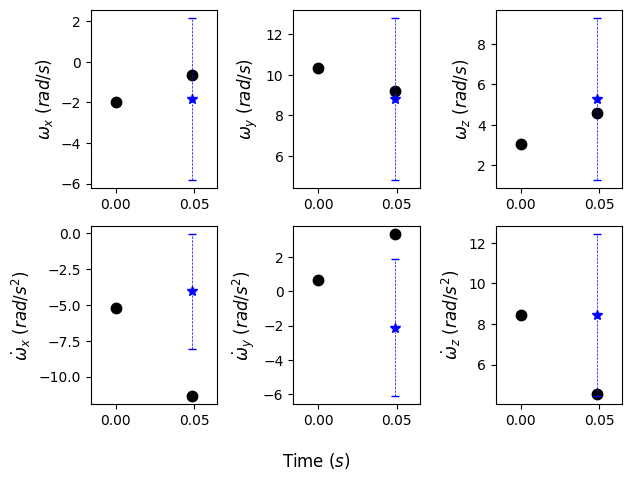

Current Batch Train Loss: -16.291580200195312

Current Batch Train Loss: -16.270992279052734

Current Batch Train Loss: -16.289512634277344

Current Batch Train Loss: -16.2747745513916

Current Batch Train Loss: -16.285192489624023

Epoch: 7, Batch Testing Loss: -16.302234649658203, Batch Testing Average RMSE: 28.753915786743164 w/ Standard Deviation: 18.42123031616211
Batch Testing Average NLL: 3.6122403144836426 w/ Standard Deviation: 3.7746493816375732

Average Absolute Prediction Error (AAE) of Plotted Sample: 26.038471221923828


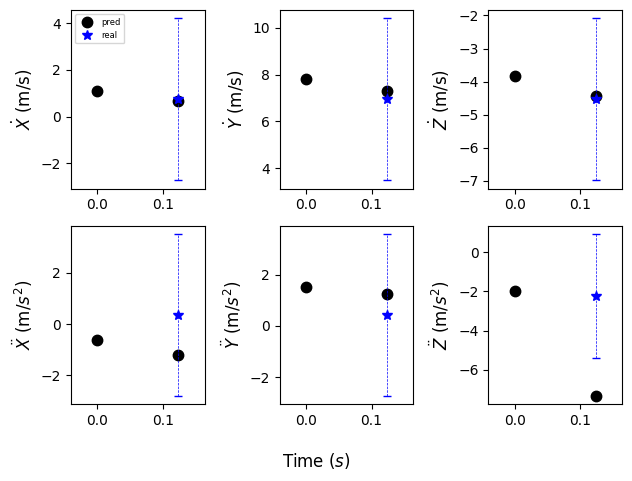

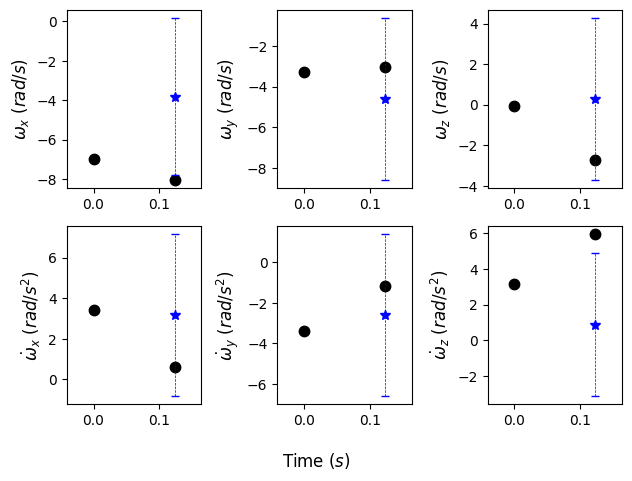

Current Batch Train Loss: -16.317888259887695

Current Batch Train Loss: -16.308246612548828

Current Batch Train Loss: -16.310304641723633

Current Batch Train Loss: -16.291513442993164

Current Batch Train Loss: -16.328664779663086

Epoch: 8, Batch Testing Loss: -16.33526039123535, Batch Testing Average RMSE: 27.612329483032227 w/ Standard Deviation: 15.468502044677734
Batch Testing Average NLL: 3.301201343536377 w/ Standard Deviation: 2.9199280738830566

Average Absolute Prediction Error (AAE) of Plotted Sample: 24.325815200805664


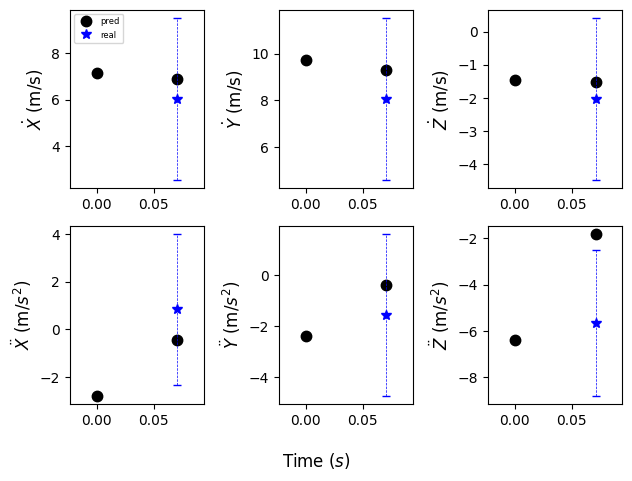

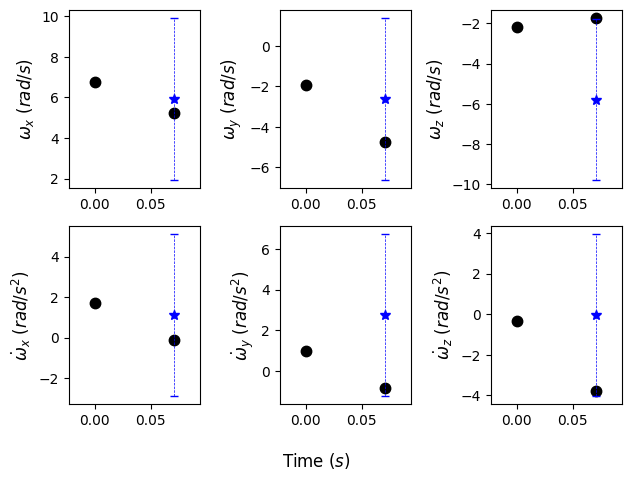

Current Batch Train Loss: -16.290945053100586

Current Batch Train Loss: -16.299413681030273

Current Batch Train Loss: -16.32281494140625

Current Batch Train Loss: -16.31903076171875

Current Batch Train Loss: -16.301544189453125

Epoch: 9, Batch Testing Loss: -16.31925392150879, Batch Testing Average RMSE: 27.78743553161621 w/ Standard Deviation: 16.73177146911621
Batch Testing Average NLL: 3.418778896331787 w/ Standard Deviation: 3.410294532775879

Average Absolute Prediction Error (AAE) of Plotted Sample: 12.495298385620117


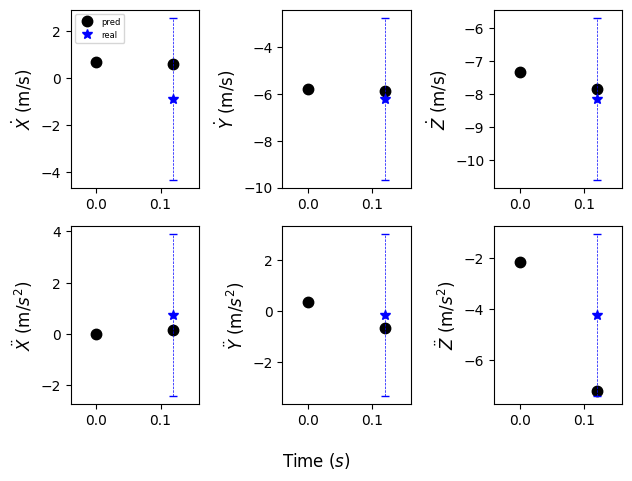

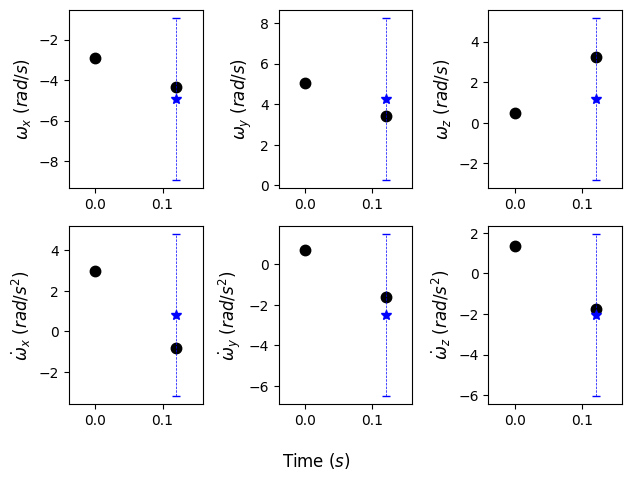

Current Batch Train Loss: -16.31432342529297

Current Batch Train Loss: -16.300392150878906

Current Batch Train Loss: -16.332080841064453

Current Batch Train Loss: -16.304765701293945

Current Batch Train Loss: -16.293256759643555

Epoch: 10, Batch Testing Loss: -16.308197021484375, Batch Testing Average RMSE: 28.365257263183594 w/ Standard Deviation: 18.157495498657227
Batch Testing Average NLL: 3.5823893547058105 w/ Standard Deviation: 4.237849712371826

Average Absolute Prediction Error (AAE) of Plotted Sample: 30.696491241455078


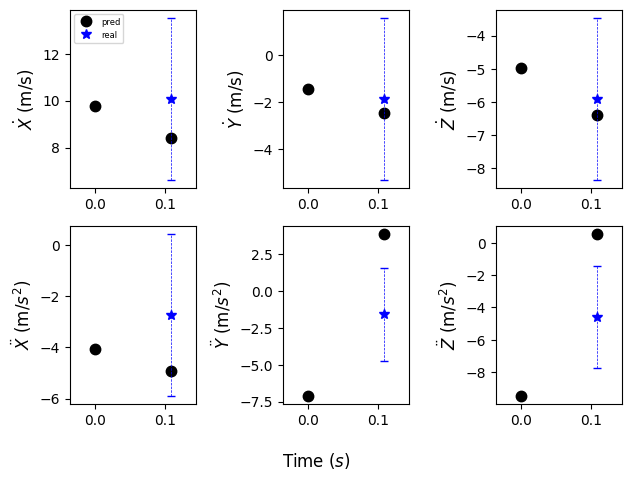

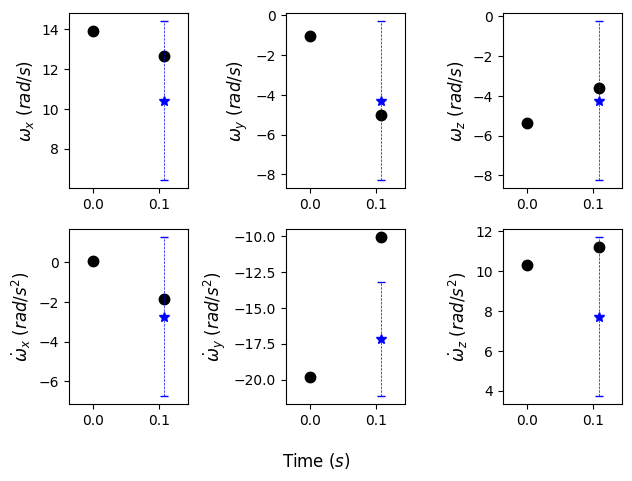

Current Batch Train Loss: -16.337779998779297

Current Batch Train Loss: -16.312532424926758

Current Batch Train Loss: -16.31574821472168

Current Batch Train Loss: -16.304224014282227

Current Batch Train Loss: -16.299936294555664

Epoch: 11, Batch Testing Loss: -16.32559585571289, Batch Testing Average RMSE: 27.86412239074707 w/ Standard Deviation: 17.922563552856445
Batch Testing Average NLL: 3.428955316543579 w/ Standard Deviation: 3.6541385650634766

Average Absolute Prediction Error (AAE) of Plotted Sample: 17.683422088623047


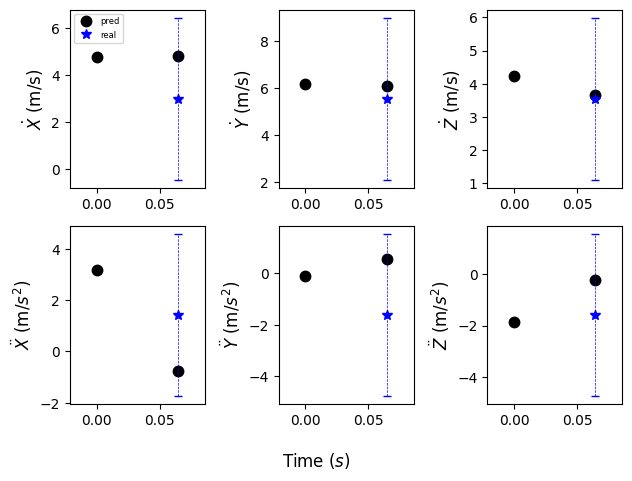

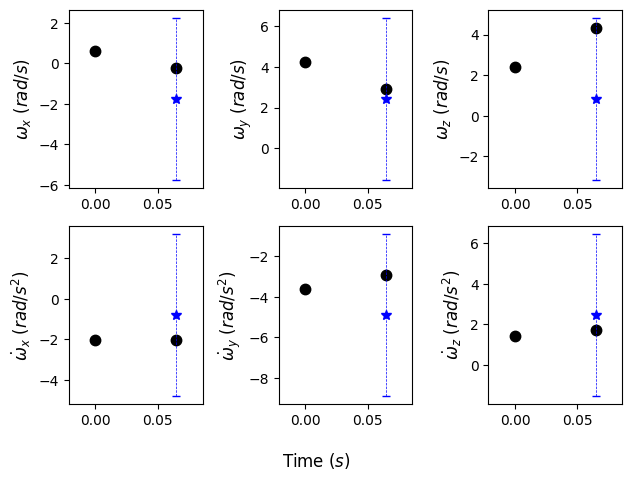

Current Batch Train Loss: -16.309974670410156

Current Batch Train Loss: -16.318462371826172

Current Batch Train Loss: -16.318988800048828

Current Batch Train Loss: -16.3055477142334

Current Batch Train Loss: -16.3173828125

Epoch: 12, Batch Testing Loss: -16.316394805908203, Batch Testing Average RMSE: 27.24370002746582 w/ Standard Deviation: 20.01138687133789
Batch Testing Average NLL: 3.6608166694641113 w/ Standard Deviation: 6.583302974700928

Average Absolute Prediction Error (AAE) of Plotted Sample: 17.27440643310547


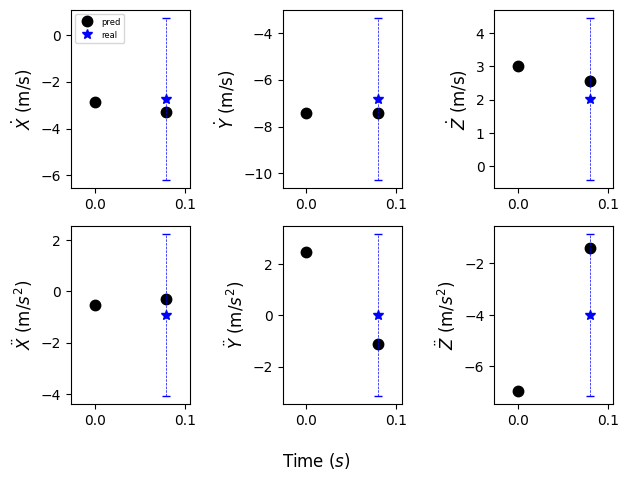

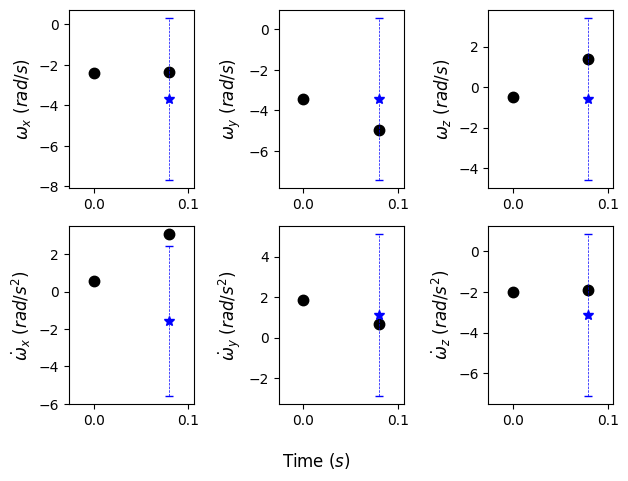

Current Batch Train Loss: -16.321273803710938

Current Batch Train Loss: -16.305118560791016

Current Batch Train Loss: -16.335742950439453

Current Batch Train Loss: -16.3497314453125

Current Batch Train Loss: -16.339570999145508

Epoch: 13, Batch Testing Loss: -16.29496955871582, Batch Testing Average RMSE: 29.0617733001709 w/ Standard Deviation: 18.657506942749023
Batch Testing Average NLL: 3.744065999984741 w/ Standard Deviation: 4.93157434463501

Average Absolute Prediction Error (AAE) of Plotted Sample: 16.460710525512695


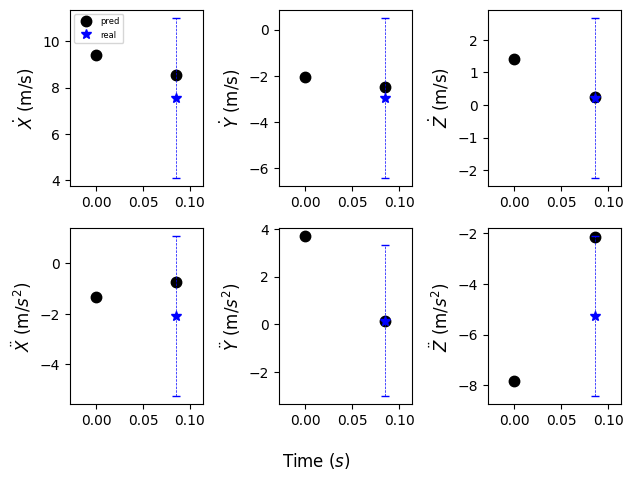

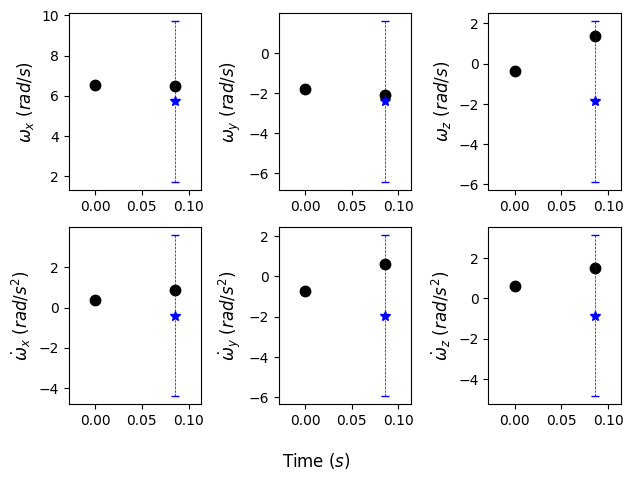

Current Batch Train Loss: -16.318723678588867

Current Batch Train Loss: -16.3237247467041

Current Batch Train Loss: -16.349441528320312

Current Batch Train Loss: -16.320322036743164

Current Batch Train Loss: -16.346994400024414

Epoch: 14, Batch Testing Loss: -16.36476707458496, Batch Testing Average RMSE: 25.611696243286133 w/ Standard Deviation: 16.509321212768555
Batch Testing Average NLL: 3.2046308517456055 w/ Standard Deviation: 2.5019478797912598

Average Absolute Prediction Error (AAE) of Plotted Sample: 28.13127899169922


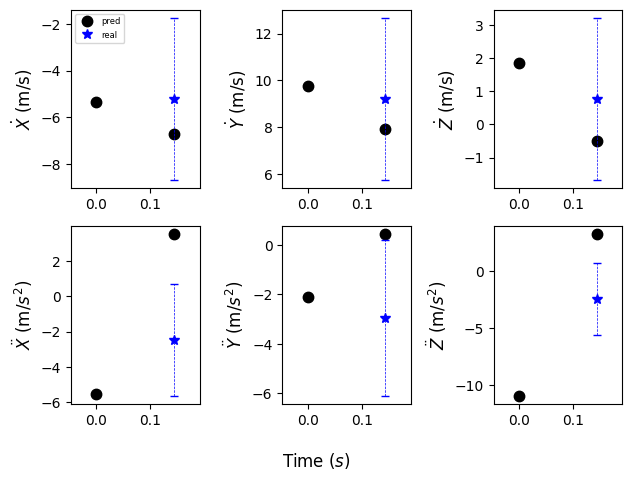

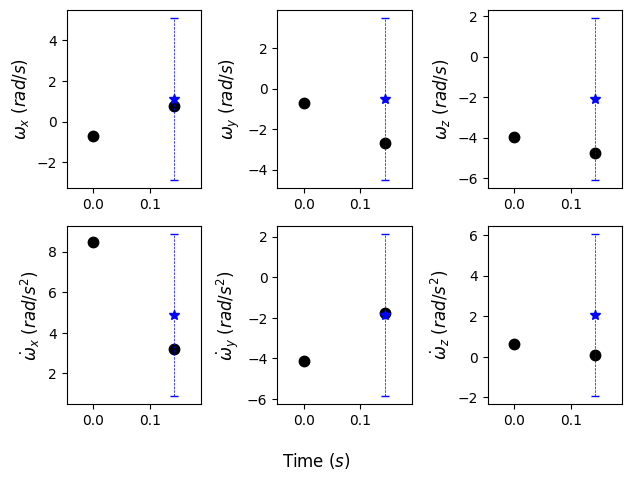

Current Batch Train Loss: -16.345033645629883

Current Batch Train Loss: -16.31267547607422

Current Batch Train Loss: -16.316816329956055

Current Batch Train Loss: -16.33504295349121

Current Batch Train Loss: -16.347562789916992

Epoch: 15, Batch Testing Loss: -16.327896118164062, Batch Testing Average RMSE: 27.435998916625977 w/ Standard Deviation: 18.19293785095215
Batch Testing Average NLL: 3.5070042610168457 w/ Standard Deviation: 3.654233932495117

Average Absolute Prediction Error (AAE) of Plotted Sample: 11.606954574584961


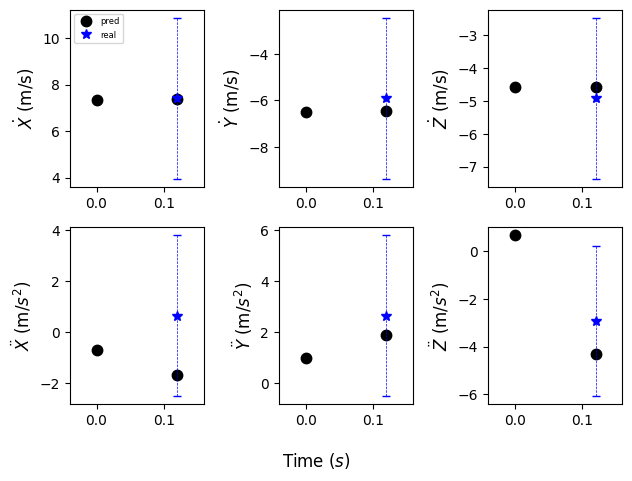

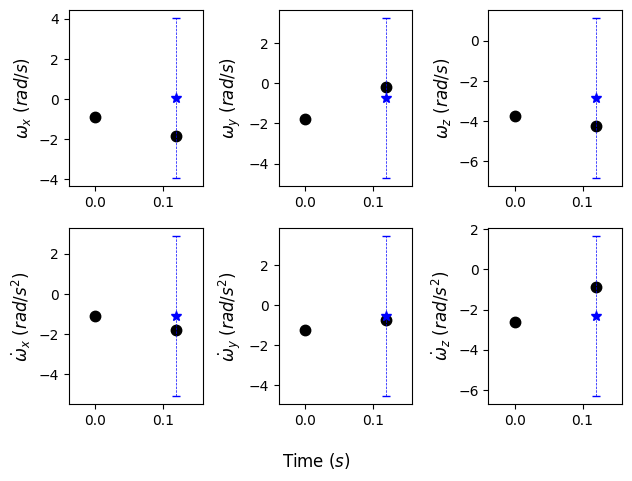

Current Batch Train Loss: -16.33489990234375

Current Batch Train Loss: -16.319183349609375

Current Batch Train Loss: -16.340164184570312

Current Batch Train Loss: -16.33190155029297

Current Batch Train Loss: -16.363874435424805

Epoch: 16, Batch Testing Loss: -16.326107025146484, Batch Testing Average RMSE: 26.950414657592773 w/ Standard Deviation: 18.82622528076172
Batch Testing Average NLL: 3.560401439666748 w/ Standard Deviation: 4.1805806159973145

Average Absolute Prediction Error (AAE) of Plotted Sample: 63.53019714355469


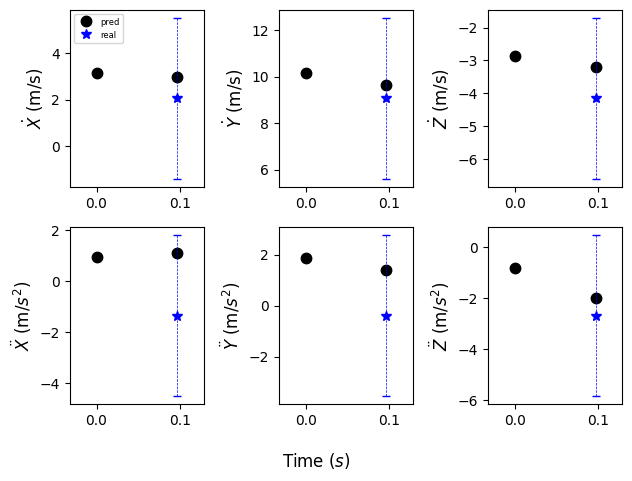

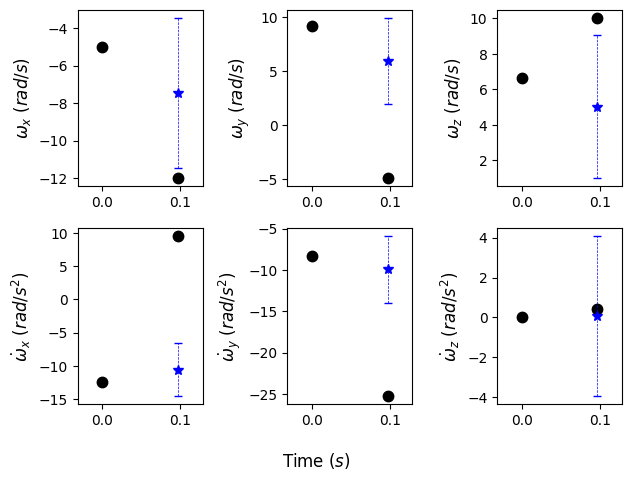

Current Batch Train Loss: -16.355792999267578

Current Batch Train Loss: -16.34596061706543

Current Batch Train Loss: -16.335813522338867

Current Batch Train Loss: -16.332866668701172

Current Batch Train Loss: -16.34149932861328

Epoch: 17, Batch Testing Loss: -16.353694915771484, Batch Testing Average RMSE: 26.298927307128906 w/ Standard Deviation: 16.89378547668457
Batch Testing Average NLL: 3.296182632446289 w/ Standard Deviation: 3.371225595474243

Average Absolute Prediction Error (AAE) of Plotted Sample: 18.651065826416016


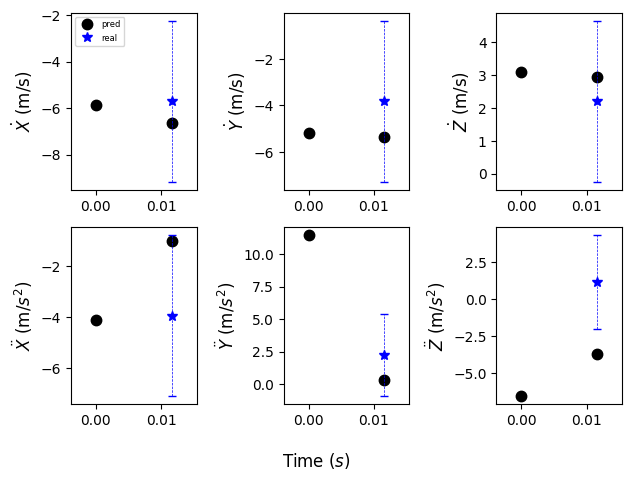

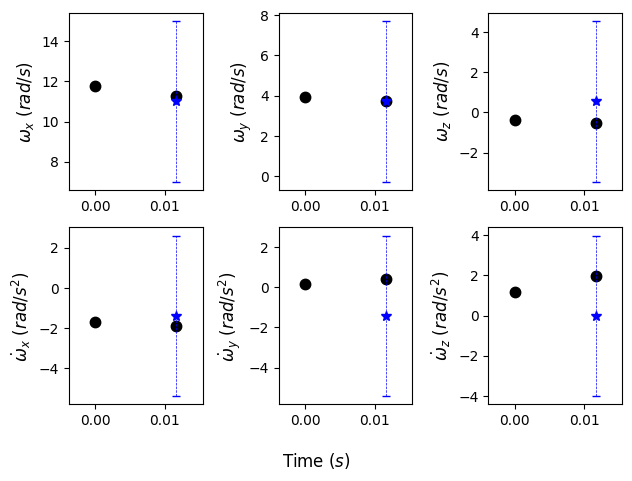

Current Batch Train Loss: -16.331527709960938

Current Batch Train Loss: -16.329500198364258

Current Batch Train Loss: -16.336660385131836

Current Batch Train Loss: -16.32170867919922

Current Batch Train Loss: -16.355724334716797

Epoch: 18, Batch Testing Loss: -16.35844612121582, Batch Testing Average RMSE: 25.78757095336914 w/ Standard Deviation: 17.071441650390625
Batch Testing Average NLL: 3.305469512939453 w/ Standard Deviation: 2.9791934490203857

Average Absolute Prediction Error (AAE) of Plotted Sample: 51.37379455566406


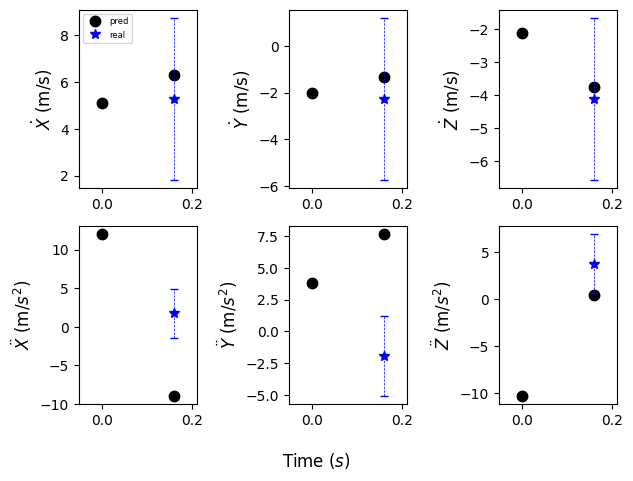

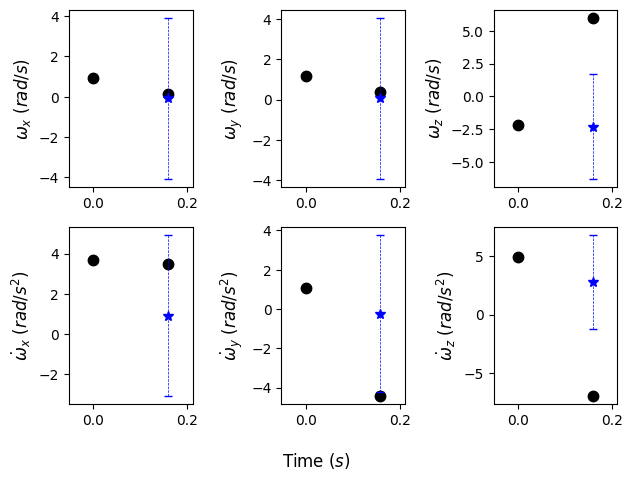

Current Batch Train Loss: -16.325368881225586

Current Batch Train Loss: -16.332399368286133

Current Batch Train Loss: -16.32622718811035

Current Batch Train Loss: -16.35675811767578

Current Batch Train Loss: -16.326343536376953

Epoch: 19, Batch Testing Loss: -16.360750198364258, Batch Testing Average RMSE: 25.13911247253418 w/ Standard Deviation: 17.482728958129883
Batch Testing Average NLL: 3.295886516571045 w/ Standard Deviation: 3.434997320175171

Average Absolute Prediction Error (AAE) of Plotted Sample: 27.202861785888672


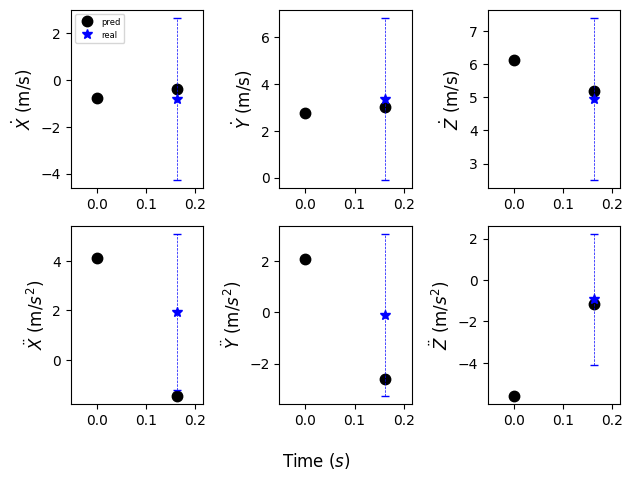

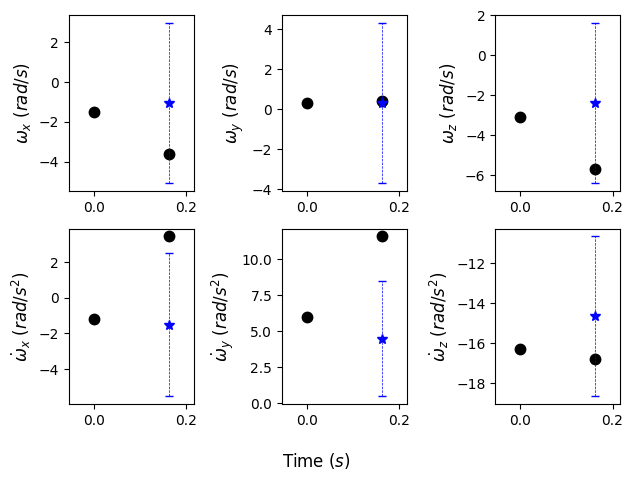

Current Batch Train Loss: -16.364099502563477

Current Batch Train Loss: -16.339712142944336

Current Batch Train Loss: -16.34659194946289

Current Batch Train Loss: -16.33045196533203

Current Batch Train Loss: -16.3493595123291

Epoch: 20, Batch Testing Loss: -16.345115661621094, Batch Testing Average RMSE: 25.947021484375 w/ Standard Deviation: 18.32475471496582
Batch Testing Average NLL: 3.415890693664551 w/ Standard Deviation: 3.986053705215454

Average Absolute Prediction Error (AAE) of Plotted Sample: 12.279953002929688


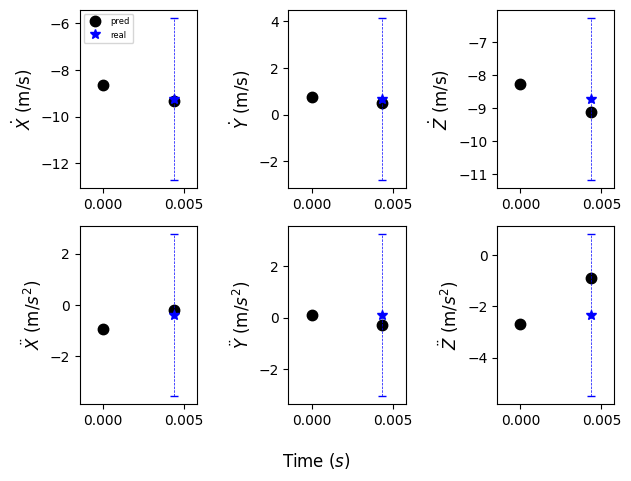

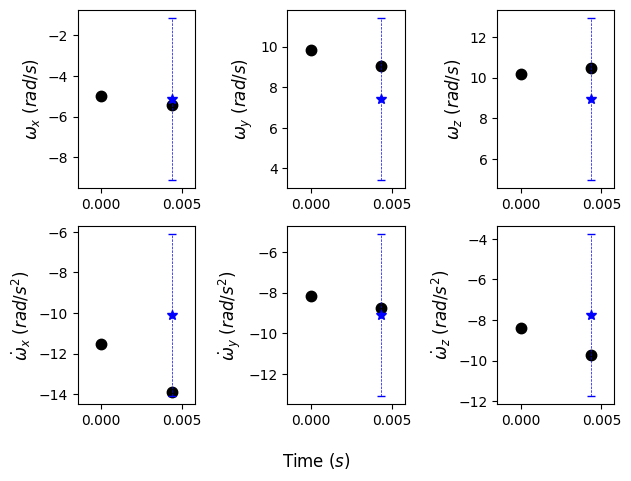

Current Batch Train Loss: -16.331912994384766

Current Batch Train Loss: -16.33786964416504

Current Batch Train Loss: -16.319490432739258

Current Batch Train Loss: -16.36151123046875

Current Batch Train Loss: -16.338842391967773

Epoch: 21, Batch Testing Loss: -16.352231979370117, Batch Testing Average RMSE: 25.598304748535156 w/ Standard Deviation: 17.56396484375
Batch Testing Average NLL: 3.33442759513855 w/ Standard Deviation: 3.447542428970337

Average Absolute Prediction Error (AAE) of Plotted Sample: 10.162155151367188


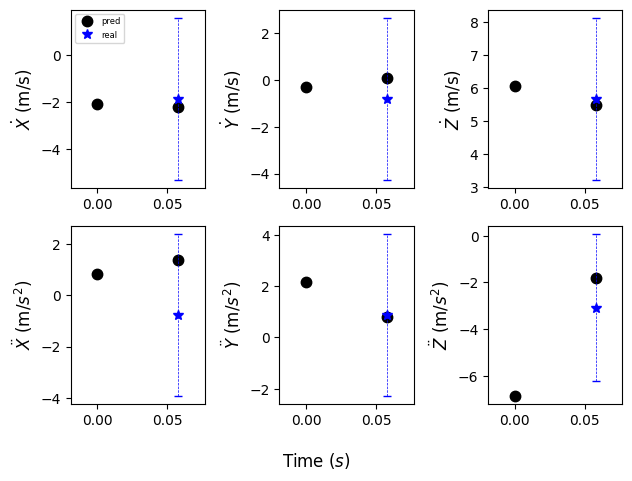

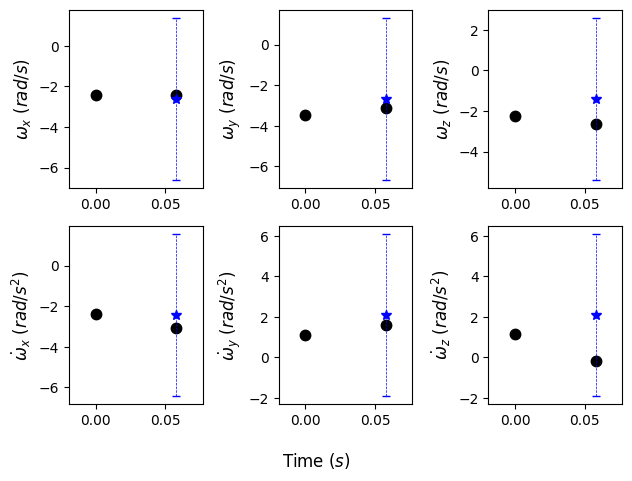

Current Batch Train Loss: -16.348350524902344

Current Batch Train Loss: -16.343034744262695

Current Batch Train Loss: -16.344707489013672

Current Batch Train Loss: -16.347837448120117

Current Batch Train Loss: -16.336917877197266

Epoch: 22, Batch Testing Loss: -16.325349807739258, Batch Testing Average RMSE: 27.021692276000977 w/ Standard Deviation: 19.002643585205078
Batch Testing Average NLL: 3.5890204906463623 w/ Standard Deviation: 4.393748760223389

Average Absolute Prediction Error (AAE) of Plotted Sample: 32.044532775878906


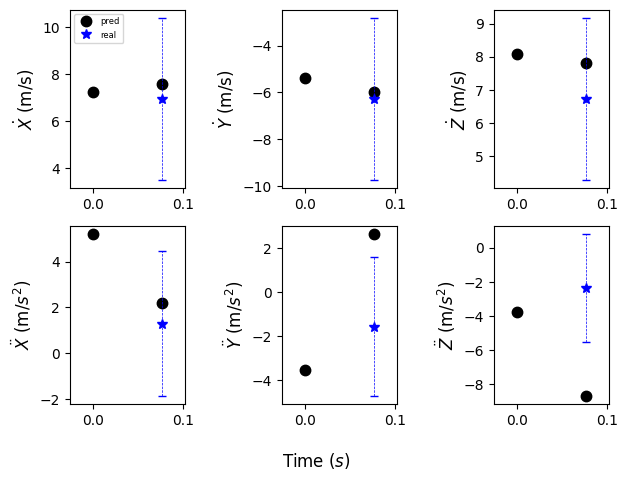

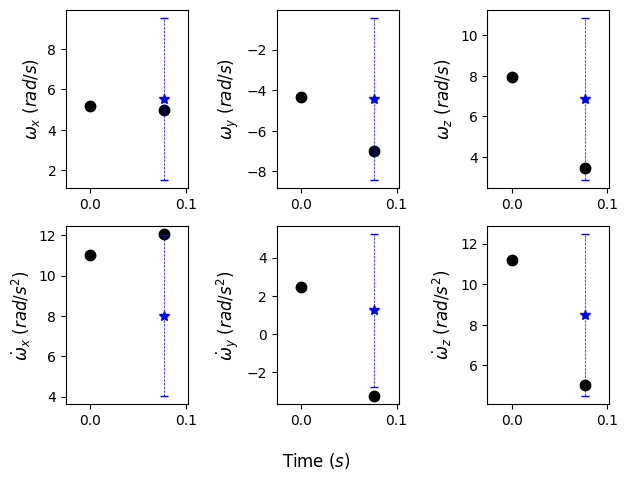

Current Batch Train Loss: -16.324167251586914

Current Batch Train Loss: -16.348745346069336

Current Batch Train Loss: -16.355791091918945

Current Batch Train Loss: -16.353525161743164

Current Batch Train Loss: -16.349279403686523

Epoch: 23, Batch Testing Loss: -16.325817108154297, Batch Testing Average RMSE: 26.90684700012207 w/ Standard Deviation: 19.74983787536621
Batch Testing Average NLL: 3.647401809692383 w/ Standard Deviation: 4.526738166809082

Average Absolute Prediction Error (AAE) of Plotted Sample: 15.269054412841797


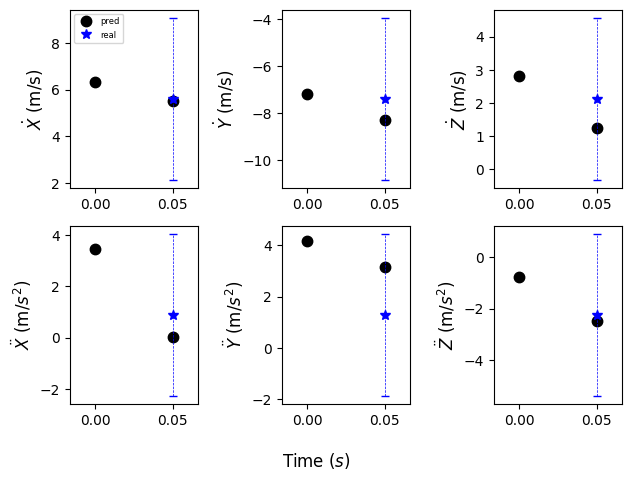

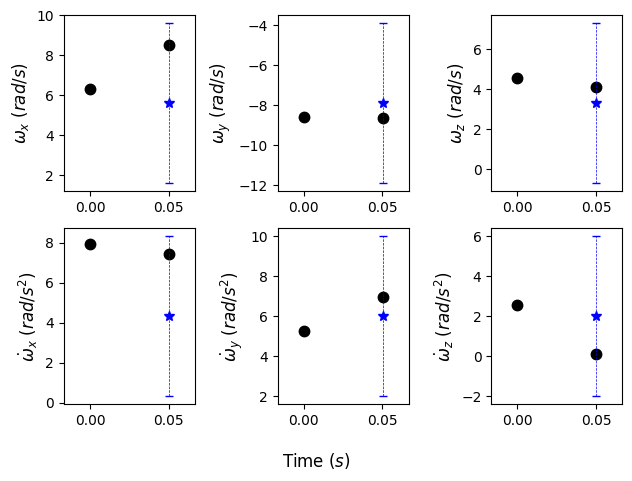

Current Batch Train Loss: -16.35511016845703

Current Batch Train Loss: -16.346378326416016

Current Batch Train Loss: -16.353992462158203

Current Batch Train Loss: -16.350452423095703

Current Batch Train Loss: -16.352460861206055

Epoch: 24, Batch Testing Loss: -16.346763610839844, Batch Testing Average RMSE: 26.309608459472656 w/ Standard Deviation: 16.96928596496582
Batch Testing Average NLL: 3.3958325386047363 w/ Standard Deviation: 3.2147367000579834

Average Absolute Prediction Error (AAE) of Plotted Sample: 21.714801788330078


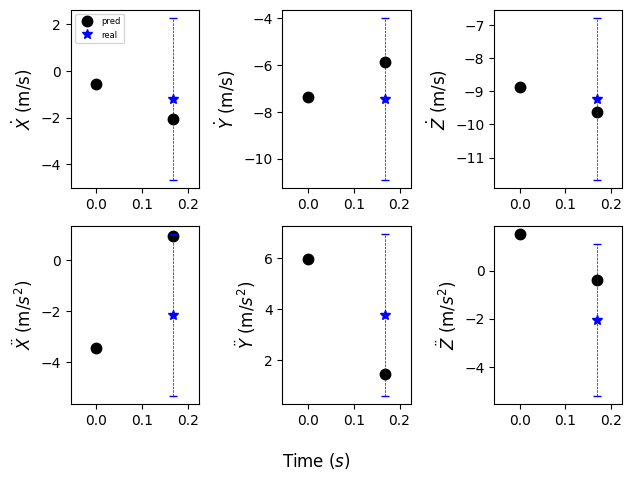

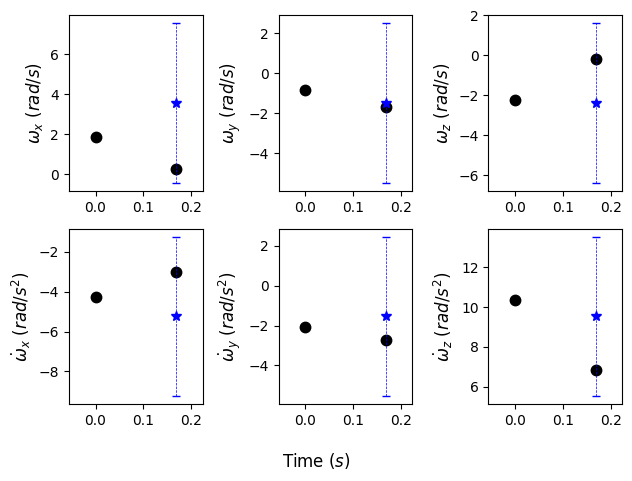

Current Batch Train Loss: -16.353710174560547

Current Batch Train Loss: -16.340238571166992

Current Batch Train Loss: -16.33805274963379

Current Batch Train Loss: -16.357351303100586

Current Batch Train Loss: -16.35280990600586

Epoch: 25, Batch Testing Loss: -16.35582733154297, Batch Testing Average RMSE: 25.417278289794922 w/ Standard Deviation: 17.255250930786133
Batch Testing Average NLL: 3.3141117095947266 w/ Standard Deviation: 3.3515329360961914

Average Absolute Prediction Error (AAE) of Plotted Sample: 19.817031860351562


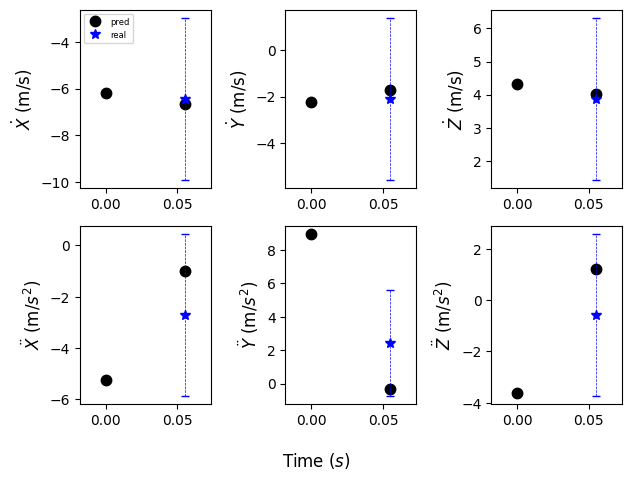

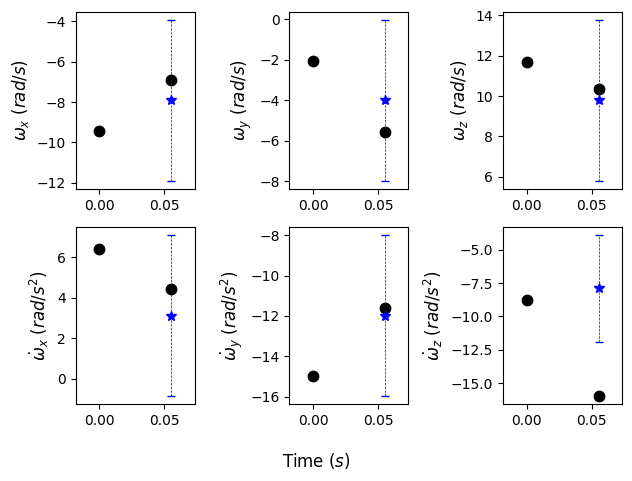

Current Batch Train Loss: -16.346168518066406

Current Batch Train Loss: -16.339818954467773

Current Batch Train Loss: -16.351409912109375

Current Batch Train Loss: -16.355470657348633

Current Batch Train Loss: -16.340734481811523

Epoch: 26, Batch Testing Loss: -16.33314323425293, Batch Testing Average RMSE: 26.27971839904785 w/ Standard Deviation: 19.003021240234375
Batch Testing Average NLL: 3.554215669631958 w/ Standard Deviation: 4.357081890106201

Average Absolute Prediction Error (AAE) of Plotted Sample: 9.481887817382812


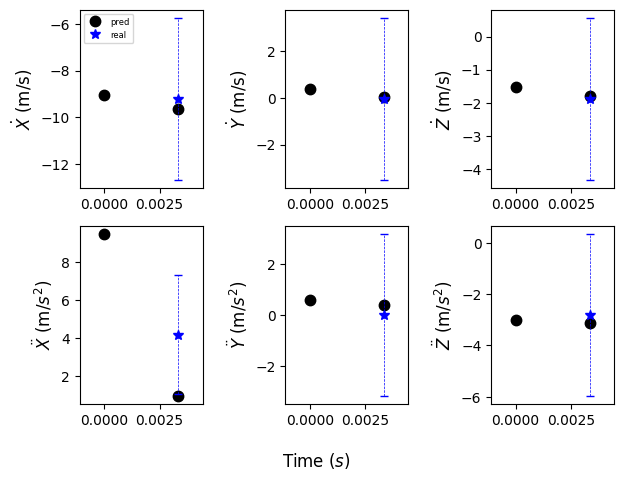

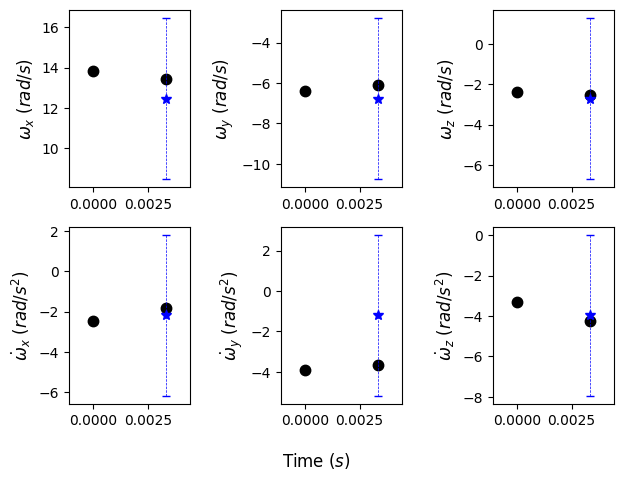

Current Batch Train Loss: -16.35411834716797

Current Batch Train Loss: -16.343334197998047

Current Batch Train Loss: -16.34005355834961

Current Batch Train Loss: -16.293363571166992

Current Batch Train Loss: -16.34864044189453

Epoch: 27, Batch Testing Loss: -16.349763870239258, Batch Testing Average RMSE: 25.94143295288086 w/ Standard Deviation: 17.498910903930664
Batch Testing Average NLL: 3.3899505138397217 w/ Standard Deviation: 3.648524284362793

Average Absolute Prediction Error (AAE) of Plotted Sample: 17.837263107299805


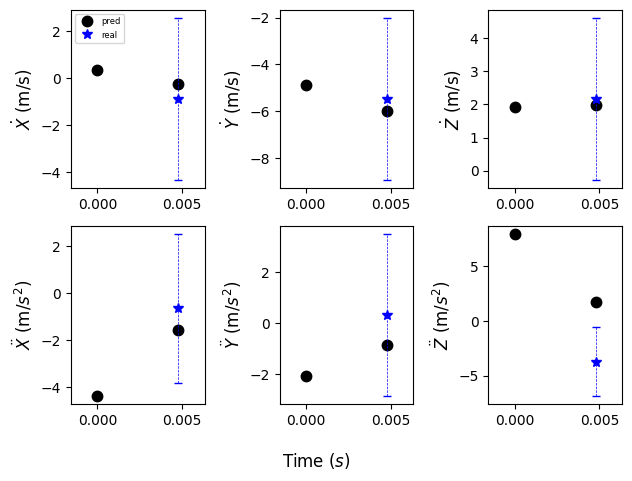

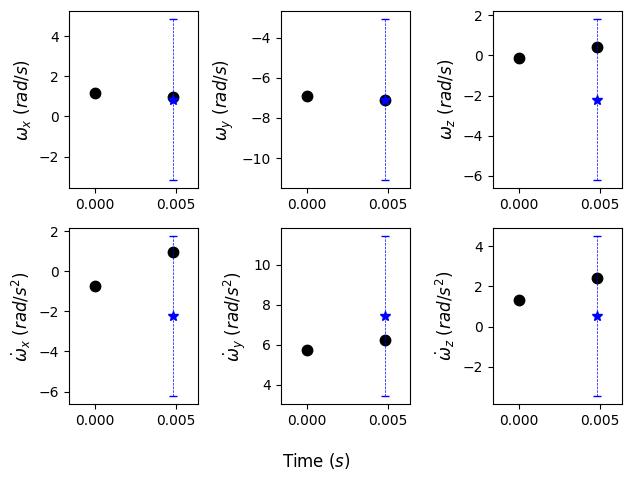

Current Batch Train Loss: -16.344938278198242

Current Batch Train Loss: -16.364686965942383

Current Batch Train Loss: -16.349367141723633

Current Batch Train Loss: -16.348020553588867

Current Batch Train Loss: -16.350543975830078

Epoch: 28, Batch Testing Loss: -16.343503952026367, Batch Testing Average RMSE: 26.913122177124023 w/ Standard Deviation: 16.899181365966797
Batch Testing Average NLL: 3.4114134311676025 w/ Standard Deviation: 3.339188575744629

Average Absolute Prediction Error (AAE) of Plotted Sample: 26.333221435546875


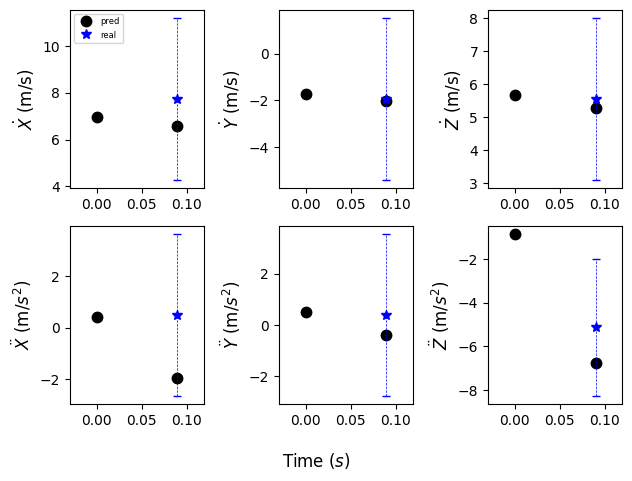

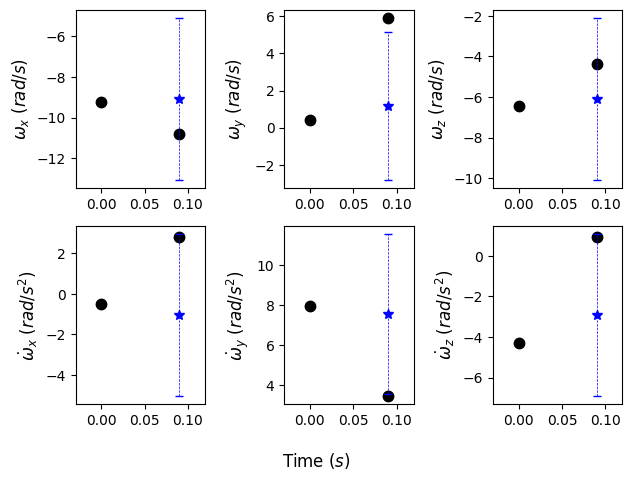

Current Batch Train Loss: -16.330766677856445

Current Batch Train Loss: -16.33794593811035

Current Batch Train Loss: -16.330596923828125

Current Batch Train Loss: -16.31351661682129

Current Batch Train Loss: -16.356517791748047

Epoch: 29, Batch Testing Loss: -16.3560733795166, Batch Testing Average RMSE: 24.748065948486328 w/ Standard Deviation: 18.640304565429688
Batch Testing Average NLL: 3.3838813304901123 w/ Standard Deviation: 5.992624282836914

Average Absolute Prediction Error (AAE) of Plotted Sample: 17.37649917602539


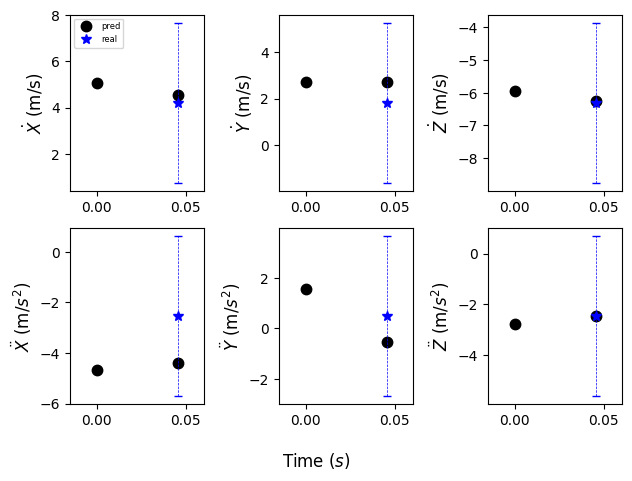

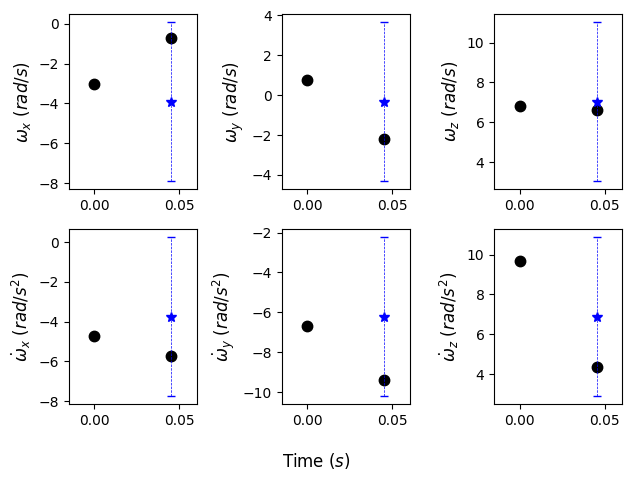

Current Batch Train Loss: -16.360450744628906

Current Batch Train Loss: -16.37587547302246

Current Batch Train Loss: -16.326210021972656

Current Batch Train Loss: -16.33418846130371

Current Batch Train Loss: -16.364871978759766

Epoch: 30, Batch Testing Loss: -16.351303100585938, Batch Testing Average RMSE: 25.60089874267578 w/ Standard Deviation: 17.502357482910156
Batch Testing Average NLL: 3.3731210231781006 w/ Standard Deviation: 3.260977268218994

Average Absolute Prediction Error (AAE) of Plotted Sample: 14.226827621459961


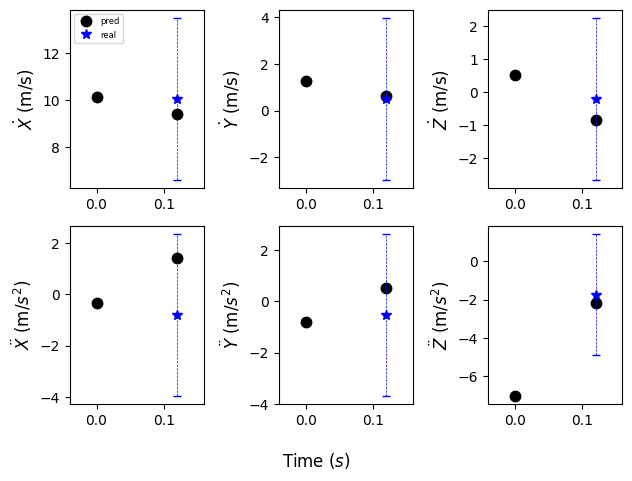

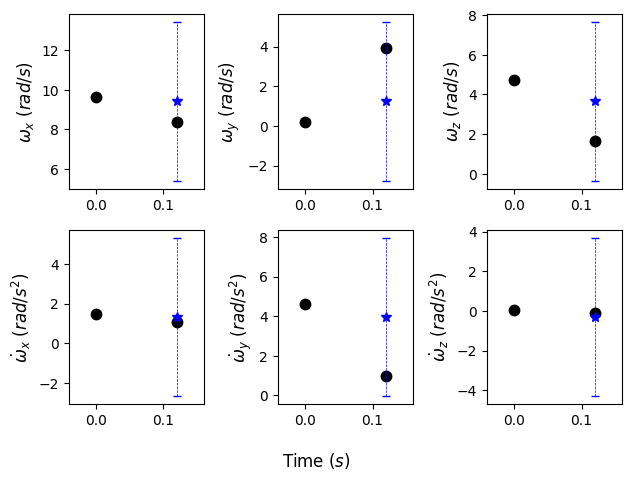

Current Batch Train Loss: -16.34225082397461

Current Batch Train Loss: -16.343196868896484

Current Batch Train Loss: -16.36741828918457

Current Batch Train Loss: -16.347822189331055

Current Batch Train Loss: -16.33622932434082

Epoch: 31, Batch Testing Loss: -16.34272575378418, Batch Testing Average RMSE: 26.81209373474121 w/ Standard Deviation: 17.757373809814453
Batch Testing Average NLL: 3.4605374336242676 w/ Standard Deviation: 3.064418315887451

Average Absolute Prediction Error (AAE) of Plotted Sample: 14.42724609375


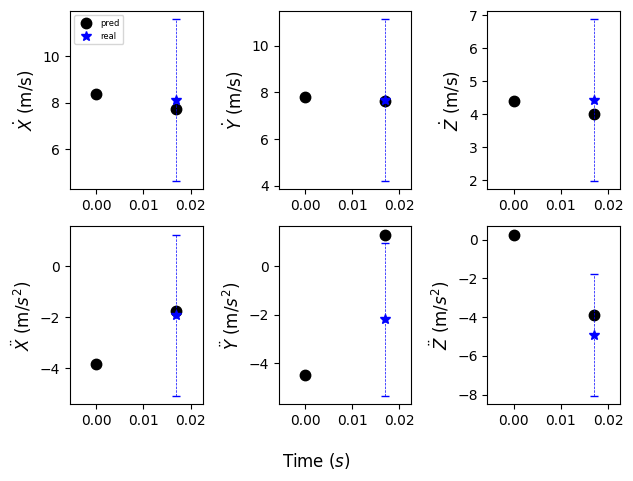

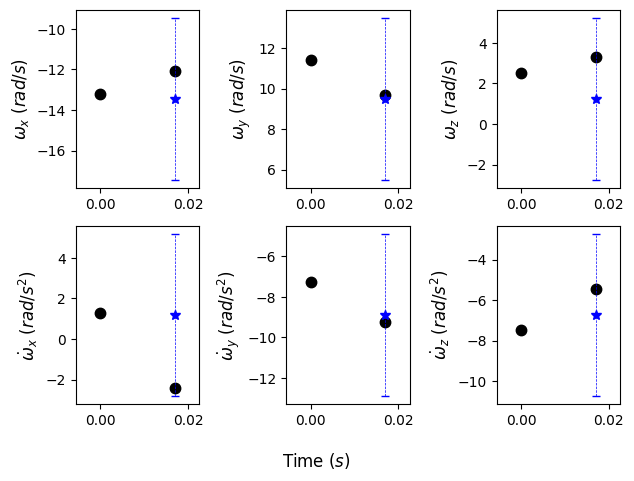

Current Batch Train Loss: -16.36544418334961

Current Batch Train Loss: -16.350324630737305

Current Batch Train Loss: -16.332990646362305

Current Batch Train Loss: -16.358980178833008

Current Batch Train Loss: -16.344558715820312

Epoch: 32, Batch Testing Loss: -16.339401245117188, Batch Testing Average RMSE: 27.414947509765625 w/ Standard Deviation: 17.720500946044922
Batch Testing Average NLL: 3.470038652420044 w/ Standard Deviation: 2.946815013885498

Average Absolute Prediction Error (AAE) of Plotted Sample: 21.531478881835938


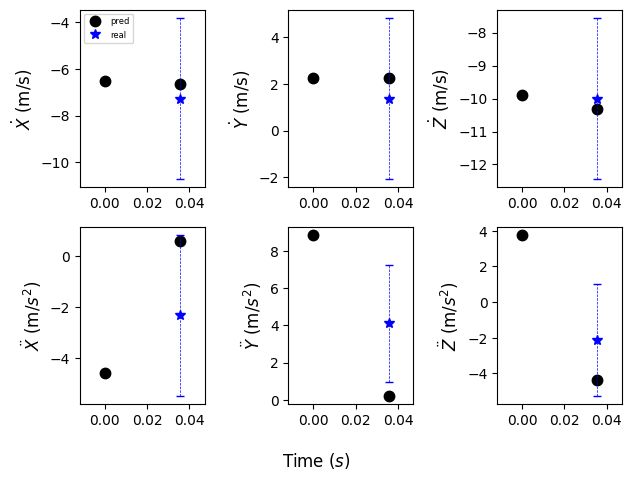

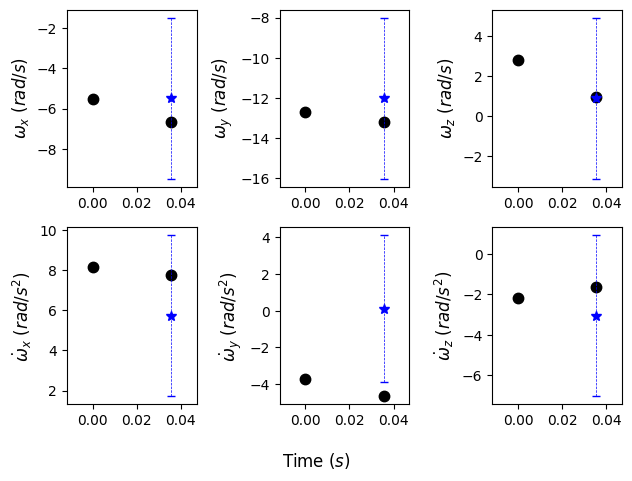

Current Batch Train Loss: -16.364757537841797

Current Batch Train Loss: -16.347593307495117

Current Batch Train Loss: -16.32775115966797

Current Batch Train Loss: -16.35576057434082

Current Batch Train Loss: -16.36275291442871

Epoch: 33, Batch Testing Loss: -16.332286834716797, Batch Testing Average RMSE: 26.668781280517578 w/ Standard Deviation: 20.2766056060791
Batch Testing Average NLL: 3.658780336380005 w/ Standard Deviation: 5.430045127868652

Average Absolute Prediction Error (AAE) of Plotted Sample: 63.420448303222656


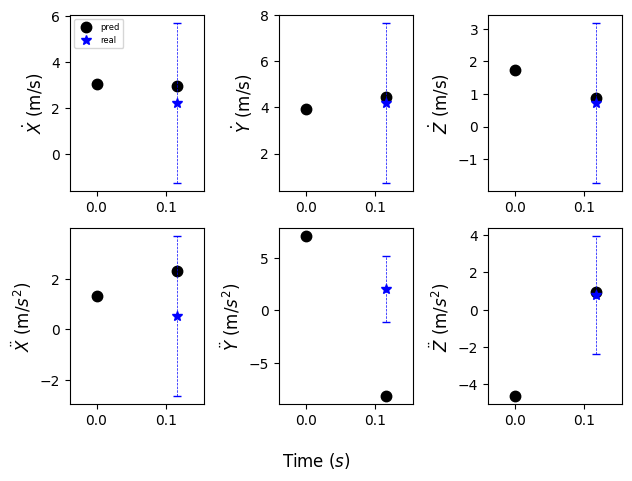

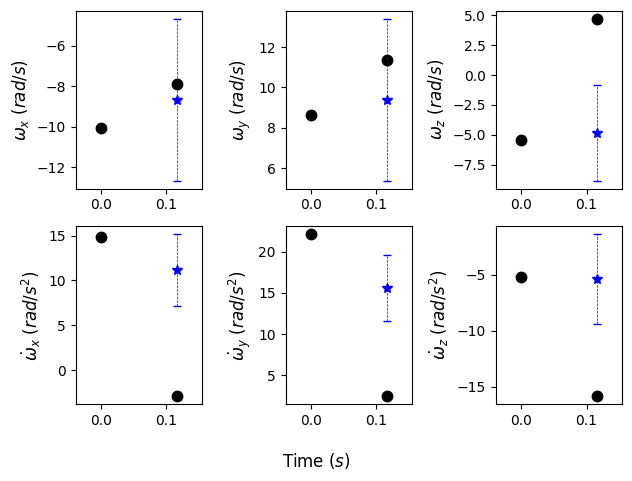

Current Batch Train Loss: -16.381017684936523

Current Batch Train Loss: -16.37081527709961

Current Batch Train Loss: -16.371910095214844

Current Batch Train Loss: -16.372636795043945

Current Batch Train Loss: -16.366830825805664

Epoch: 34, Batch Testing Loss: -16.356430053710938, Batch Testing Average RMSE: 26.367870330810547 w/ Standard Deviation: 18.438488006591797
Batch Testing Average NLL: 3.4803712368011475 w/ Standard Deviation: 3.440314292907715

Average Absolute Prediction Error (AAE) of Plotted Sample: 12.666980743408203


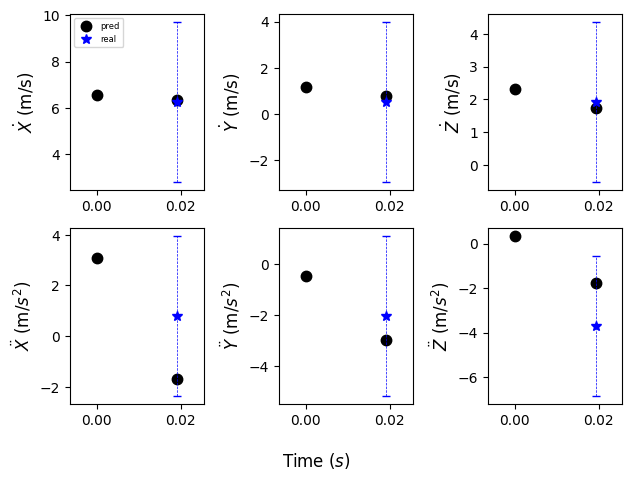

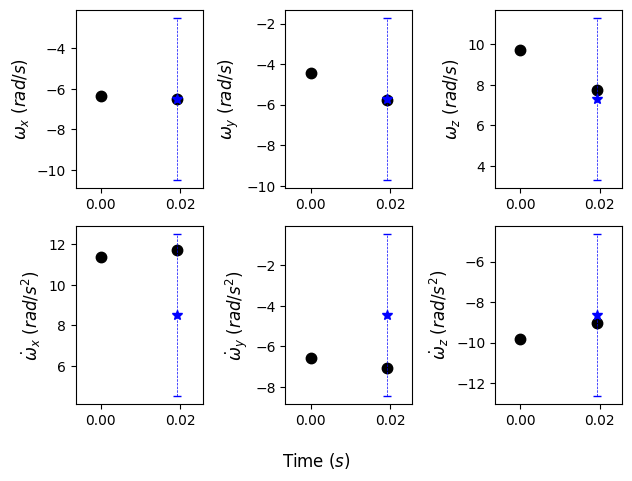

Current Batch Train Loss: -16.33684730529785

Current Batch Train Loss: -16.3730411529541

Current Batch Train Loss: -16.37916374206543

Current Batch Train Loss: -16.36586570739746

Current Batch Train Loss: -16.376306533813477

Epoch: 35, Batch Testing Loss: -16.361509323120117, Batch Testing Average RMSE: 24.425960540771484 w/ Standard Deviation: 18.836668014526367
Batch Testing Average NLL: 3.447632074356079 w/ Standard Deviation: 8.061287879943848

Average Absolute Prediction Error (AAE) of Plotted Sample: 7.796794891357422


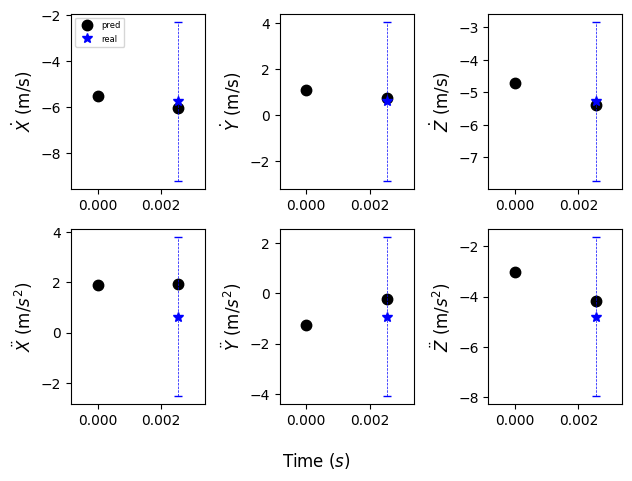

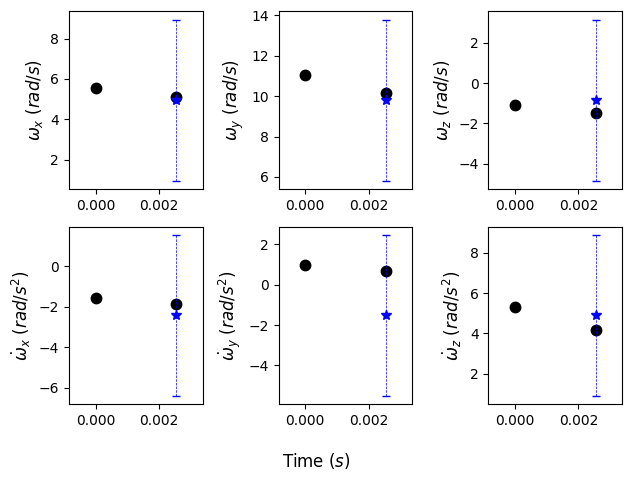

Current Batch Train Loss: -16.355323791503906

Current Batch Train Loss: -16.36163330078125

Current Batch Train Loss: -16.380970001220703

Current Batch Train Loss: -16.37213897705078

Current Batch Train Loss: -16.36945152282715

Epoch: 36, Batch Testing Loss: -16.33782958984375, Batch Testing Average RMSE: 26.158884048461914 w/ Standard Deviation: 19.646961212158203
Batch Testing Average NLL: 3.651327610015869 w/ Standard Deviation: 6.472539901733398

Average Absolute Prediction Error (AAE) of Plotted Sample: 21.42137336730957


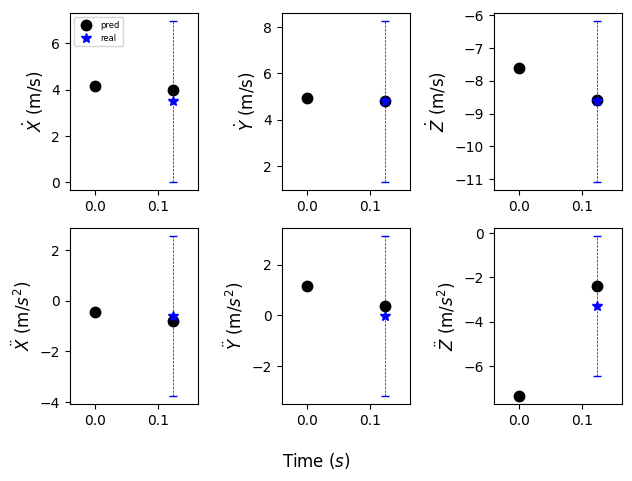

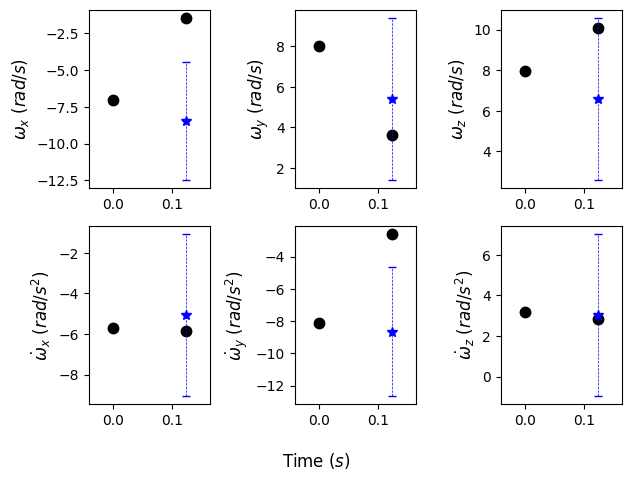

Current Batch Train Loss: -16.38026237487793

Current Batch Train Loss: -16.34996795654297

Current Batch Train Loss: -16.37596893310547

Current Batch Train Loss: -16.369855880737305

Current Batch Train Loss: -16.359529495239258

Epoch: 37, Batch Testing Loss: -16.366409301757812, Batch Testing Average RMSE: 26.392133712768555 w/ Standard Deviation: 17.39832878112793
Batch Testing Average NLL: 3.418152093887329 w/ Standard Deviation: 3.083322525024414

Average Absolute Prediction Error (AAE) of Plotted Sample: 21.272878646850586


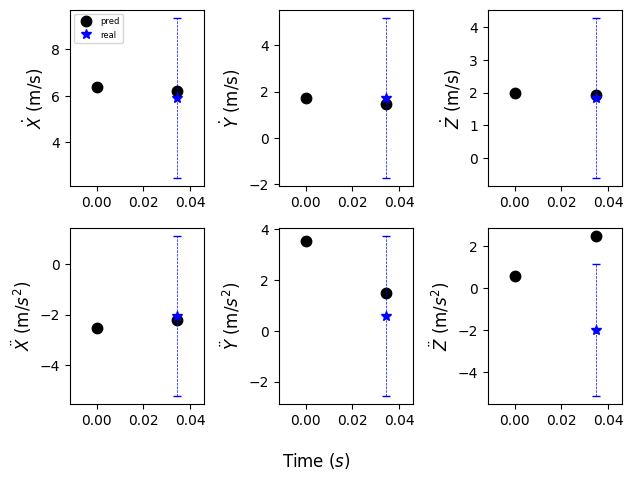

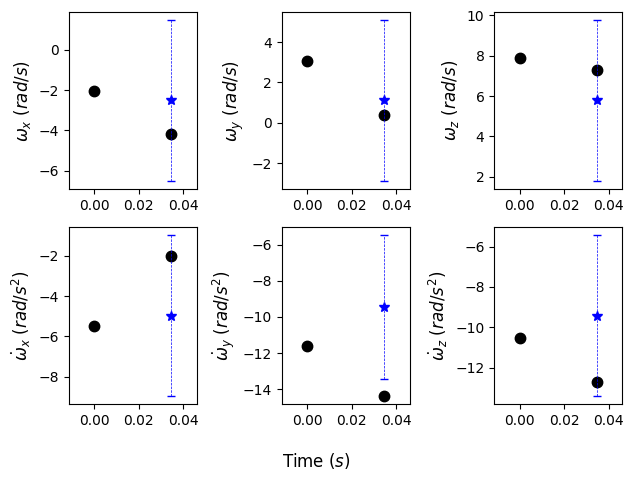

Current Batch Train Loss: -16.369985580444336

Current Batch Train Loss: -16.36294937133789

Current Batch Train Loss: -16.37621307373047

Current Batch Train Loss: -16.384397506713867

Current Batch Train Loss: -16.383251190185547

Epoch: 38, Batch Testing Loss: -16.376924514770508, Batch Testing Average RMSE: 25.518579483032227 w/ Standard Deviation: 17.620807647705078
Batch Testing Average NLL: 3.3146395683288574 w/ Standard Deviation: 3.46829891204834

Average Absolute Prediction Error (AAE) of Plotted Sample: 15.388019561767578


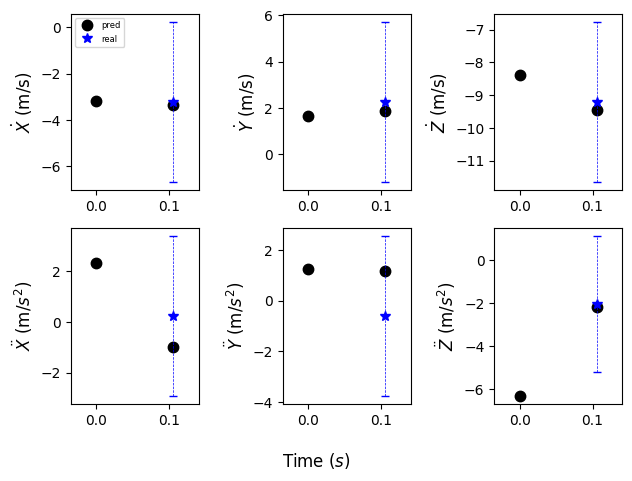

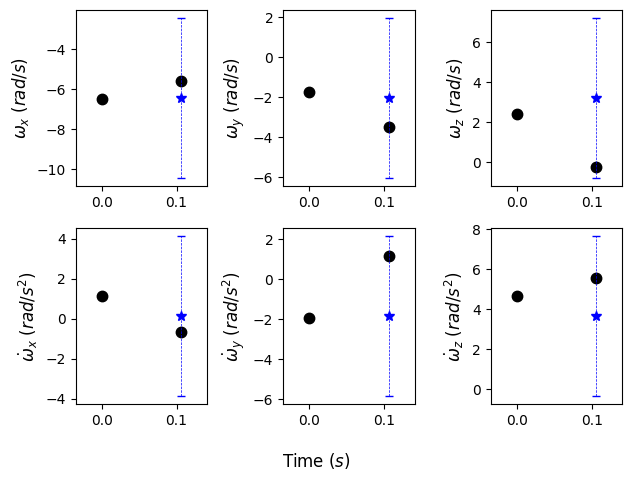

Current Batch Train Loss: -16.36068344116211

Current Batch Train Loss: -16.374183654785156

Current Batch Train Loss: -16.379610061645508

Current Batch Train Loss: -16.405488967895508

Current Batch Train Loss: -16.368488311767578

Epoch: 39, Batch Testing Loss: -16.39289093017578, Batch Testing Average RMSE: 25.250083923339844 w/ Standard Deviation: 16.20384407043457
Batch Testing Average NLL: 3.1840004920959473 w/ Standard Deviation: 2.463954210281372

Average Absolute Prediction Error (AAE) of Plotted Sample: 37.628395080566406


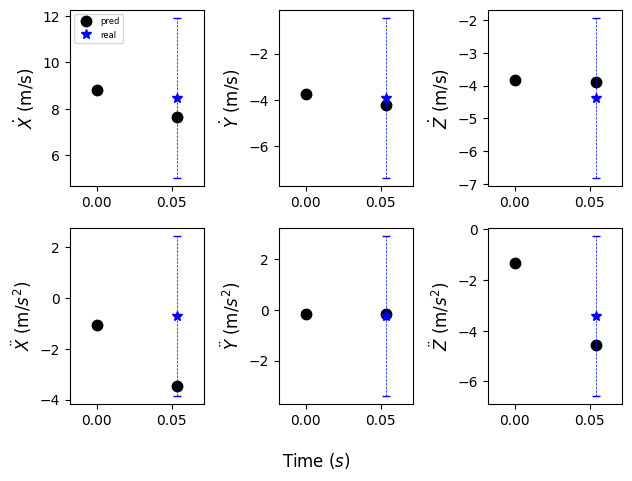

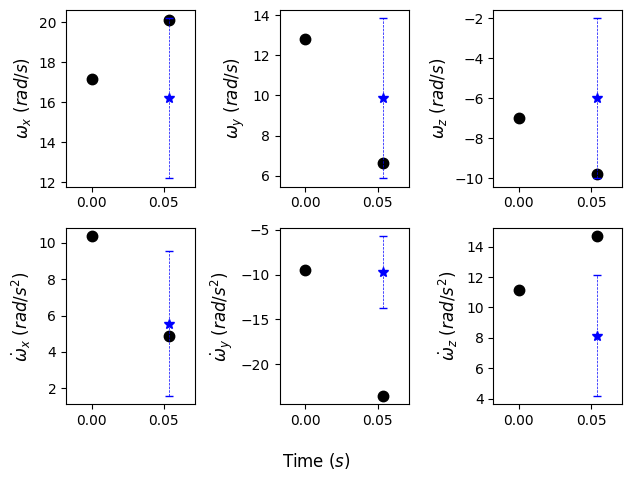

Current Batch Train Loss: -16.379703521728516

Current Batch Train Loss: -16.389232635498047

Current Batch Train Loss: -16.385974884033203

Current Batch Train Loss: -16.371641159057617

Current Batch Train Loss: -16.386308670043945

Epoch: 40, Batch Testing Loss: -16.382591247558594, Batch Testing Average RMSE: 25.788066864013672 w/ Standard Deviation: 16.661638259887695
Batch Testing Average NLL: 3.3325445652008057 w/ Standard Deviation: 3.587669610977173

Average Absolute Prediction Error (AAE) of Plotted Sample: 23.090831756591797


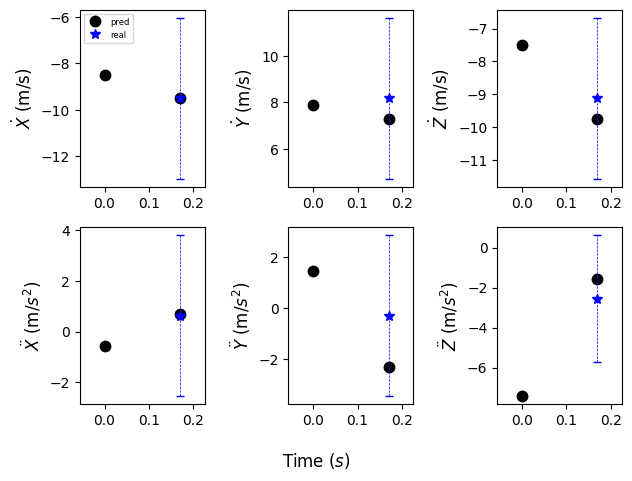

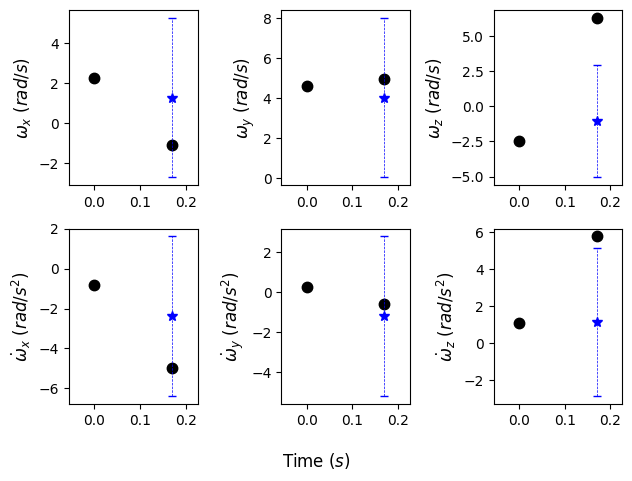

Current Batch Train Loss: -16.3681583404541

Current Batch Train Loss: -16.365835189819336

Current Batch Train Loss: -16.378543853759766

Current Batch Train Loss: -16.378280639648438

Current Batch Train Loss: -16.368789672851562

Epoch: 41, Batch Testing Loss: -16.392284393310547, Batch Testing Average RMSE: 25.200340270996094 w/ Standard Deviation: 16.732412338256836
Batch Testing Average NLL: 3.2564697265625 w/ Standard Deviation: 2.9858813285827637

Average Absolute Prediction Error (AAE) of Plotted Sample: 11.234685897827148


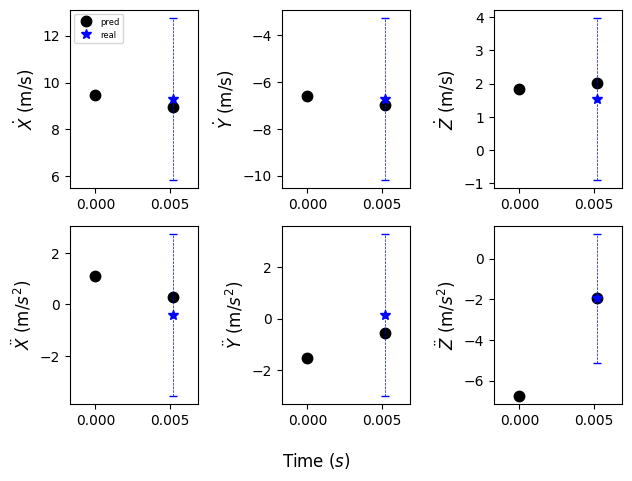

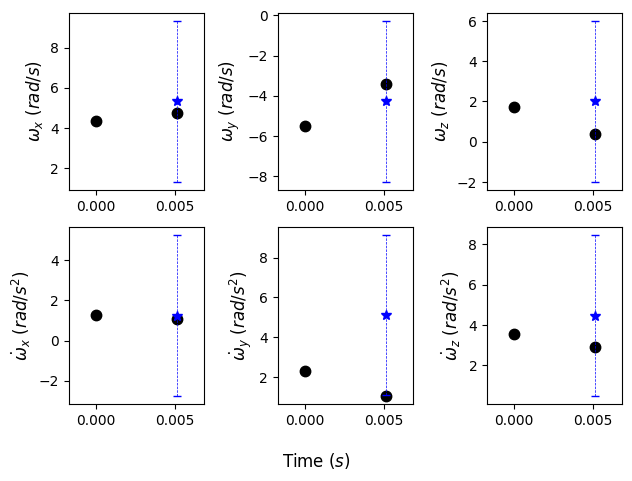

Current Batch Train Loss: -16.394275665283203

Current Batch Train Loss: -16.376949310302734

Current Batch Train Loss: -16.39590835571289

Current Batch Train Loss: -16.37046241760254

Current Batch Train Loss: -16.384014129638672

Epoch: 42, Batch Testing Loss: -16.377241134643555, Batch Testing Average RMSE: 25.743785858154297 w/ Standard Deviation: 18.577695846557617
Batch Testing Average NLL: 3.4276065826416016 w/ Standard Deviation: 3.4524481296539307

Average Absolute Prediction Error (AAE) of Plotted Sample: 36.60900115966797


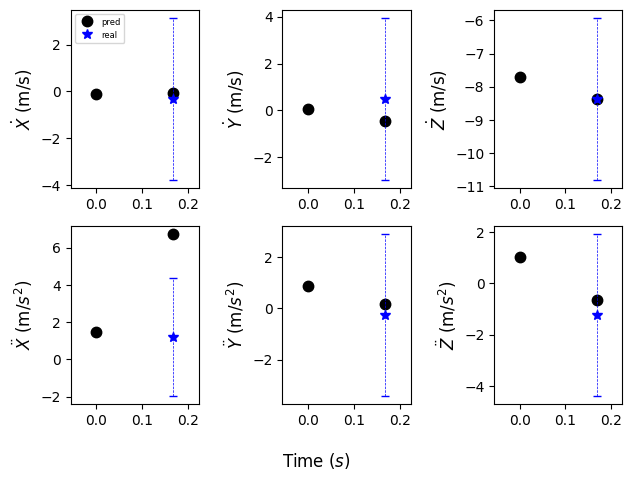

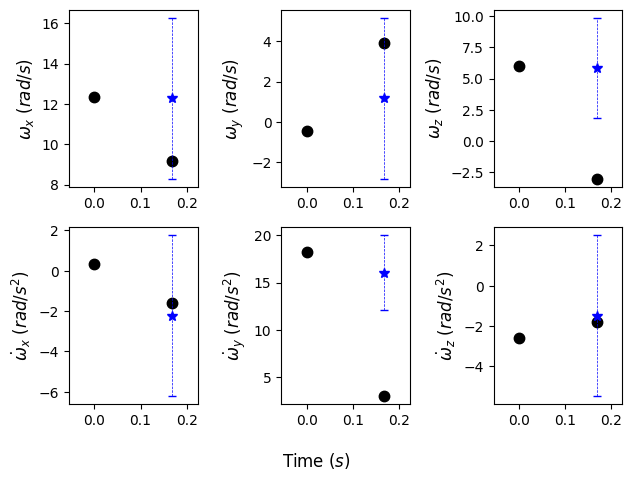

Current Batch Train Loss: -16.38714027404785

Current Batch Train Loss: -16.409025192260742

Current Batch Train Loss: -16.39145851135254

Current Batch Train Loss: -16.37803077697754

Current Batch Train Loss: -16.394683837890625

Epoch: 43, Batch Testing Loss: -16.388547897338867, Batch Testing Average RMSE: 25.26862144470215 w/ Standard Deviation: 18.02947235107422
Batch Testing Average NLL: 3.334991693496704 w/ Standard Deviation: 3.257206678390503

Average Absolute Prediction Error (AAE) of Plotted Sample: 23.697132110595703


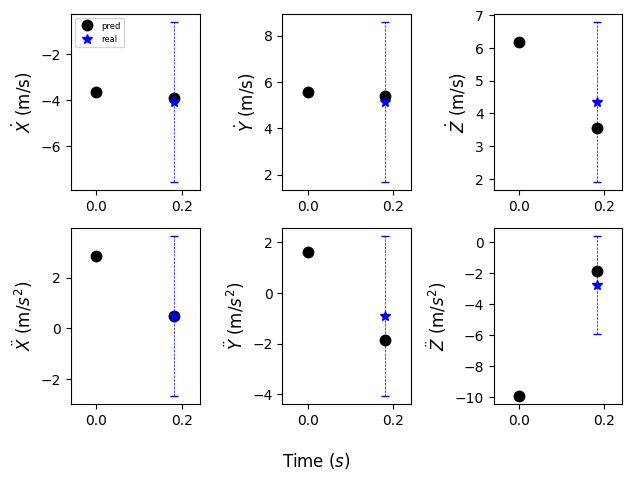

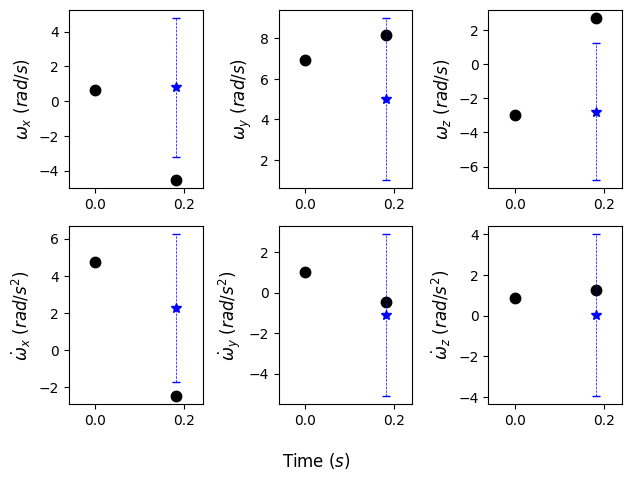

Current Batch Train Loss: -16.398704528808594

Current Batch Train Loss: -16.37639045715332

Current Batch Train Loss: -16.402355194091797

Current Batch Train Loss: -16.385644912719727

Current Batch Train Loss: -16.375877380371094

Epoch: 44, Batch Testing Loss: -16.370637893676758, Batch Testing Average RMSE: 26.119281768798828 w/ Standard Deviation: 18.585660934448242
Batch Testing Average NLL: 3.4671108722686768 w/ Standard Deviation: 4.21116304397583

Average Absolute Prediction Error (AAE) of Plotted Sample: 20.994564056396484


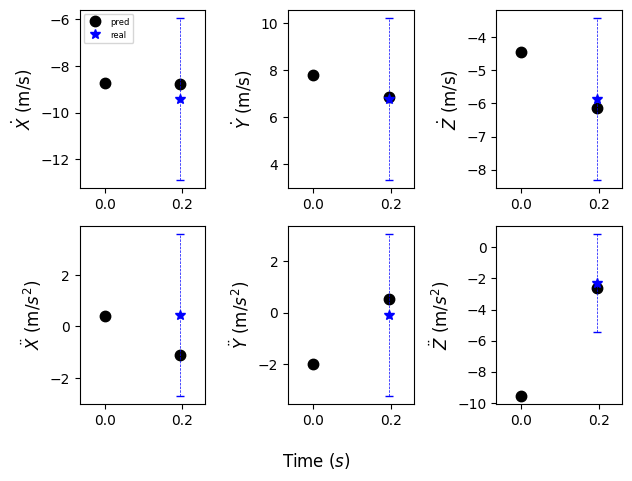

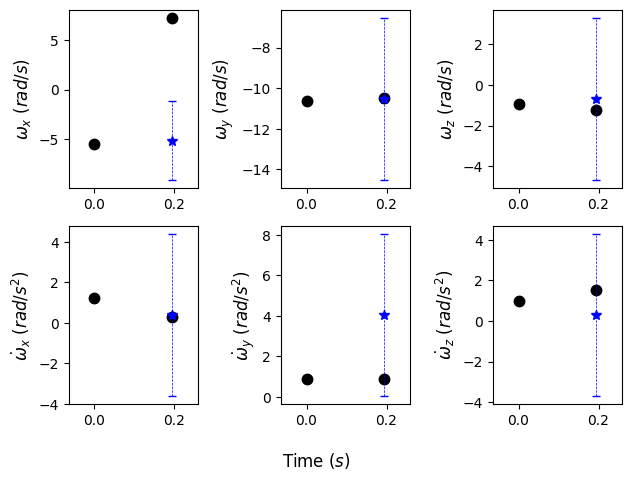

Current Batch Train Loss: -16.402250289916992

Current Batch Train Loss: -16.348997116088867

Current Batch Train Loss: -16.40509796142578

Current Batch Train Loss: -16.368824005126953

Current Batch Train Loss: -16.389183044433594

Epoch: 45, Batch Testing Loss: -16.37508773803711, Batch Testing Average RMSE: 26.396167755126953 w/ Standard Deviation: 17.458833694458008
Batch Testing Average NLL: 3.4355266094207764 w/ Standard Deviation: 3.192129611968994

Average Absolute Prediction Error (AAE) of Plotted Sample: 14.84567642211914


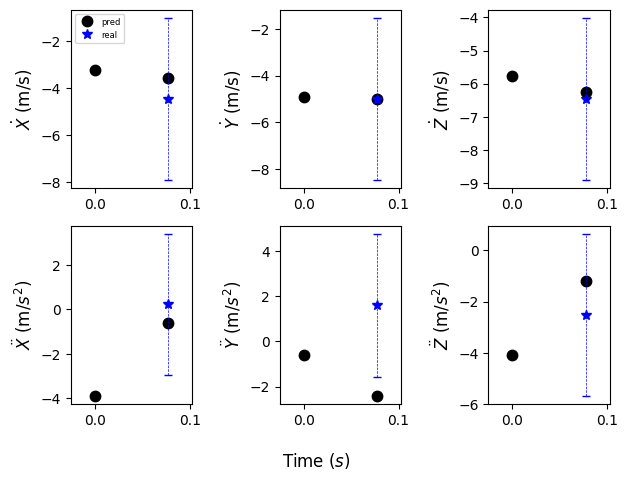

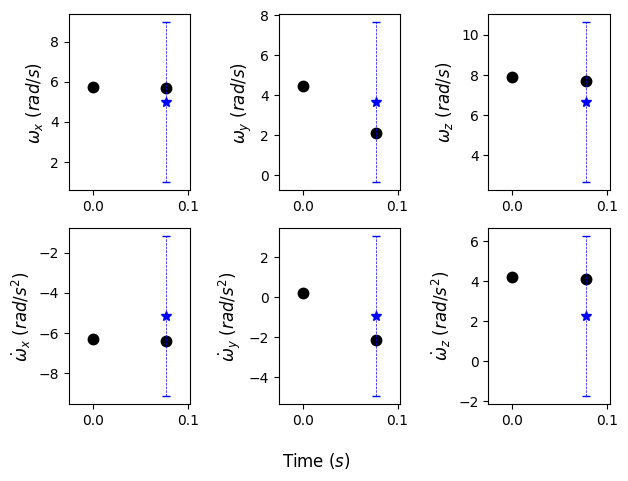

Current Batch Train Loss: -16.39386749267578

Current Batch Train Loss: -16.39592170715332

Current Batch Train Loss: -16.403902053833008

Current Batch Train Loss: -16.374330520629883

Current Batch Train Loss: -16.402162551879883

Epoch: 46, Batch Testing Loss: -16.39984893798828, Batch Testing Average RMSE: 24.568655014038086 w/ Standard Deviation: 16.83517074584961
Batch Testing Average NLL: 3.2292842864990234 w/ Standard Deviation: 3.1506295204162598

Average Absolute Prediction Error (AAE) of Plotted Sample: 50.78615188598633


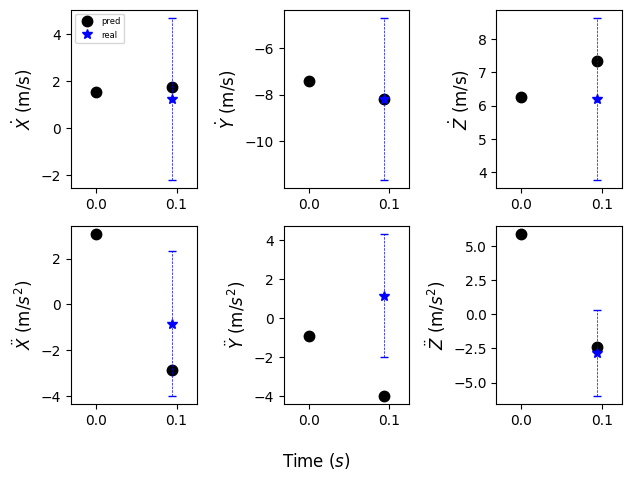

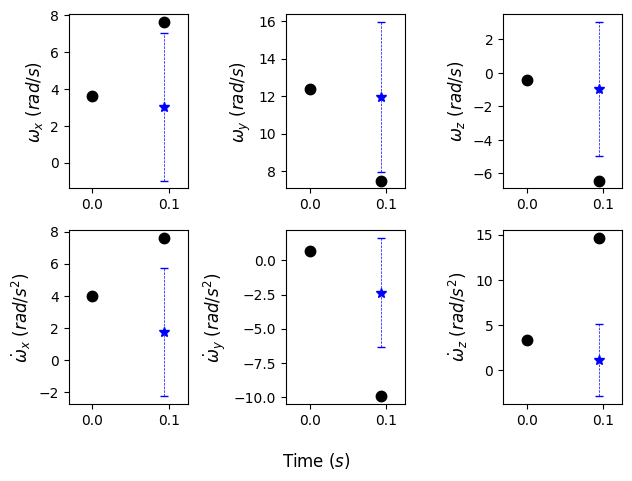

Current Batch Train Loss: -16.375686645507812

Current Batch Train Loss: -16.39912223815918

Current Batch Train Loss: -16.384567260742188

Current Batch Train Loss: -16.401851654052734

Current Batch Train Loss: -16.39423370361328

Epoch: 47, Batch Testing Loss: -16.402320861816406, Batch Testing Average RMSE: 24.645002365112305 w/ Standard Deviation: 16.662479400634766
Batch Testing Average NLL: 3.208665370941162 w/ Standard Deviation: 3.145988941192627

Average Absolute Prediction Error (AAE) of Plotted Sample: 34.254150390625


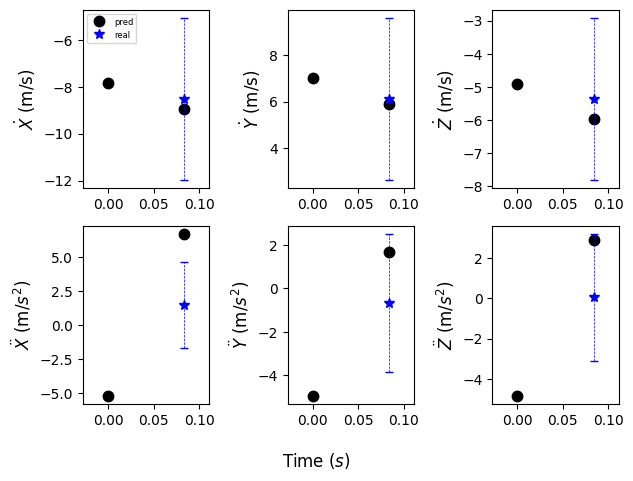

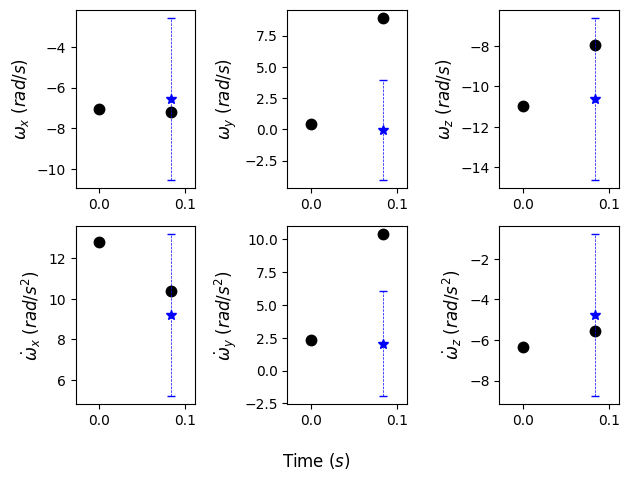

Current Batch Train Loss: -16.403217315673828

Current Batch Train Loss: -16.386751174926758

Current Batch Train Loss: -16.378082275390625

Current Batch Train Loss: -16.3648738861084

Current Batch Train Loss: -16.401639938354492

Epoch: 48, Batch Testing Loss: -16.40275001525879, Batch Testing Average RMSE: 24.92833137512207 w/ Standard Deviation: 16.161907196044922
Batch Testing Average NLL: 3.1678521633148193 w/ Standard Deviation: 2.7210607528686523

Average Absolute Prediction Error (AAE) of Plotted Sample: 7.50286865234375


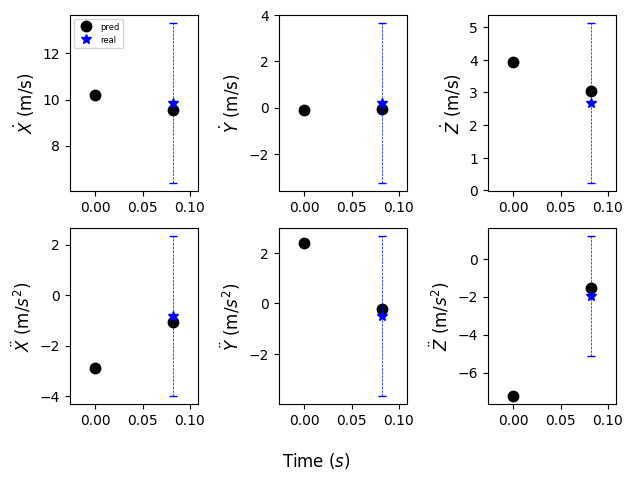

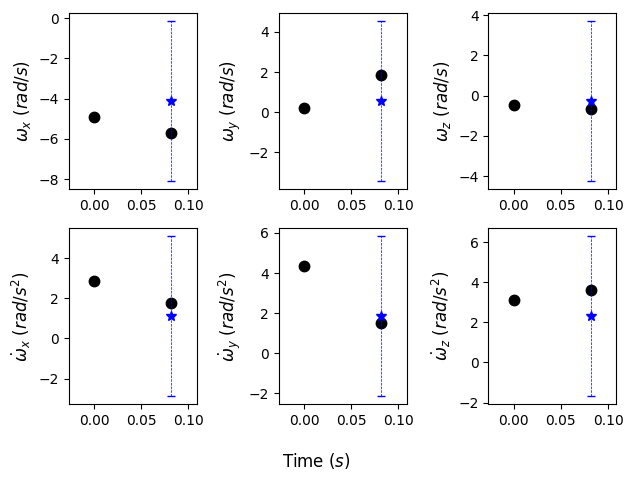

Current Batch Train Loss: -16.415788650512695

Current Batch Train Loss: -16.395503997802734

Current Batch Train Loss: -16.41217041015625

Current Batch Train Loss: -16.39144515991211

Current Batch Train Loss: -16.40029525756836

Epoch: 49, Batch Testing Loss: -16.41314125061035, Batch Testing Average RMSE: 24.530517578125 w/ Standard Deviation: 15.115867614746094
Batch Testing Average NLL: 3.1047346591949463 w/ Standard Deviation: 2.374819278717041

Average Absolute Prediction Error (AAE) of Plotted Sample: 22.83153533935547


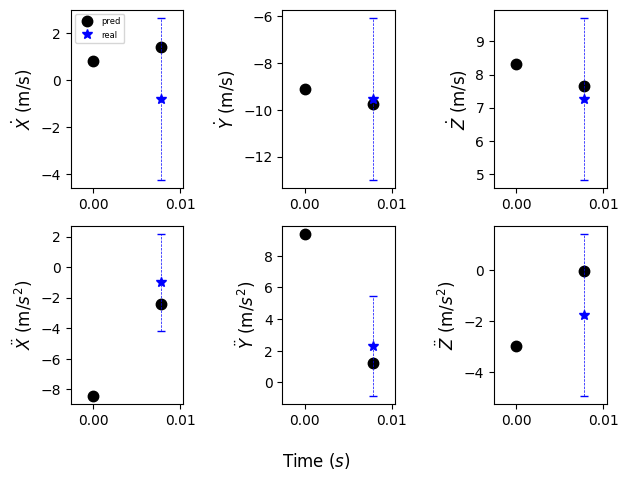

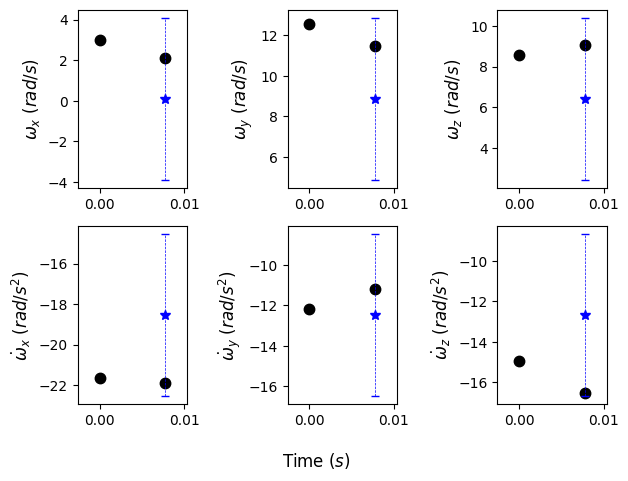

Current Batch Train Loss: -16.398895263671875

Current Batch Train Loss: -16.397167205810547

Current Batch Train Loss: -16.401508331298828

Current Batch Train Loss: -16.403451919555664

Current Batch Train Loss: -16.39464569091797

Epoch: 50, Batch Testing Loss: -16.407995223999023, Batch Testing Average RMSE: 24.0296688079834 w/ Standard Deviation: 16.809871673583984
Batch Testing Average NLL: 3.163722276687622 w/ Standard Deviation: 3.5314793586730957

Average Absolute Prediction Error (AAE) of Plotted Sample: 13.126214981079102


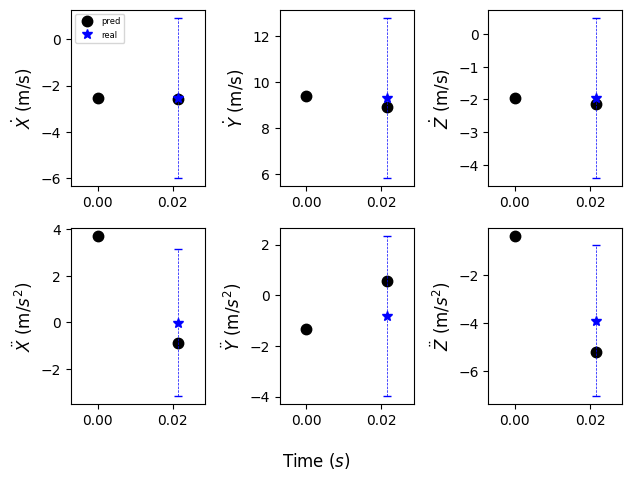

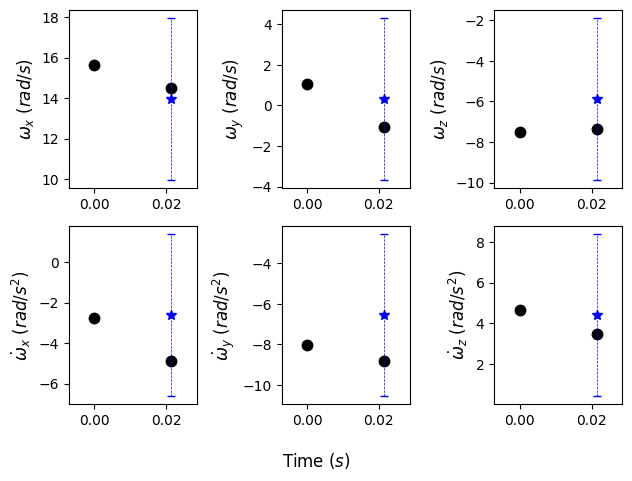

Current Batch Train Loss: -16.402828216552734

Current Batch Train Loss: -16.385122299194336

Current Batch Train Loss: -16.397253036499023

Current Batch Train Loss: -16.384075164794922

Current Batch Train Loss: -16.380712509155273

Epoch: 51, Batch Testing Loss: -16.404815673828125, Batch Testing Average RMSE: 24.234132766723633 w/ Standard Deviation: 16.834558486938477
Batch Testing Average NLL: 3.1993954181671143 w/ Standard Deviation: 3.4600539207458496

Average Absolute Prediction Error (AAE) of Plotted Sample: 26.82965850830078


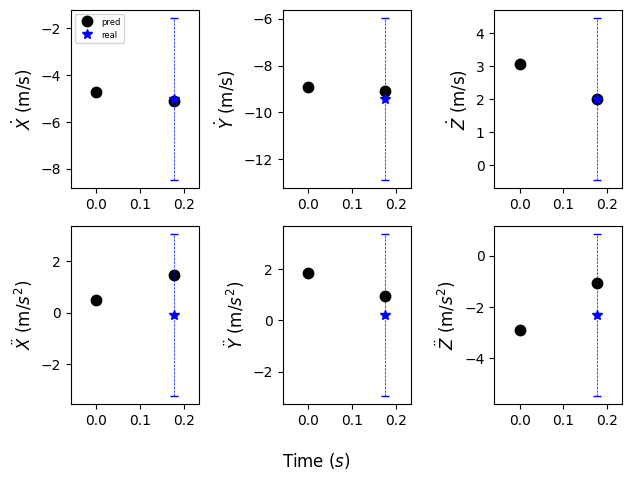

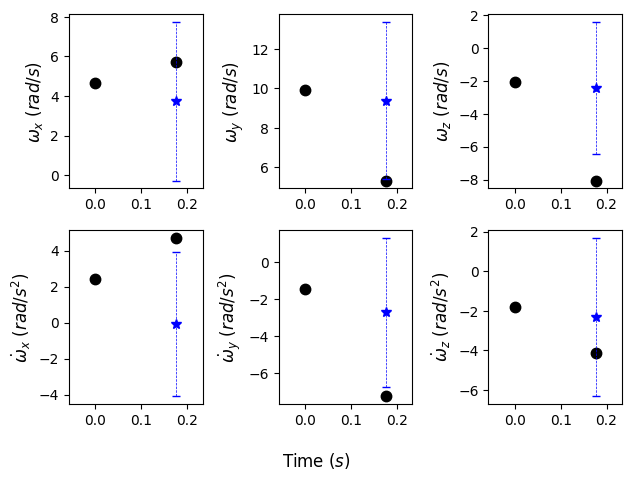

Current Batch Train Loss: -16.408092498779297

Current Batch Train Loss: -16.401201248168945

Current Batch Train Loss: -16.399385452270508

Current Batch Train Loss: -16.3747615814209

Current Batch Train Loss: -16.392658233642578

Epoch: 52, Batch Testing Loss: -16.403223037719727, Batch Testing Average RMSE: 25.04764175415039 w/ Standard Deviation: 15.642075538635254
Batch Testing Average NLL: 3.162503719329834 w/ Standard Deviation: 2.6979687213897705

Average Absolute Prediction Error (AAE) of Plotted Sample: 66.21721649169922


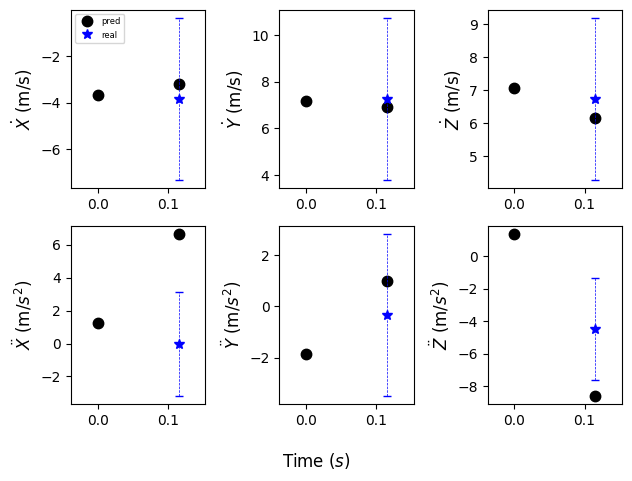

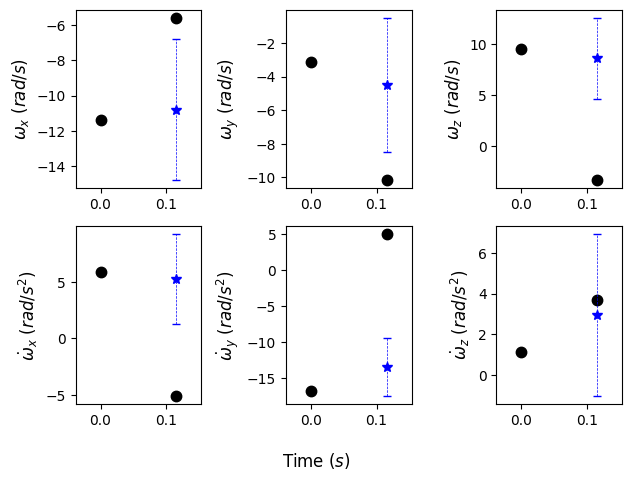

Current Batch Train Loss: -16.398725509643555

Current Batch Train Loss: -16.385555267333984

Current Batch Train Loss: -16.397241592407227

Current Batch Train Loss: -16.375905990600586

Current Batch Train Loss: -16.398784637451172

Epoch: 53, Batch Testing Loss: -16.399450302124023, Batch Testing Average RMSE: 24.556324005126953 w/ Standard Deviation: 16.976716995239258
Batch Testing Average NLL: 3.2763051986694336 w/ Standard Deviation: 3.4615468978881836

Average Absolute Prediction Error (AAE) of Plotted Sample: 21.40903663635254


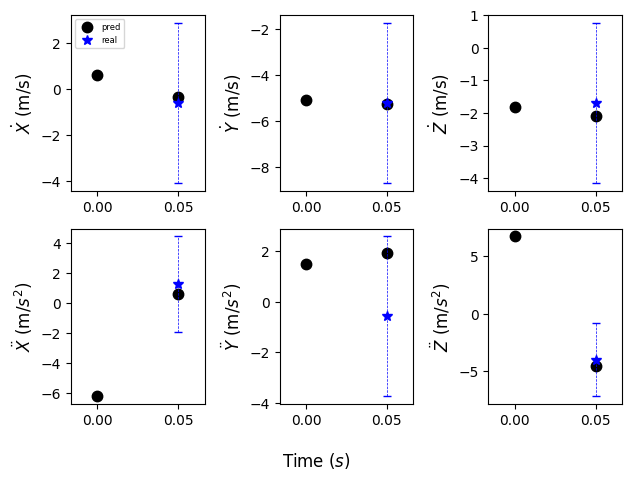

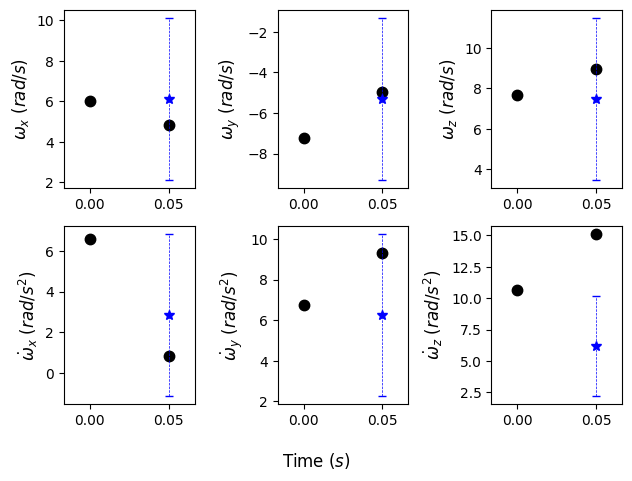

Current Batch Train Loss: -16.38579559326172

Current Batch Train Loss: -16.399477005004883

Current Batch Train Loss: -16.40422821044922

Current Batch Train Loss: -16.390846252441406

Current Batch Train Loss: -16.397354125976562

Epoch: 54, Batch Testing Loss: -16.405378341674805, Batch Testing Average RMSE: 24.82020378112793 w/ Standard Deviation: 16.216886520385742
Batch Testing Average NLL: 3.1957361698150635 w/ Standard Deviation: 2.754856824874878

Average Absolute Prediction Error (AAE) of Plotted Sample: 15.785120010375977


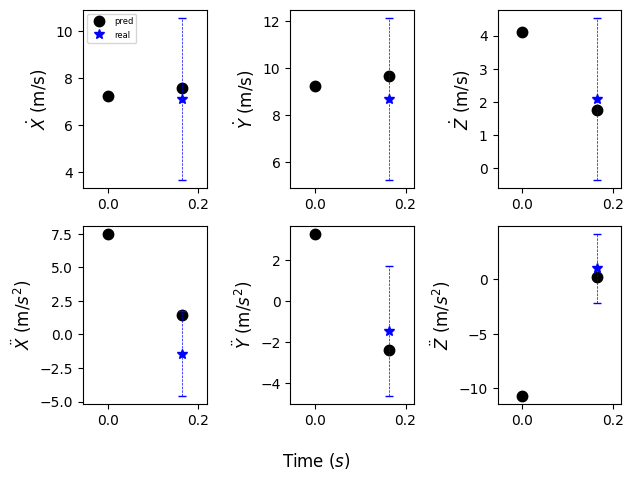

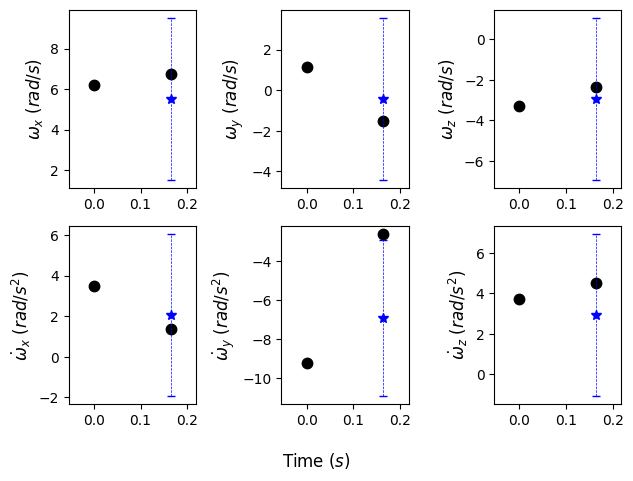

Current Batch Train Loss: -16.402936935424805

Current Batch Train Loss: -16.398086547851562

Current Batch Train Loss: -16.401010513305664

Current Batch Train Loss: -16.415842056274414

Current Batch Train Loss: -16.39047622680664

Epoch: 55, Batch Testing Loss: -16.416860580444336, Batch Testing Average RMSE: 24.25989532470703 w/ Standard Deviation: 15.414562225341797
Batch Testing Average NLL: 3.0706567764282227 w/ Standard Deviation: 2.7065789699554443

Average Absolute Prediction Error (AAE) of Plotted Sample: 17.212244033813477


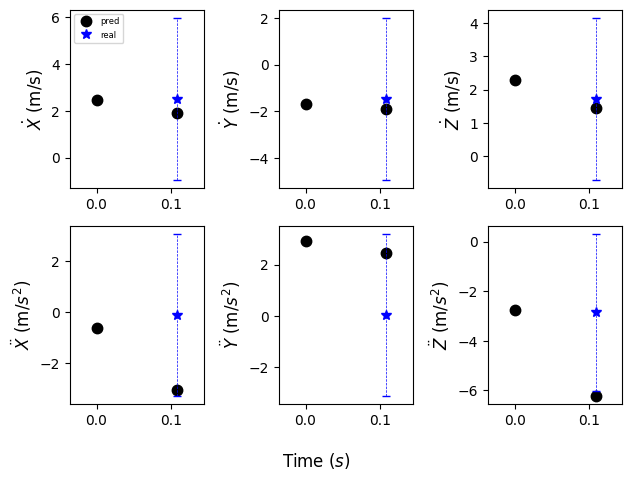

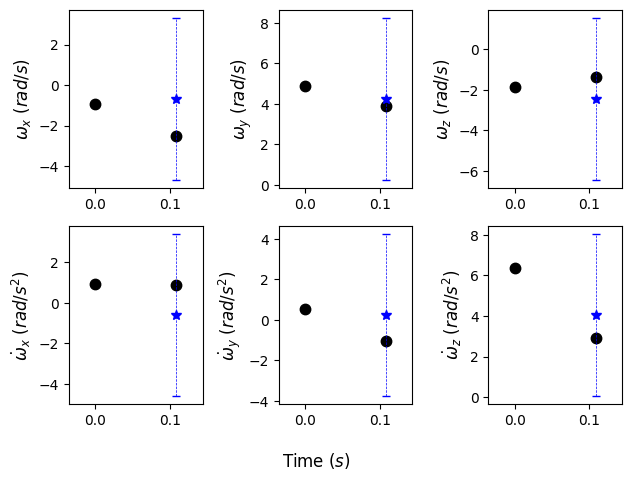

Current Batch Train Loss: -16.400625228881836

Current Batch Train Loss: -16.398550033569336

Current Batch Train Loss: -16.404678344726562

Current Batch Train Loss: -16.406452178955078

Current Batch Train Loss: -16.392562866210938

Epoch: 56, Batch Testing Loss: -16.402507781982422, Batch Testing Average RMSE: 25.0285587310791 w/ Standard Deviation: 16.42627716064453
Batch Testing Average NLL: 3.202322006225586 w/ Standard Deviation: 3.0451550483703613

Average Absolute Prediction Error (AAE) of Plotted Sample: 11.028877258300781


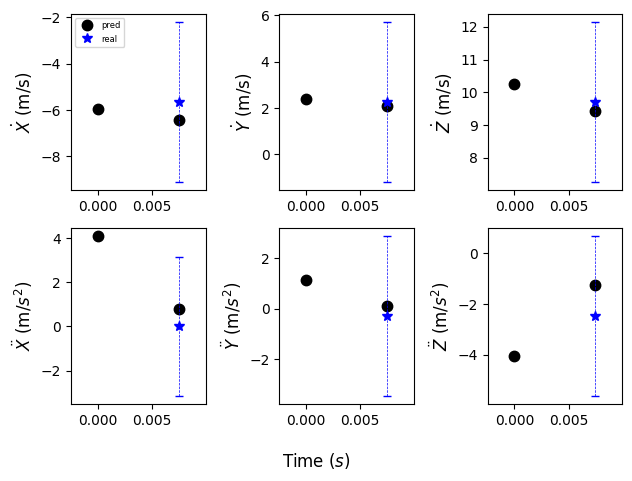

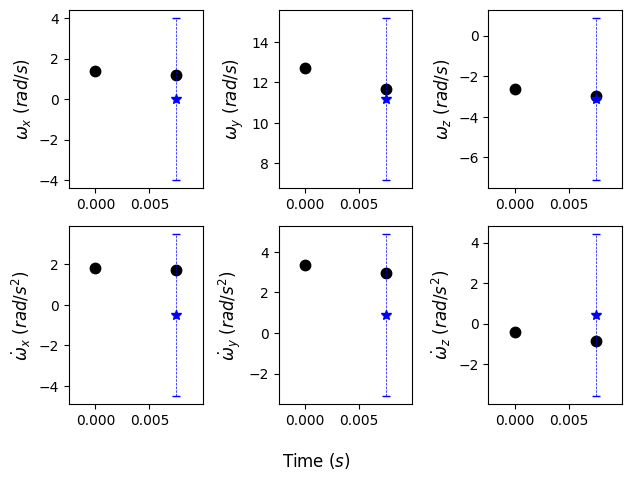

Current Batch Train Loss: -16.408924102783203

Current Batch Train Loss: -16.406841278076172

Current Batch Train Loss: -16.379518508911133

Current Batch Train Loss: -16.403457641601562

Current Batch Train Loss: -16.414018630981445

Epoch: 57, Batch Testing Loss: -16.393125534057617, Batch Testing Average RMSE: 26.134973526000977 w/ Standard Deviation: 16.345428466796875
Batch Testing Average NLL: 3.251946210861206 w/ Standard Deviation: 2.680067777633667

Average Absolute Prediction Error (AAE) of Plotted Sample: 34.54374694824219


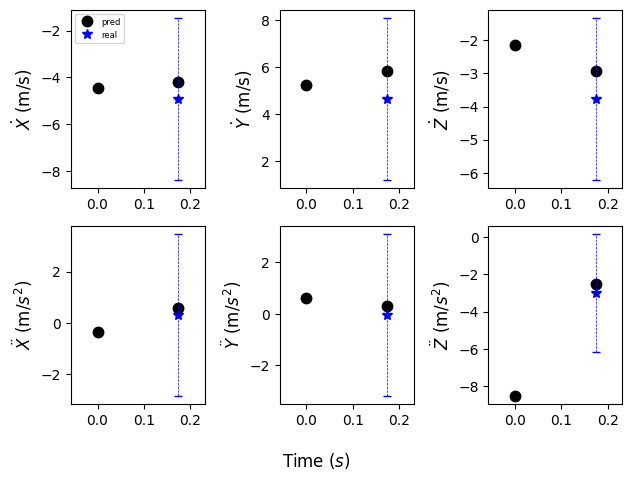

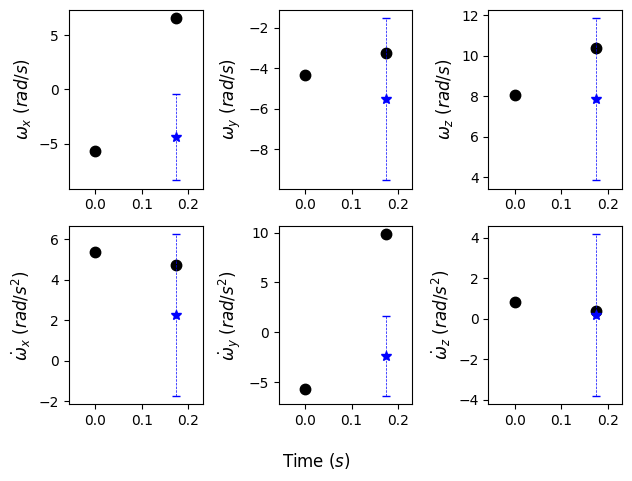

Current Batch Train Loss: -16.38739585876465

Current Batch Train Loss: -16.40011215209961

Current Batch Train Loss: -16.40019416809082

Current Batch Train Loss: -16.417404174804688

Current Batch Train Loss: -16.388500213623047

Epoch: 58, Batch Testing Loss: -16.402019500732422, Batch Testing Average RMSE: 24.780292510986328 w/ Standard Deviation: 16.77267074584961
Batch Testing Average NLL: 3.258331775665283 w/ Standard Deviation: 3.4639506340026855

Average Absolute Prediction Error (AAE) of Plotted Sample: 13.417144775390625


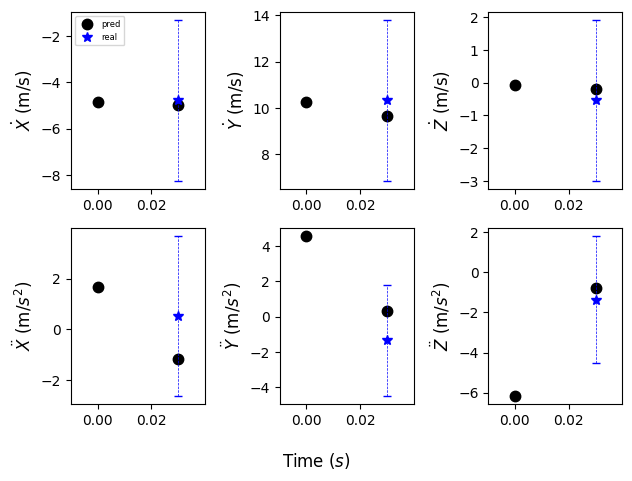

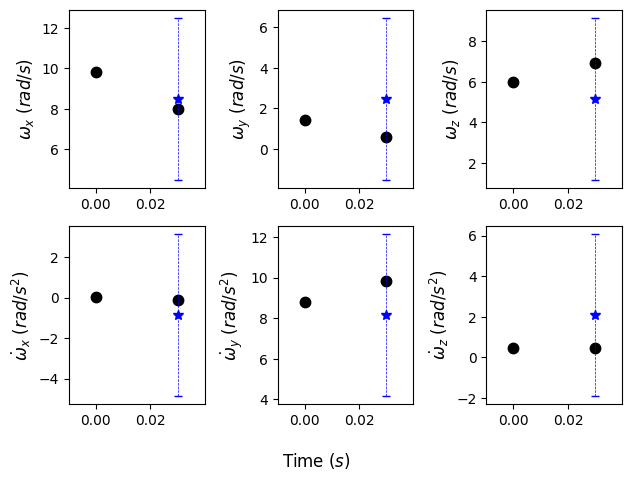

Current Batch Train Loss: -16.397199630737305

Current Batch Train Loss: -16.41449737548828

Current Batch Train Loss: -16.399240493774414

Current Batch Train Loss: -16.396896362304688

Current Batch Train Loss: -16.397632598876953

Epoch: 59, Batch Testing Loss: -16.387508392333984, Batch Testing Average RMSE: 25.726058959960938 w/ Standard Deviation: 17.29643440246582
Batch Testing Average NLL: 3.3713579177856445 w/ Standard Deviation: 3.4073522090911865

Average Absolute Prediction Error (AAE) of Plotted Sample: 54.647491455078125


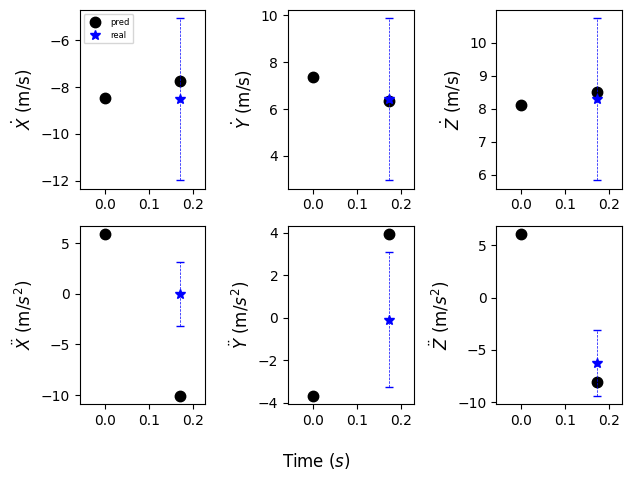

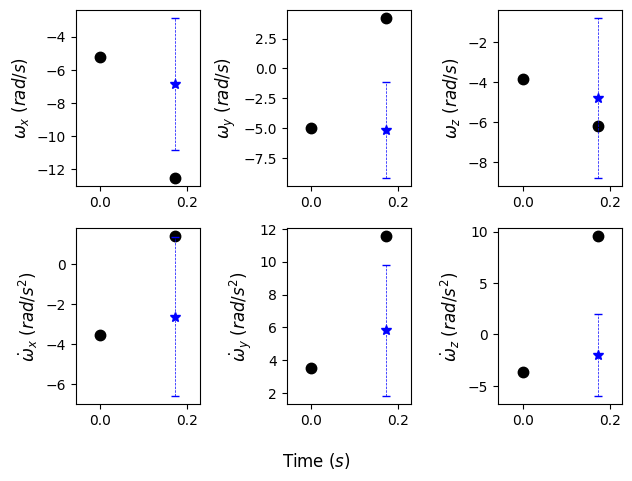

Current Batch Train Loss: -16.4025936126709

Current Batch Train Loss: -16.41360092163086

Current Batch Train Loss: -16.40787696838379

Current Batch Train Loss: -16.394807815551758

Current Batch Train Loss: -16.414793014526367

Epoch: 60, Batch Testing Loss: -16.414003372192383, Batch Testing Average RMSE: 24.712051391601562 w/ Standard Deviation: 15.045924186706543
Batch Testing Average NLL: 3.127126455307007 w/ Standard Deviation: 2.3430089950561523

Average Absolute Prediction Error (AAE) of Plotted Sample: 21.279857635498047


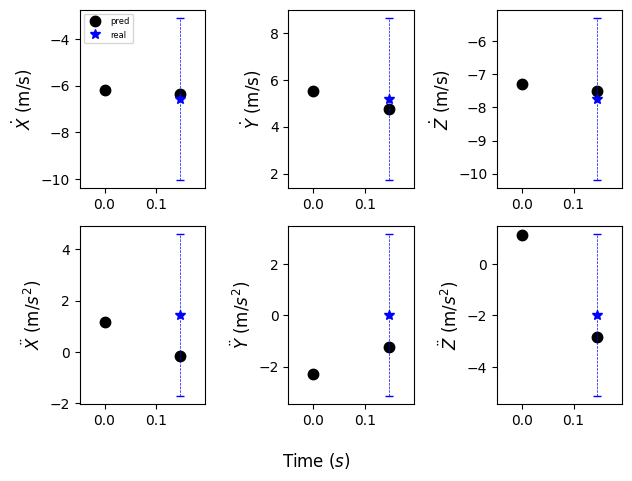

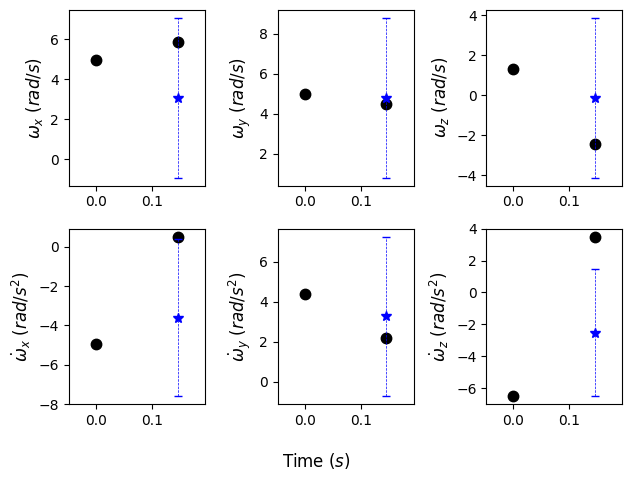

Current Batch Train Loss: -16.4148006439209

Current Batch Train Loss: -16.403623580932617

Current Batch Train Loss: -16.409500122070312

Current Batch Train Loss: -16.399093627929688

Current Batch Train Loss: -16.421457290649414

Epoch: 61, Batch Testing Loss: -16.390369415283203, Batch Testing Average RMSE: 25.75870132446289 w/ Standard Deviation: 17.815067291259766
Batch Testing Average NLL: 3.3599798679351807 w/ Standard Deviation: 3.1694138050079346

Average Absolute Prediction Error (AAE) of Plotted Sample: 17.537155151367188


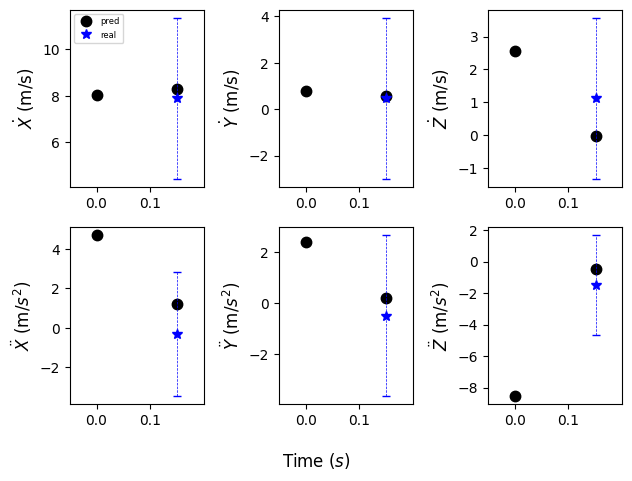

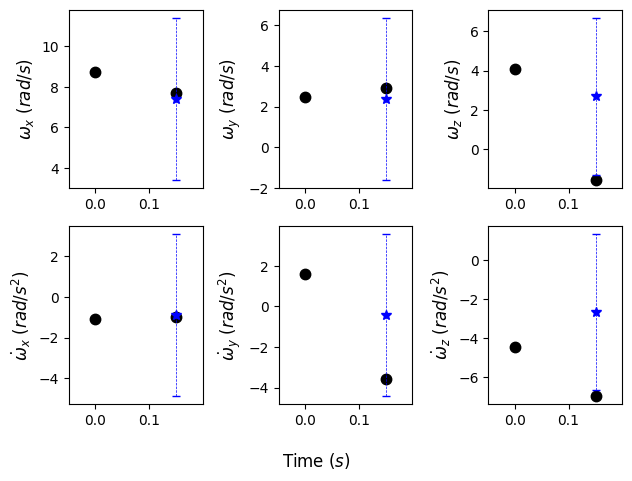

Current Batch Train Loss: -16.411327362060547

Current Batch Train Loss: -16.3997859954834

Current Batch Train Loss: -16.40383529663086

Current Batch Train Loss: -16.410837173461914

Current Batch Train Loss: -16.40707778930664

Epoch: 62, Batch Testing Loss: -16.395282745361328, Batch Testing Average RMSE: 25.302217483520508 w/ Standard Deviation: 16.855878829956055
Batch Testing Average NLL: 3.314379930496216 w/ Standard Deviation: 3.8757987022399902

Average Absolute Prediction Error (AAE) of Plotted Sample: 19.008712768554688


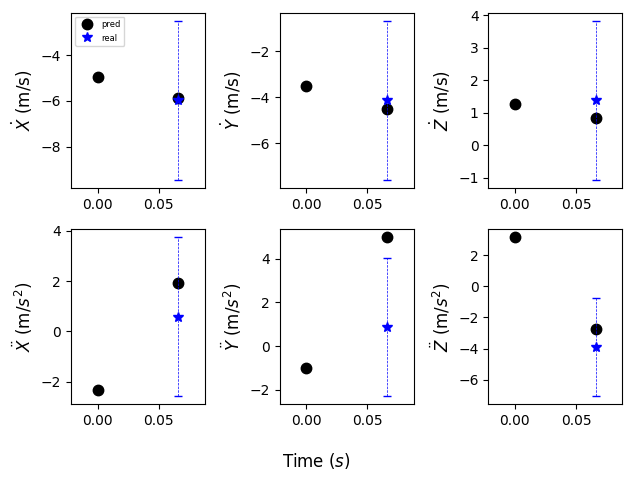

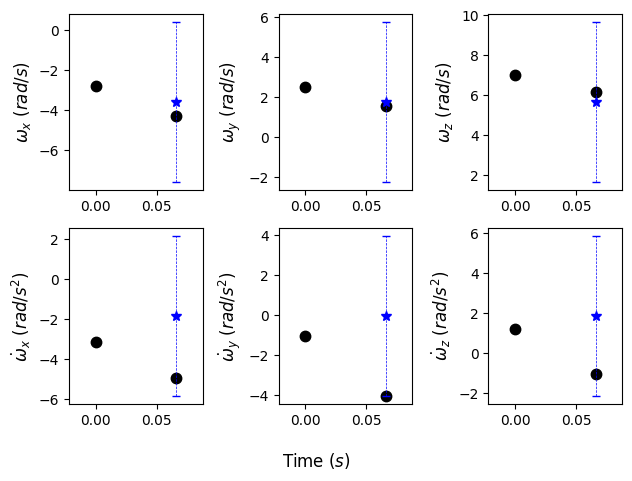

Current Batch Train Loss: -16.383333206176758

Current Batch Train Loss: -16.41507339477539

Current Batch Train Loss: -16.392295837402344

Current Batch Train Loss: -16.405014038085938

Current Batch Train Loss: -16.415599822998047

Epoch: 63, Batch Testing Loss: -16.4033260345459, Batch Testing Average RMSE: 25.36479377746582 w/ Standard Deviation: 16.6002140045166
Batch Testing Average NLL: 3.2483060359954834 w/ Standard Deviation: 2.745100975036621

Average Absolute Prediction Error (AAE) of Plotted Sample: 19.720687866210938


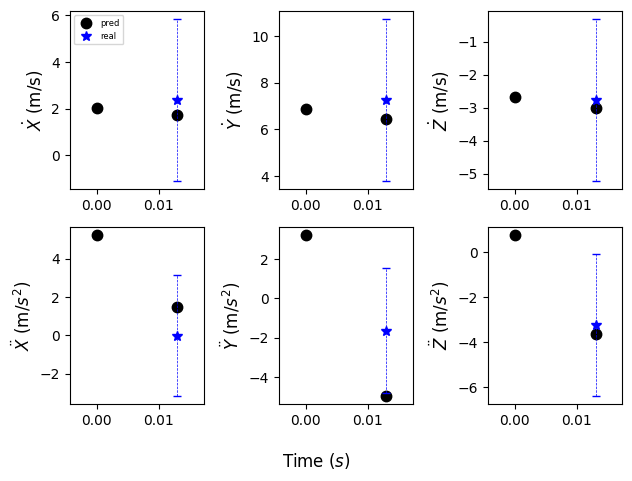

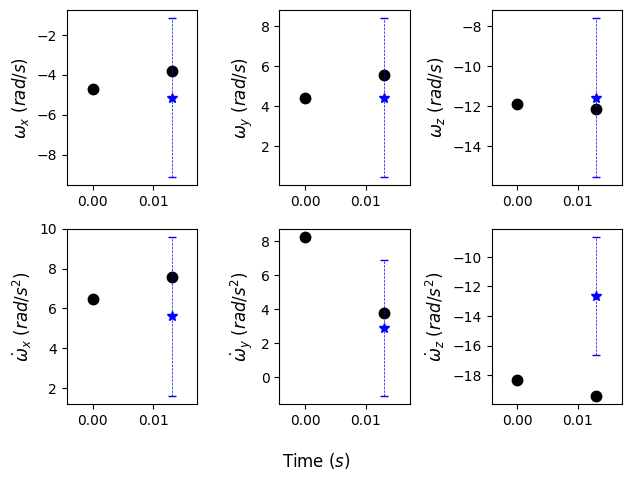

Current Batch Train Loss: -16.394392013549805

Current Batch Train Loss: -16.379762649536133

Current Batch Train Loss: -16.418781280517578

Current Batch Train Loss: -16.40701675415039

Current Batch Train Loss: -16.40530776977539

Epoch: 64, Batch Testing Loss: -16.379436492919922, Batch Testing Average RMSE: 25.981748580932617 w/ Standard Deviation: 18.21429443359375
Batch Testing Average NLL: 3.508394956588745 w/ Standard Deviation: 4.746376037597656

Average Absolute Prediction Error (AAE) of Plotted Sample: 16.552995681762695


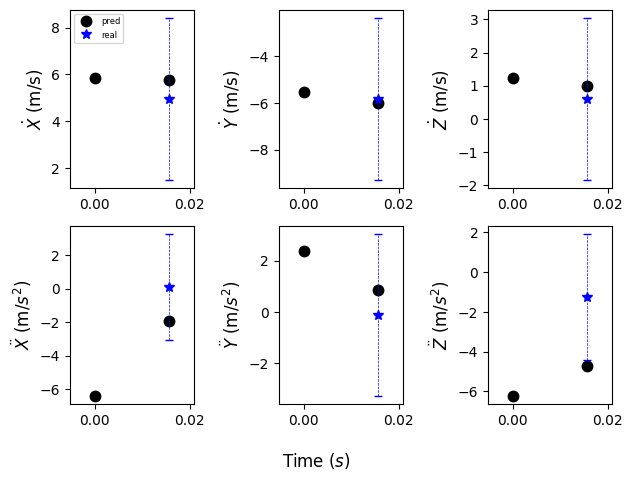

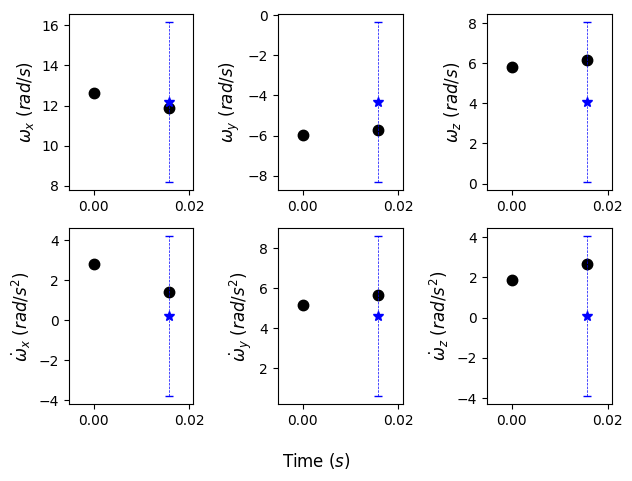

Current Batch Train Loss: -16.39794158935547

Current Batch Train Loss: -16.406335830688477

Current Batch Train Loss: -16.407238006591797

Current Batch Train Loss: -16.4263973236084

Current Batch Train Loss: -16.416358947753906

Epoch: 65, Batch Testing Loss: -16.401193618774414, Batch Testing Average RMSE: 25.275054931640625 w/ Standard Deviation: 16.518661499023438
Batch Testing Average NLL: 3.278252124786377 w/ Standard Deviation: 2.9310030937194824

Average Absolute Prediction Error (AAE) of Plotted Sample: 23.36615753173828


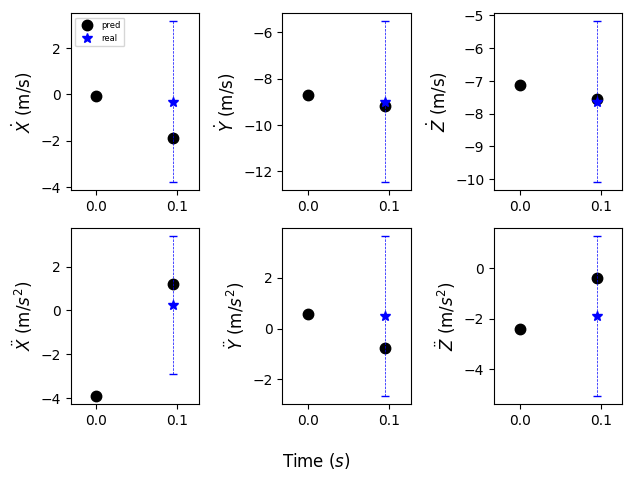

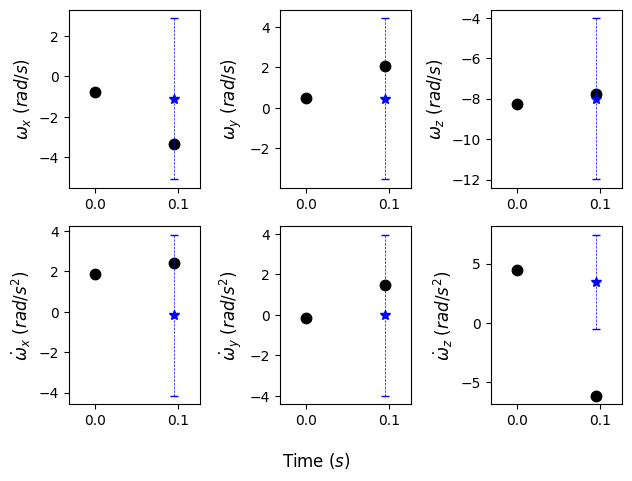

Current Batch Train Loss: -16.395437240600586

Current Batch Train Loss: -16.359636306762695

Current Batch Train Loss: -16.409032821655273

Current Batch Train Loss: -16.39116859436035

Current Batch Train Loss: -16.391971588134766

Epoch: 66, Batch Testing Loss: -16.42665672302246, Batch Testing Average RMSE: 23.944477081298828 w/ Standard Deviation: 14.606182098388672
Batch Testing Average NLL: 2.9916157722473145 w/ Standard Deviation: 2.067911148071289

Average Absolute Prediction Error (AAE) of Plotted Sample: 24.218338012695312


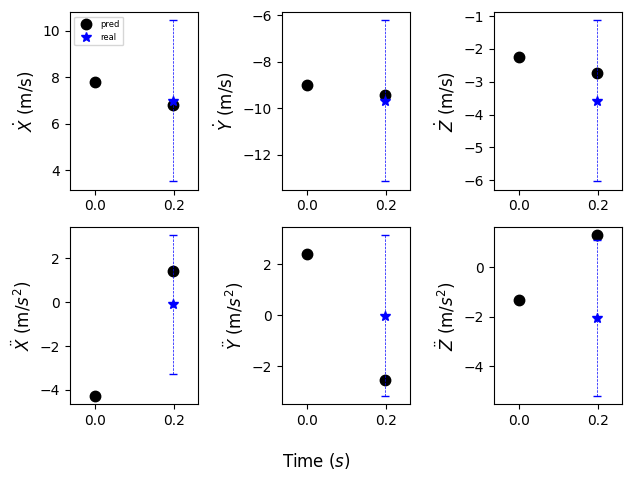

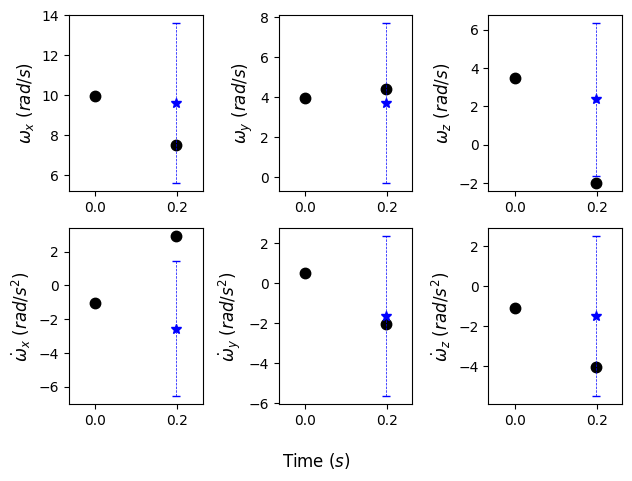

Current Batch Train Loss: -16.381366729736328

Current Batch Train Loss: -16.419185638427734

Current Batch Train Loss: -16.39724349975586

Current Batch Train Loss: -16.409957885742188

Current Batch Train Loss: -16.387434005737305

Epoch: 67, Batch Testing Loss: -16.404340744018555, Batch Testing Average RMSE: 25.099821090698242 w/ Standard Deviation: 16.301494598388672
Batch Testing Average NLL: 3.268043041229248 w/ Standard Deviation: 3.1735336780548096

Average Absolute Prediction Error (AAE) of Plotted Sample: 14.49100112915039


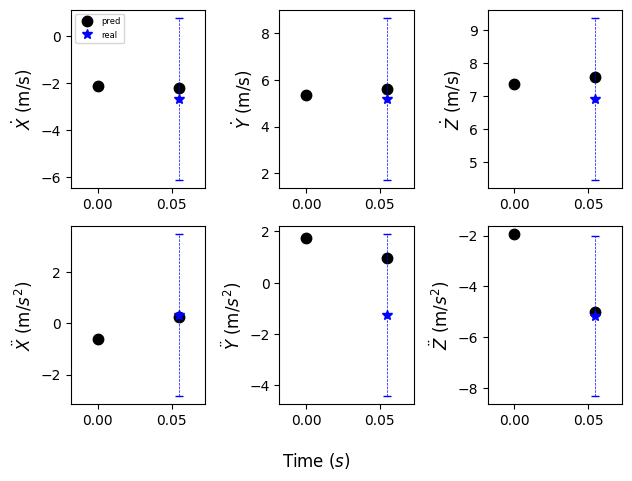

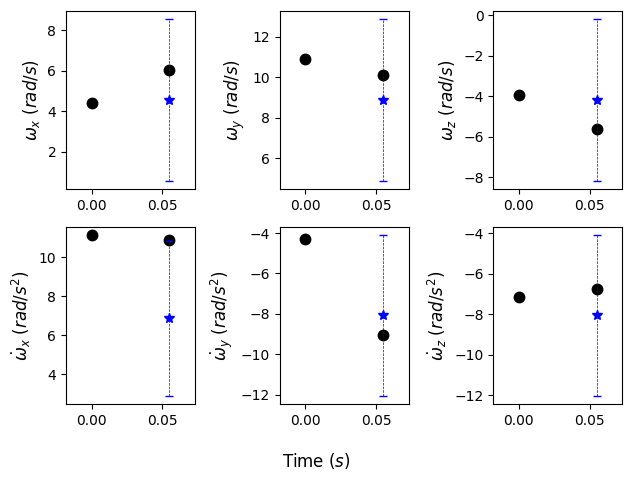

Current Batch Train Loss: -16.417062759399414

Current Batch Train Loss: -16.410606384277344

Current Batch Train Loss: -16.417125701904297

Current Batch Train Loss: -16.40839958190918

Current Batch Train Loss: -16.415002822875977

Epoch: 68, Batch Testing Loss: -16.392841339111328, Batch Testing Average RMSE: 25.68079376220703 w/ Standard Deviation: 17.740041732788086
Batch Testing Average NLL: 3.3421096801757812 w/ Standard Deviation: 3.3116493225097656

Average Absolute Prediction Error (AAE) of Plotted Sample: 23.28334617614746


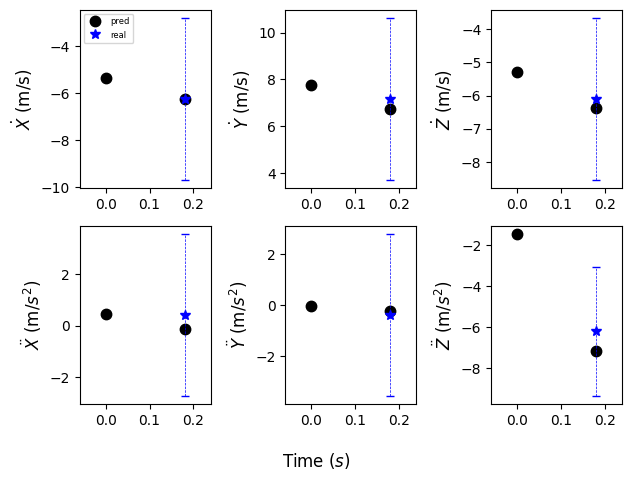

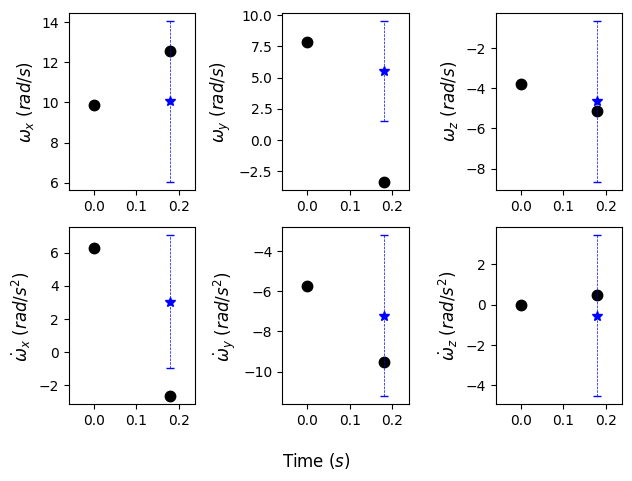

Current Batch Train Loss: -16.397741317749023

Current Batch Train Loss: -16.387434005737305

Current Batch Train Loss: -16.41208267211914

Current Batch Train Loss: -16.394699096679688

Current Batch Train Loss: -16.393024444580078

Epoch: 69, Batch Testing Loss: -16.4261531829834, Batch Testing Average RMSE: 24.126577377319336 w/ Standard Deviation: 14.922271728515625
Batch Testing Average NLL: 3.0299761295318604 w/ Standard Deviation: 2.2486050128936768

Average Absolute Prediction Error (AAE) of Plotted Sample: 10.101627349853516


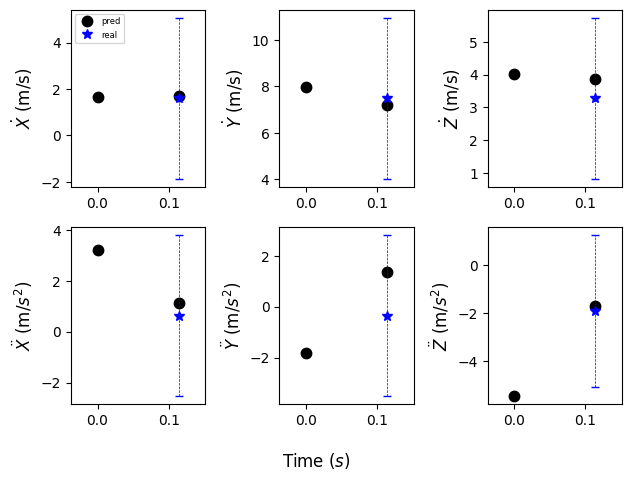

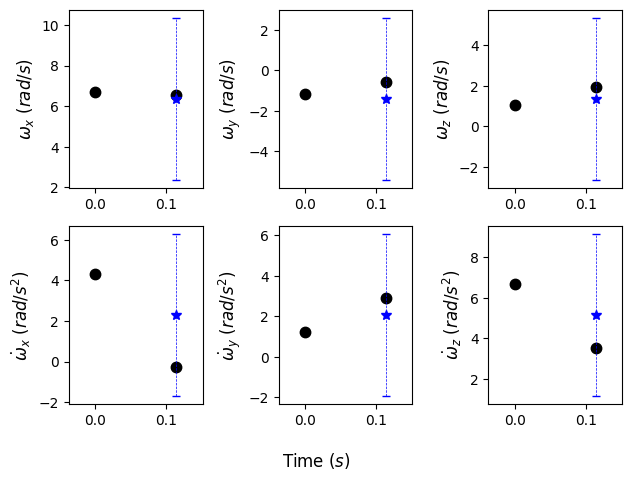

Current Batch Train Loss: -16.4071102142334

Current Batch Train Loss: -16.41128921508789

Current Batch Train Loss: -16.40106201171875

Current Batch Train Loss: -16.40953254699707

Current Batch Train Loss: -16.417694091796875

Epoch: 70, Batch Testing Loss: -16.413806915283203, Batch Testing Average RMSE: 24.749404907226562 w/ Standard Deviation: 15.77005386352539
Batch Testing Average NLL: 3.1574299335479736 w/ Standard Deviation: 2.636758804321289

Average Absolute Prediction Error (AAE) of Plotted Sample: 16.64577865600586


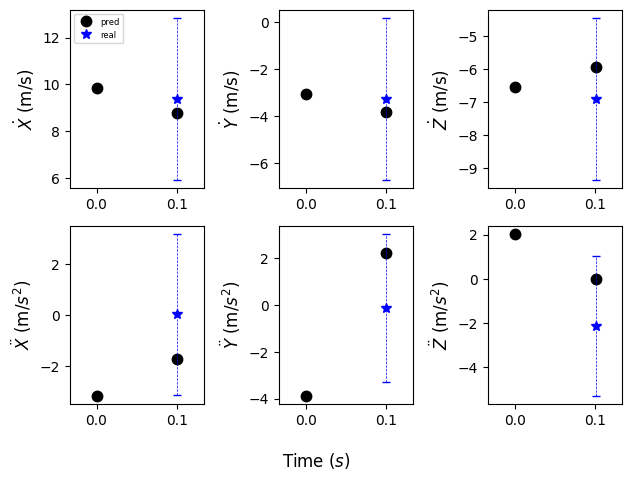

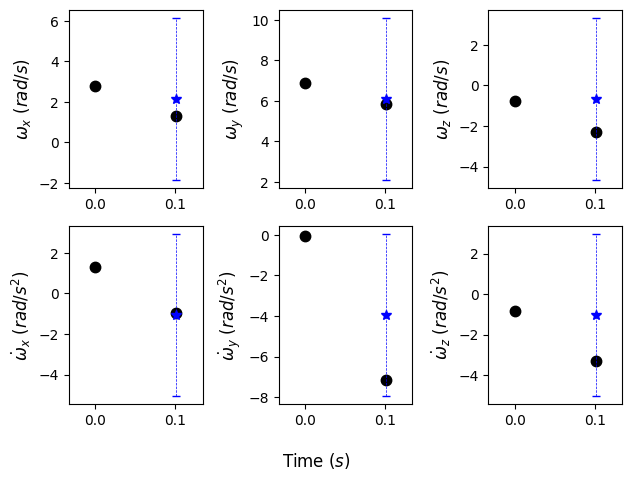

Current Batch Train Loss: -16.39898681640625

Current Batch Train Loss: -16.418066024780273

Current Batch Train Loss: -16.386064529418945

Current Batch Train Loss: -16.399065017700195

Current Batch Train Loss: -16.391834259033203

Epoch: 71, Batch Testing Loss: -16.4239444732666, Batch Testing Average RMSE: 24.254608154296875 w/ Standard Deviation: 14.358613014221191
Batch Testing Average NLL: 3.028127670288086 w/ Standard Deviation: 2.2164368629455566

Average Absolute Prediction Error (AAE) of Plotted Sample: 17.626983642578125


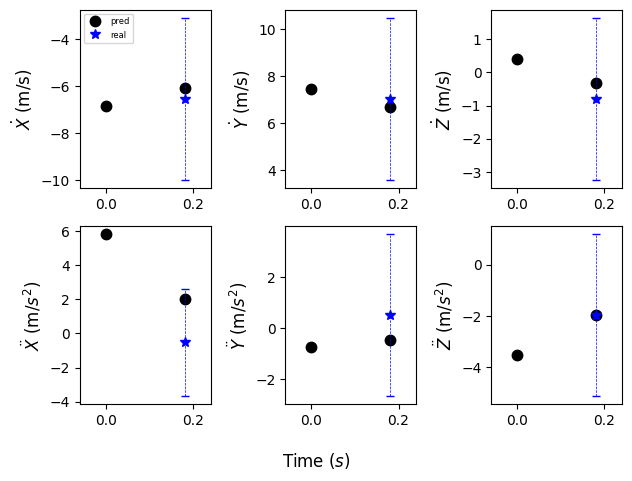

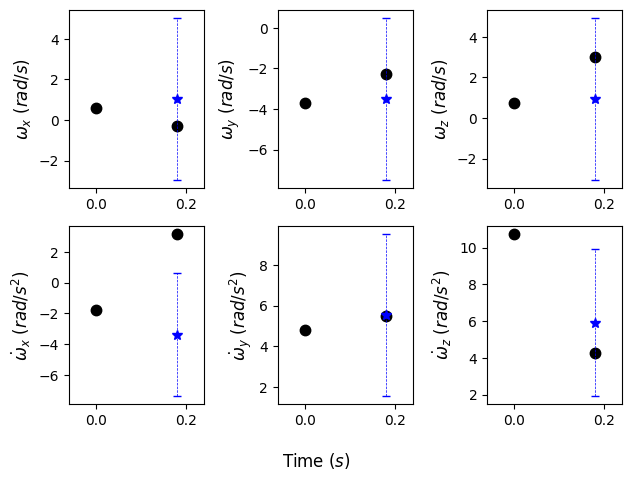

Current Batch Train Loss: -16.415220260620117

Current Batch Train Loss: -16.398225784301758

Current Batch Train Loss: -16.389925003051758

Current Batch Train Loss: -16.400604248046875

Current Batch Train Loss: -16.399784088134766

Epoch: 72, Batch Testing Loss: -16.408184051513672, Batch Testing Average RMSE: 25.0861759185791 w/ Standard Deviation: 15.74455738067627
Batch Testing Average NLL: 3.1751019954681396 w/ Standard Deviation: 3.002636432647705

Average Absolute Prediction Error (AAE) of Plotted Sample: 7.390983581542969


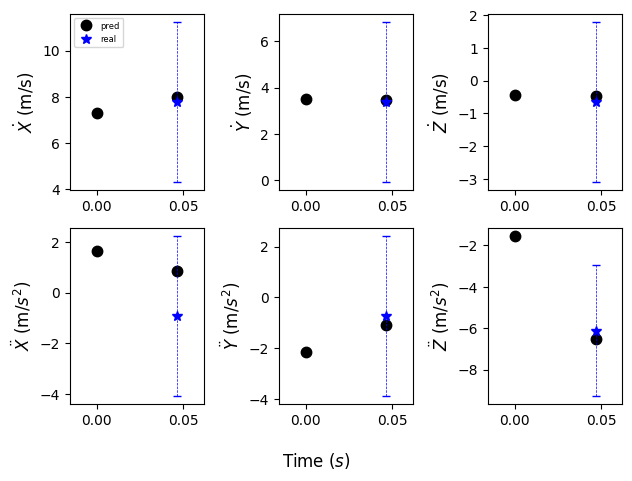

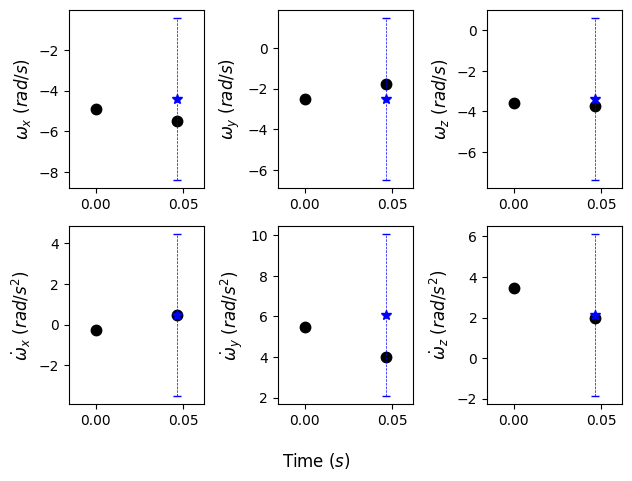

Current Batch Train Loss: -16.413179397583008

Current Batch Train Loss: -16.390541076660156

Current Batch Train Loss: -16.40428924560547

Current Batch Train Loss: -16.415454864501953

Current Batch Train Loss: -16.418231964111328

Epoch: 73, Batch Testing Loss: -16.414306640625, Batch Testing Average RMSE: 24.666370391845703 w/ Standard Deviation: 15.863832473754883
Batch Testing Average NLL: 3.1446895599365234 w/ Standard Deviation: 2.8912692070007324

Average Absolute Prediction Error (AAE) of Plotted Sample: 16.814748764038086


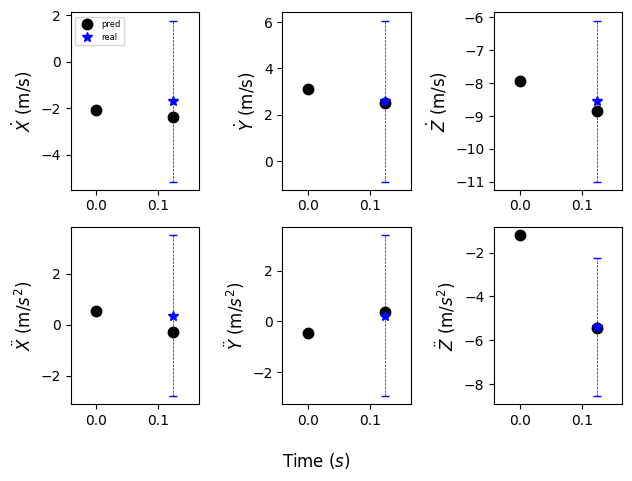

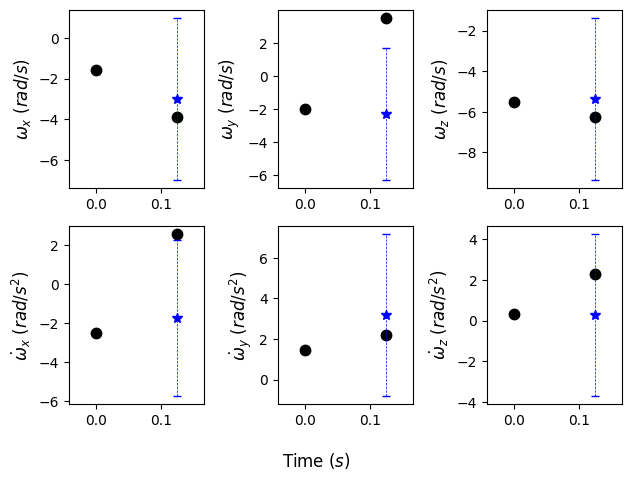

Current Batch Train Loss: -16.411123275756836

Current Batch Train Loss: -16.409175872802734

Current Batch Train Loss: -16.411584854125977

Current Batch Train Loss: -16.375383377075195

Current Batch Train Loss: -16.394546508789062

Epoch: 74, Batch Testing Loss: -16.404115676879883, Batch Testing Average RMSE: 25.152862548828125 w/ Standard Deviation: 16.694169998168945
Batch Testing Average NLL: 3.2387380599975586 w/ Standard Deviation: 3.355473041534424

Average Absolute Prediction Error (AAE) of Plotted Sample: 17.91570281982422


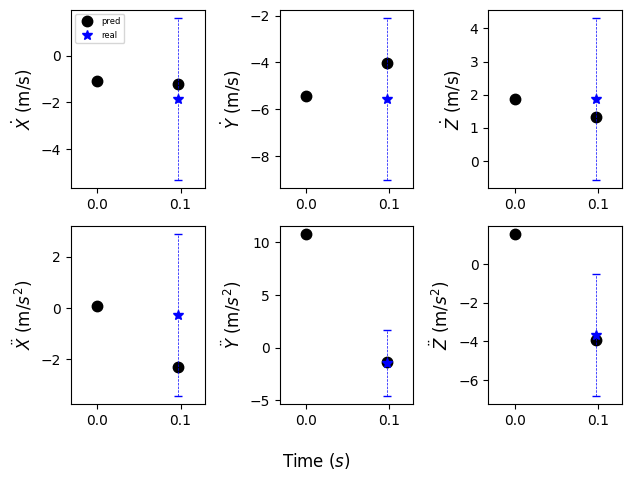

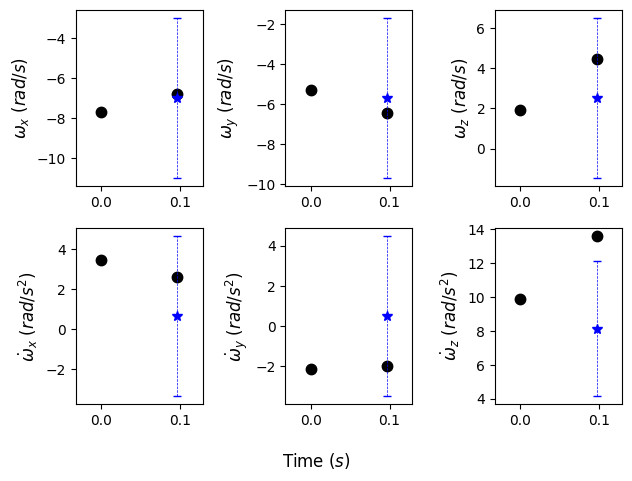

Current Batch Train Loss: -16.395051956176758

Current Batch Train Loss: -16.41384506225586

Current Batch Train Loss: -16.40285873413086

Current Batch Train Loss: -16.421113967895508

Current Batch Train Loss: -16.386520385742188

Epoch: 75, Batch Testing Loss: -16.389524459838867, Batch Testing Average RMSE: 25.373632431030273 w/ Standard Deviation: 18.511503219604492
Batch Testing Average NLL: 3.4179279804229736 w/ Standard Deviation: 4.093245506286621

Average Absolute Prediction Error (AAE) of Plotted Sample: 11.483383178710938


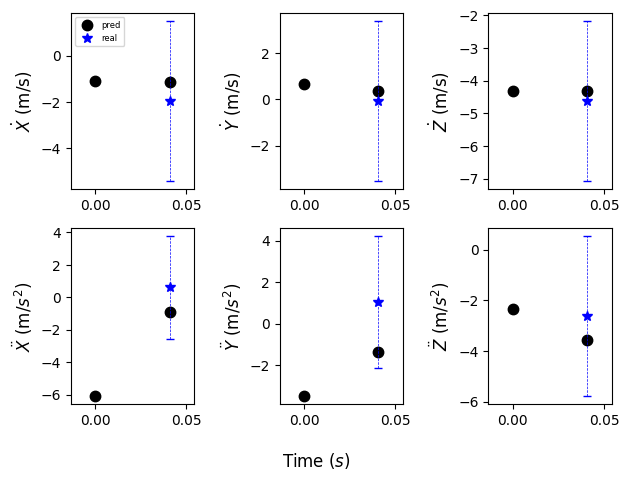

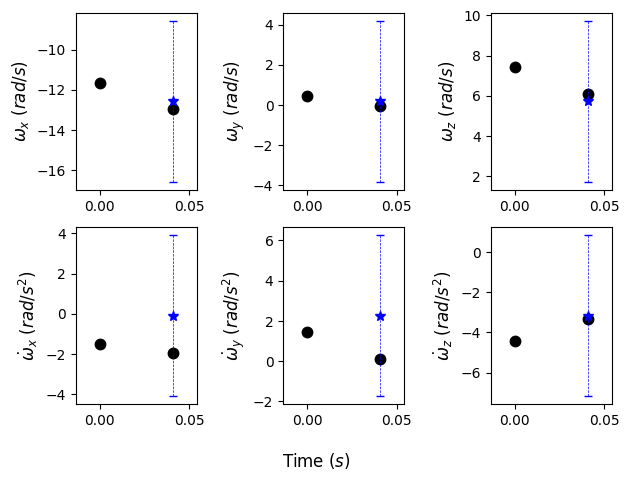

Current Batch Train Loss: -16.420408248901367

Current Batch Train Loss: -16.404159545898438

Current Batch Train Loss: -16.426219940185547

Current Batch Train Loss: -16.41547203063965

Current Batch Train Loss: -16.414011001586914

Epoch: 76, Batch Testing Loss: -16.42585563659668, Batch Testing Average RMSE: 24.25246810913086 w/ Standard Deviation: 15.089810371398926
Batch Testing Average NLL: 3.0377066135406494 w/ Standard Deviation: 2.8717191219329834

Average Absolute Prediction Error (AAE) of Plotted Sample: 10.780967712402344


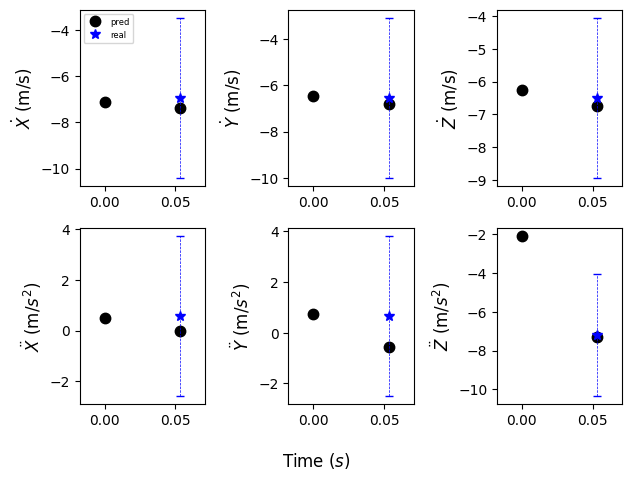

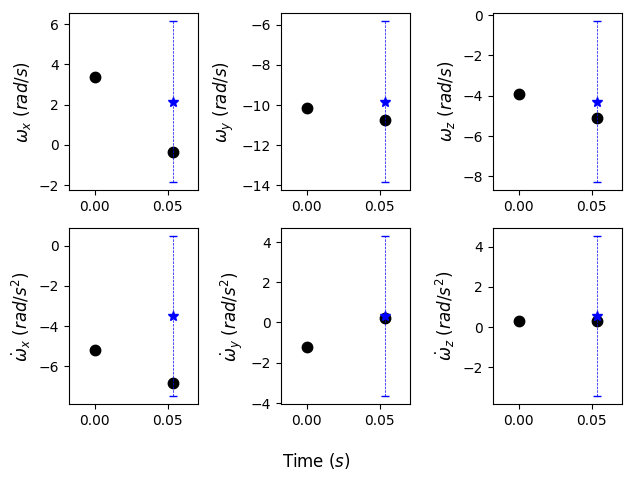

Current Batch Train Loss: -16.42120933532715

Current Batch Train Loss: -16.422664642333984

Current Batch Train Loss: -16.40203285217285

Current Batch Train Loss: -16.40732765197754

Current Batch Train Loss: -16.397932052612305

Epoch: 77, Batch Testing Loss: -16.408418655395508, Batch Testing Average RMSE: 25.371585845947266 w/ Standard Deviation: 15.875812530517578
Batch Testing Average NLL: 3.1972315311431885 w/ Standard Deviation: 2.8826279640197754

Average Absolute Prediction Error (AAE) of Plotted Sample: 41.07643127441406


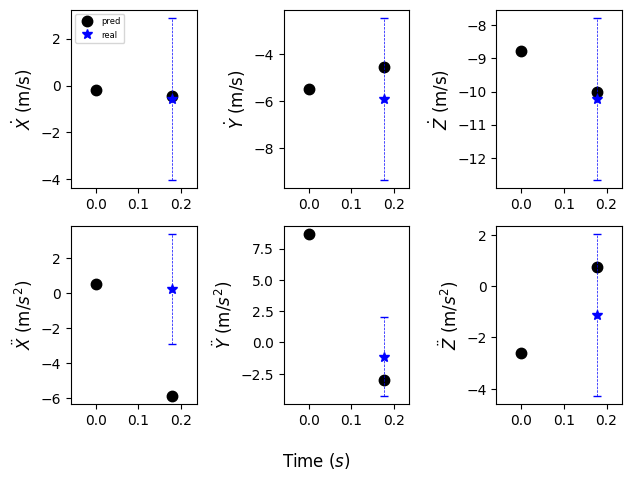

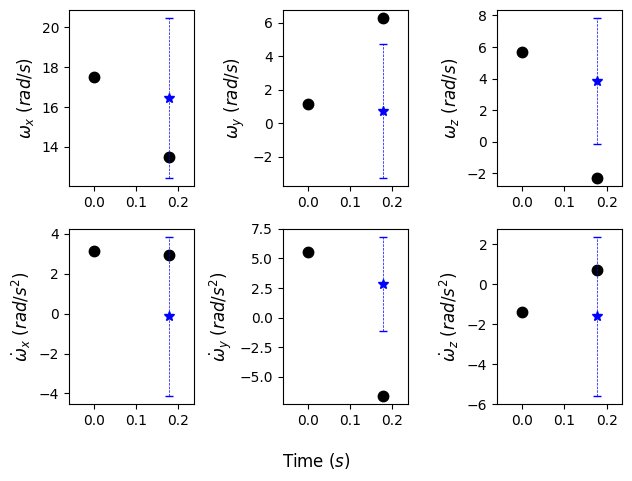

Current Batch Train Loss: -16.417720794677734

Current Batch Train Loss: -16.40242576599121

Current Batch Train Loss: -16.405487060546875

Current Batch Train Loss: -16.406051635742188

Current Batch Train Loss: -16.414134979248047

Epoch: 78, Batch Testing Loss: -16.40790367126465, Batch Testing Average RMSE: 25.117321014404297 w/ Standard Deviation: 15.347067832946777
Batch Testing Average NLL: 3.1722025871276855 w/ Standard Deviation: 2.5339720249176025

Average Absolute Prediction Error (AAE) of Plotted Sample: 27.500123977661133


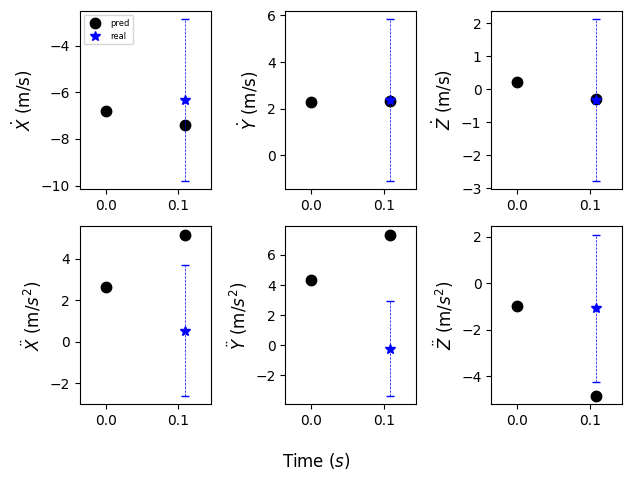

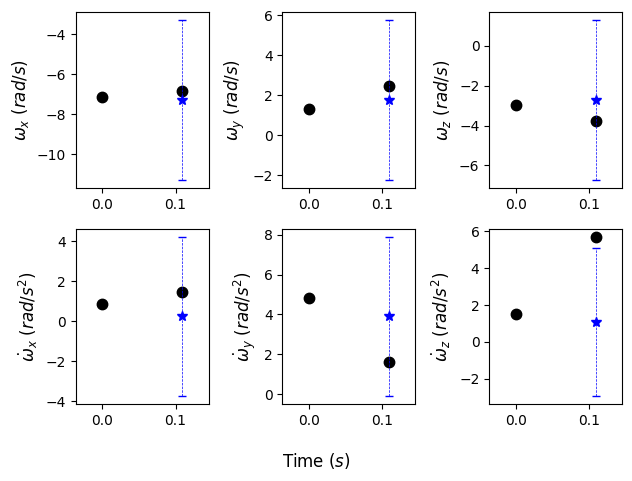

Current Batch Train Loss: -16.418926239013672

Current Batch Train Loss: -16.39501190185547

Current Batch Train Loss: -16.404582977294922

Current Batch Train Loss: -16.392261505126953

Current Batch Train Loss: -16.407779693603516

Epoch: 79, Batch Testing Loss: -16.405517578125, Batch Testing Average RMSE: 25.198171615600586 w/ Standard Deviation: 16.60919952392578
Batch Testing Average NLL: 3.2530763149261475 w/ Standard Deviation: 3.6008219718933105

Average Absolute Prediction Error (AAE) of Plotted Sample: 15.305122375488281


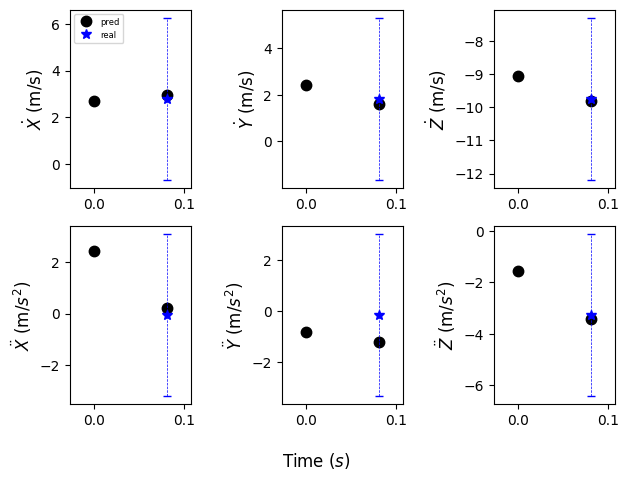

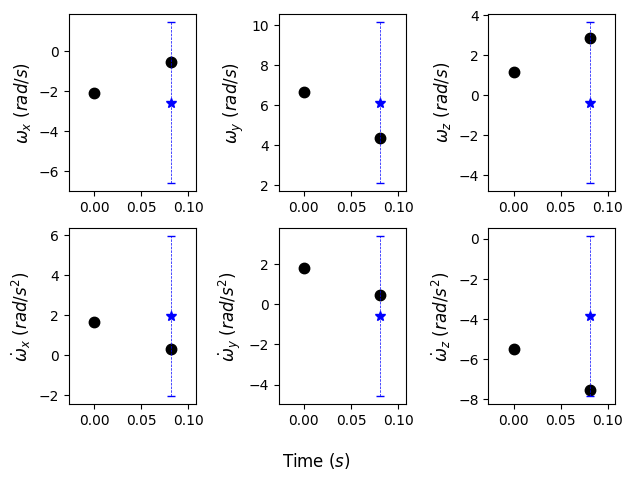

Current Batch Train Loss: -16.41712188720703

Current Batch Train Loss: -16.404945373535156

Current Batch Train Loss: -16.431903839111328

Current Batch Train Loss: -16.401430130004883

Current Batch Train Loss: -16.410921096801758

Epoch: 80, Batch Testing Loss: -16.40984344482422, Batch Testing Average RMSE: 24.917186737060547 w/ Standard Deviation: 16.653715133666992
Batch Testing Average NLL: 3.2085793018341064 w/ Standard Deviation: 2.8816325664520264

Average Absolute Prediction Error (AAE) of Plotted Sample: 12.465106964111328


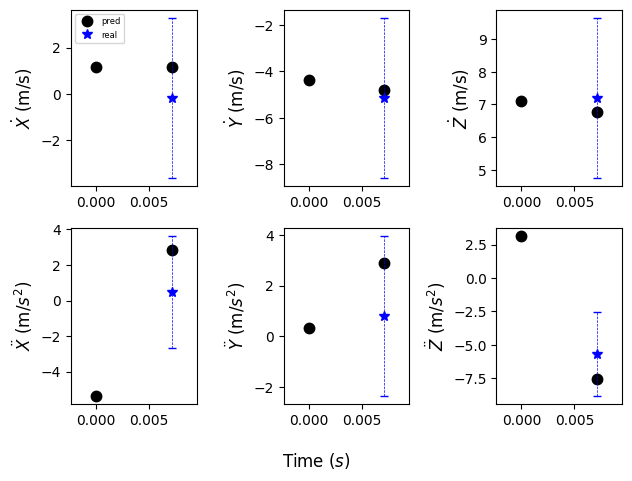

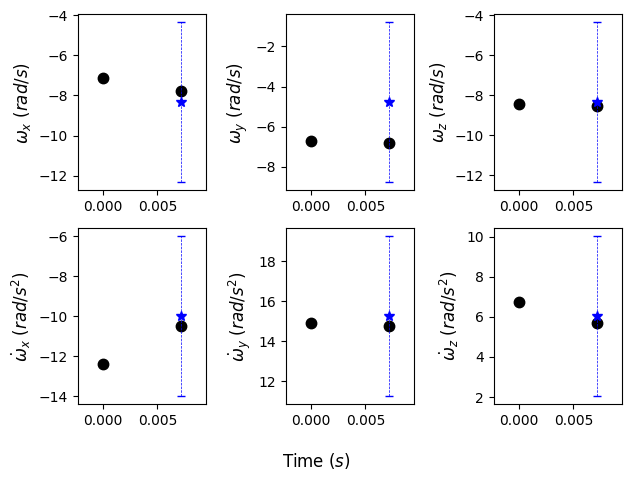

Current Batch Train Loss: -16.408920288085938

Current Batch Train Loss: -16.405805587768555

Current Batch Train Loss: -16.403884887695312

Current Batch Train Loss: -16.416109085083008

Current Batch Train Loss: -16.417150497436523

Epoch: 81, Batch Testing Loss: -16.39881134033203, Batch Testing Average RMSE: 25.377058029174805 w/ Standard Deviation: 17.018625259399414
Batch Testing Average NLL: 3.277949333190918 w/ Standard Deviation: 3.3538968563079834

Average Absolute Prediction Error (AAE) of Plotted Sample: 35.469764709472656


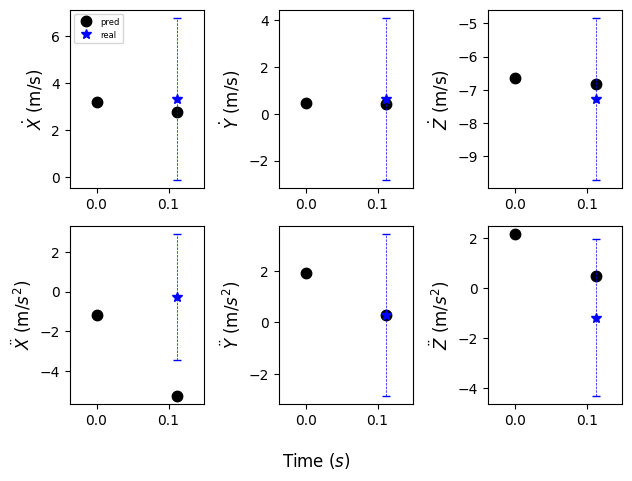

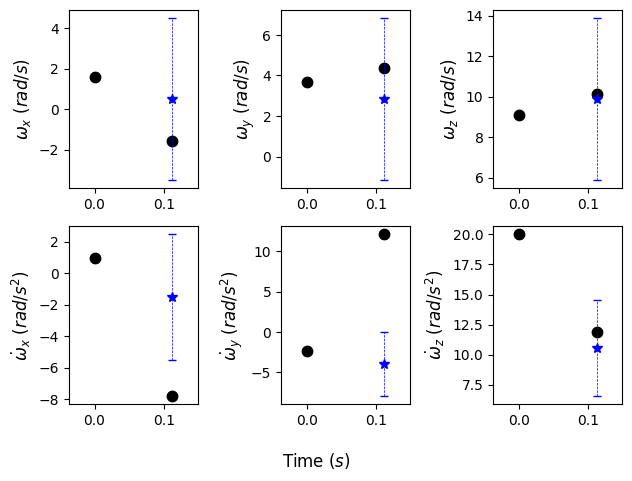

Current Batch Train Loss: -16.414281845092773

Current Batch Train Loss: -16.392066955566406

Current Batch Train Loss: -16.407512664794922

Current Batch Train Loss: -16.40013313293457

Current Batch Train Loss: -16.419235229492188

Epoch: 82, Batch Testing Loss: -16.388185501098633, Batch Testing Average RMSE: 26.10944175720215 w/ Standard Deviation: 17.663089752197266
Batch Testing Average NLL: 3.428537130355835 w/ Standard Deviation: 3.2735283374786377

Average Absolute Prediction Error (AAE) of Plotted Sample: 21.594507217407227


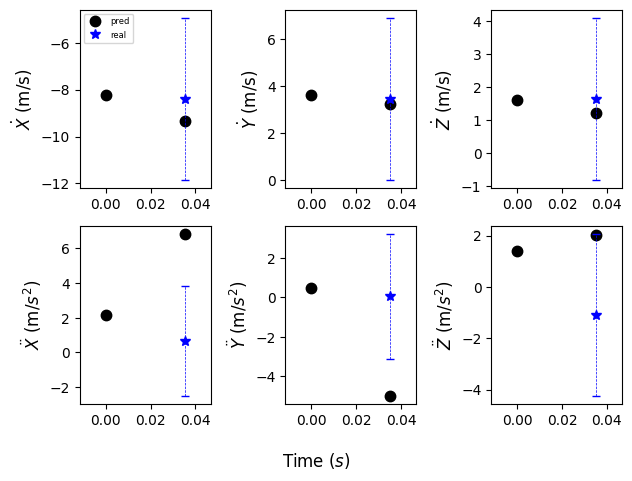

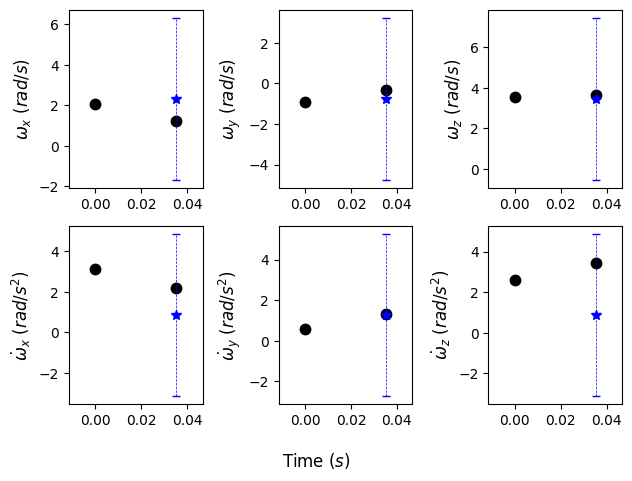

Current Batch Train Loss: -16.426013946533203

Current Batch Train Loss: -16.406583786010742

Current Batch Train Loss: -16.410051345825195

Current Batch Train Loss: -16.413610458374023

Current Batch Train Loss: -16.400623321533203

Epoch: 83, Batch Testing Loss: -16.40678596496582, Batch Testing Average RMSE: 24.693601608276367 w/ Standard Deviation: 17.304954528808594
Batch Testing Average NLL: 3.242074966430664 w/ Standard Deviation: 4.151822566986084

Average Absolute Prediction Error (AAE) of Plotted Sample: 15.70582389831543


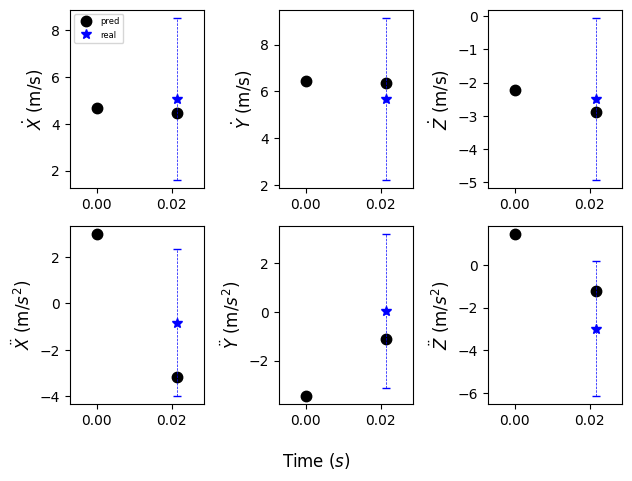

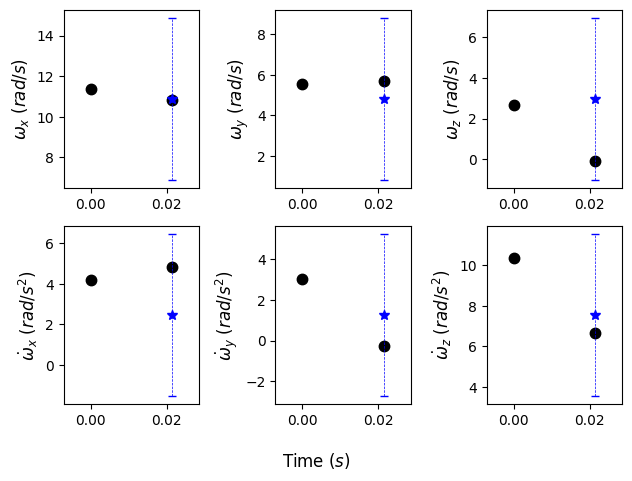

Current Batch Train Loss: -16.41977310180664

Current Batch Train Loss: -16.416072845458984

Current Batch Train Loss: -16.42857551574707

Current Batch Train Loss: -16.42418098449707

Current Batch Train Loss: -16.424171447753906

Epoch: 84, Batch Testing Loss: -16.410734176635742, Batch Testing Average RMSE: 24.69348907470703 w/ Standard Deviation: 16.452741622924805
Batch Testing Average NLL: 3.204892873764038 w/ Standard Deviation: 3.203627586364746

Average Absolute Prediction Error (AAE) of Plotted Sample: 7.704814910888672


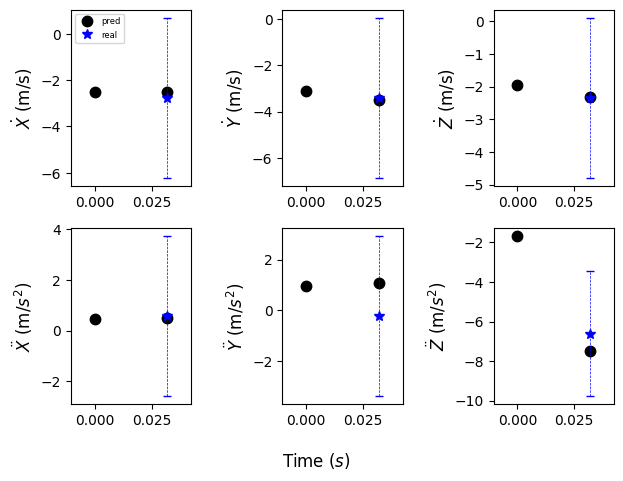

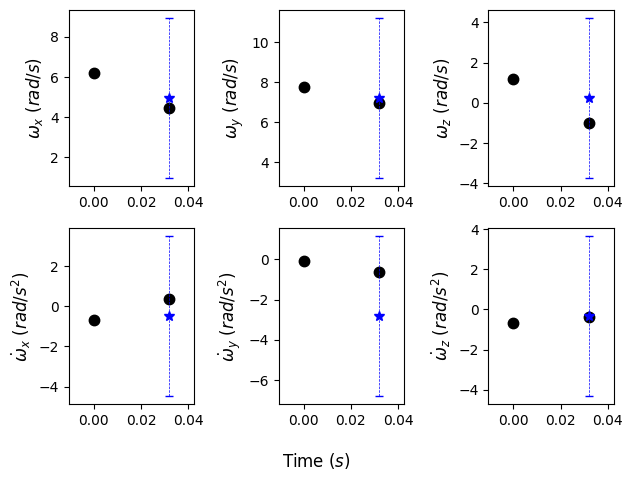

Current Batch Train Loss: -16.417211532592773

Current Batch Train Loss: -16.412710189819336

Current Batch Train Loss: -16.41497039794922

Current Batch Train Loss: -16.402652740478516

Current Batch Train Loss: -16.421409606933594

Epoch: 85, Batch Testing Loss: -16.42034339904785, Batch Testing Average RMSE: 24.4343318939209 w/ Standard Deviation: 15.55734920501709
Batch Testing Average NLL: 3.098088026046753 w/ Standard Deviation: 2.7286949157714844

Average Absolute Prediction Error (AAE) of Plotted Sample: 16.308307647705078


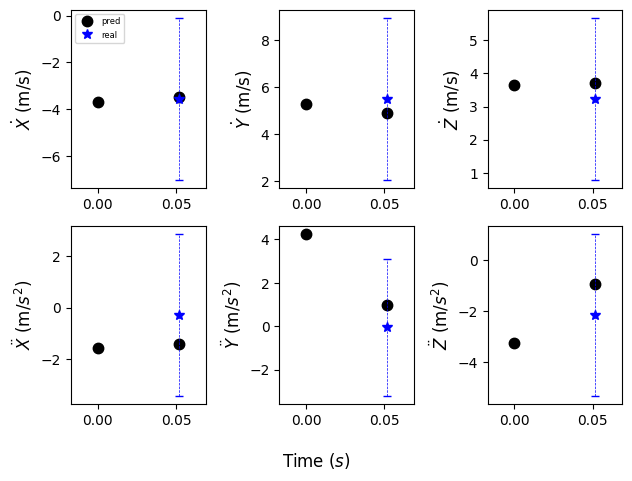

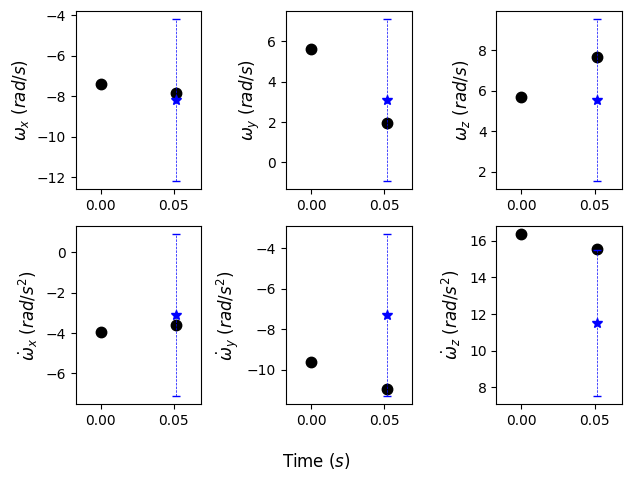

Current Batch Train Loss: -16.433948516845703

Current Batch Train Loss: -16.40898323059082

Current Batch Train Loss: -16.400480270385742

Current Batch Train Loss: -16.399831771850586

Current Batch Train Loss: -16.398298263549805

Epoch: 86, Batch Testing Loss: -16.419466018676758, Batch Testing Average RMSE: 24.085073471069336 w/ Standard Deviation: 15.616819381713867
Batch Testing Average NLL: 3.1197144985198975 w/ Standard Deviation: 3.2009758949279785

Average Absolute Prediction Error (AAE) of Plotted Sample: 39.263919830322266


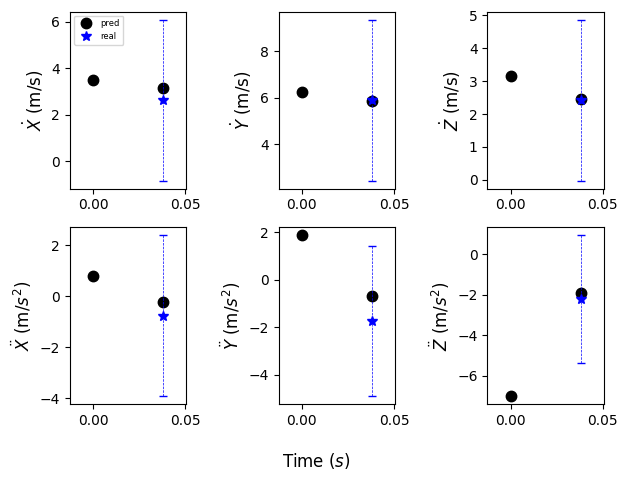

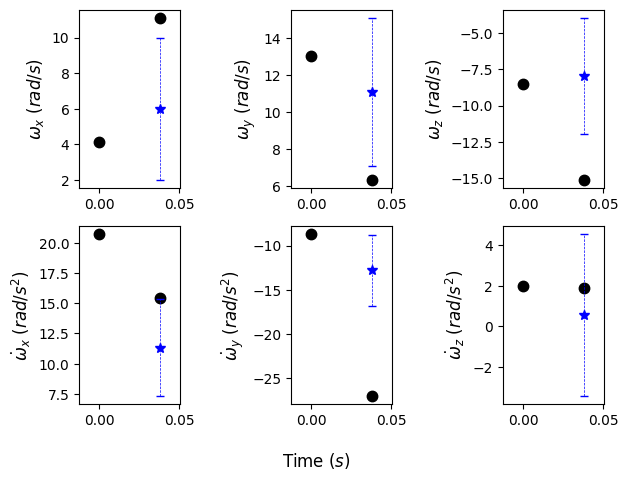

Current Batch Train Loss: -16.417818069458008

Current Batch Train Loss: -16.38755989074707

Current Batch Train Loss: -16.40911102294922

Current Batch Train Loss: -16.430992126464844

Current Batch Train Loss: -16.414453506469727

Epoch: 87, Batch Testing Loss: -16.4036808013916, Batch Testing Average RMSE: 25.17571449279785 w/ Standard Deviation: 16.52857208251953
Batch Testing Average NLL: 3.2489075660705566 w/ Standard Deviation: 2.9242167472839355

Average Absolute Prediction Error (AAE) of Plotted Sample: 13.17916488647461


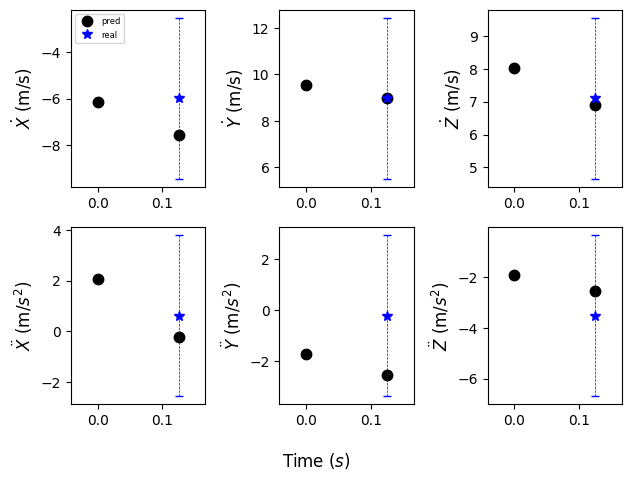

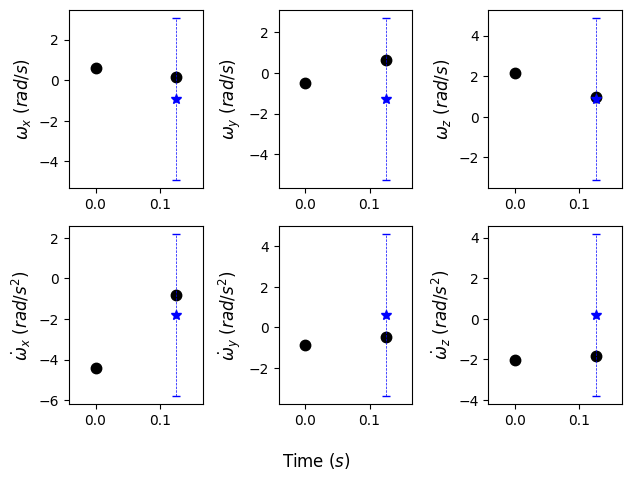

Current Batch Train Loss: -16.412748336791992

Current Batch Train Loss: -16.3979434967041

Current Batch Train Loss: -16.425779342651367

Current Batch Train Loss: -16.404579162597656

Current Batch Train Loss: -16.42074966430664

Epoch: 88, Batch Testing Loss: -16.39183235168457, Batch Testing Average RMSE: 25.551239013671875 w/ Standard Deviation: 18.004596710205078
Batch Testing Average NLL: 3.4076919555664062 w/ Standard Deviation: 4.610609531402588

Average Absolute Prediction Error (AAE) of Plotted Sample: 12.698135375976562


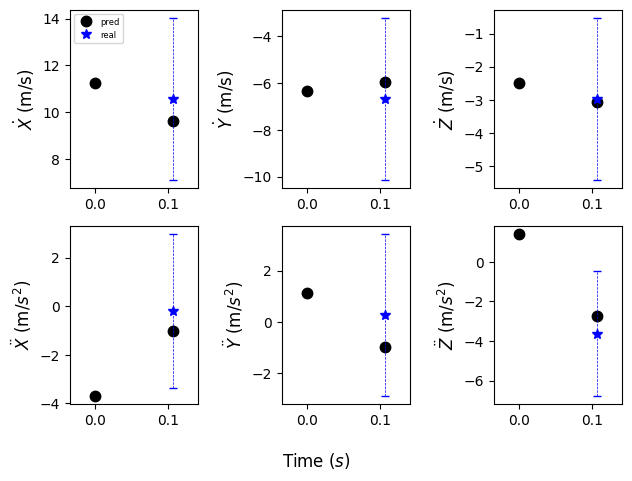

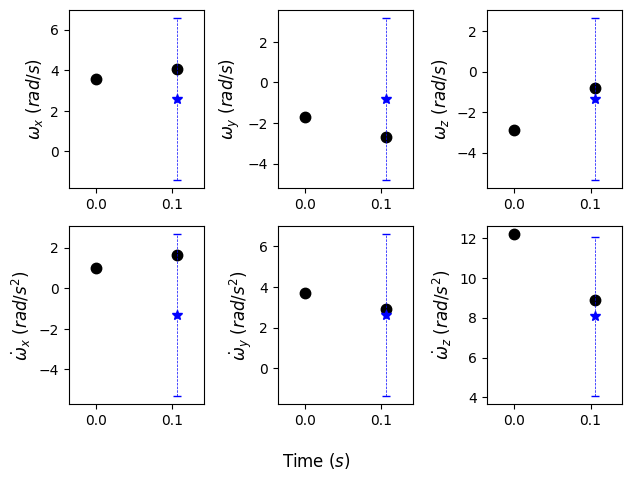

Current Batch Train Loss: -16.389659881591797

Current Batch Train Loss: -16.394826889038086

Current Batch Train Loss: -16.417221069335938

Current Batch Train Loss: -16.411935806274414

Current Batch Train Loss: -16.41830825805664

Epoch: 89, Batch Testing Loss: -16.431732177734375, Batch Testing Average RMSE: 24.02114486694336 w/ Standard Deviation: 14.08188247680664
Batch Testing Average NLL: 2.9739160537719727 w/ Standard Deviation: 2.022796392440796

Average Absolute Prediction Error (AAE) of Plotted Sample: 18.846445083618164


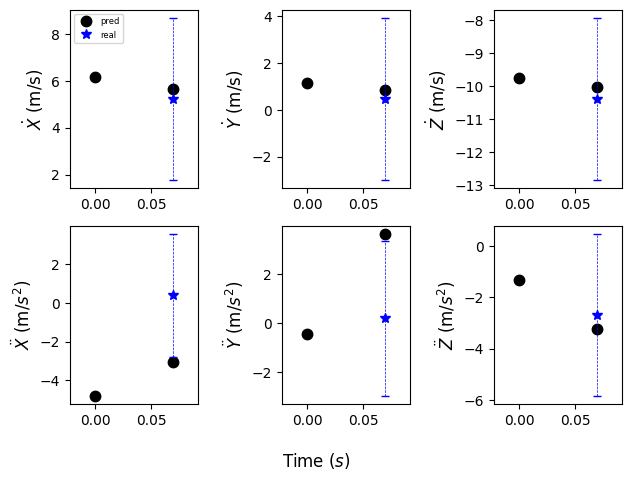

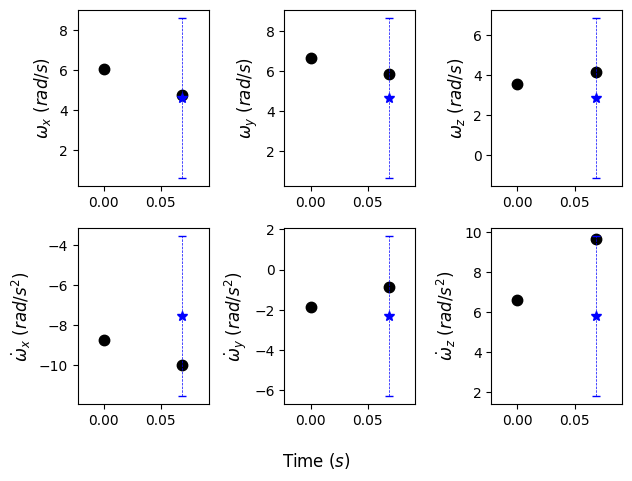

Current Batch Train Loss: -16.413652420043945

Current Batch Train Loss: -16.410358428955078

Current Batch Train Loss: -16.393844604492188

Current Batch Train Loss: -16.40825653076172

Current Batch Train Loss: -16.421554565429688

Epoch: 90, Batch Testing Loss: -16.427968978881836, Batch Testing Average RMSE: 23.722124099731445 w/ Standard Deviation: 15.593710899353027
Batch Testing Average NLL: 3.0340561866760254 w/ Standard Deviation: 2.810333013534546

Average Absolute Prediction Error (AAE) of Plotted Sample: 44.3665657043457


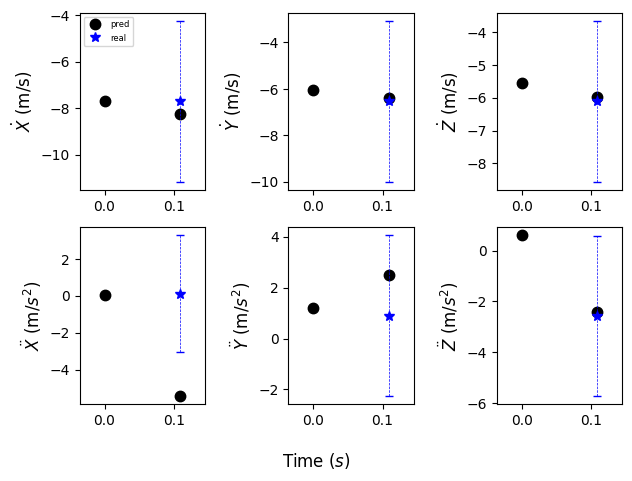

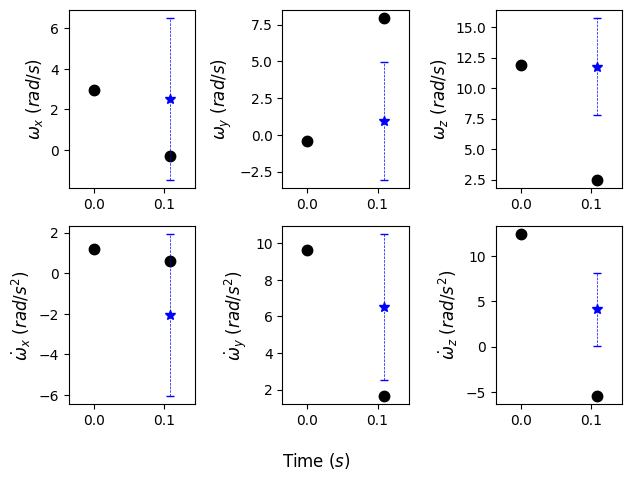

Current Batch Train Loss: -16.413320541381836

Current Batch Train Loss: -16.4017391204834

Current Batch Train Loss: -16.392934799194336

Current Batch Train Loss: -16.40877914428711

Current Batch Train Loss: -16.429885864257812

Epoch: 91, Batch Testing Loss: -16.409679412841797, Batch Testing Average RMSE: 24.663381576538086 w/ Standard Deviation: 16.57762336730957
Batch Testing Average NLL: 3.1958205699920654 w/ Standard Deviation: 4.503531455993652

Average Absolute Prediction Error (AAE) of Plotted Sample: 9.818729400634766


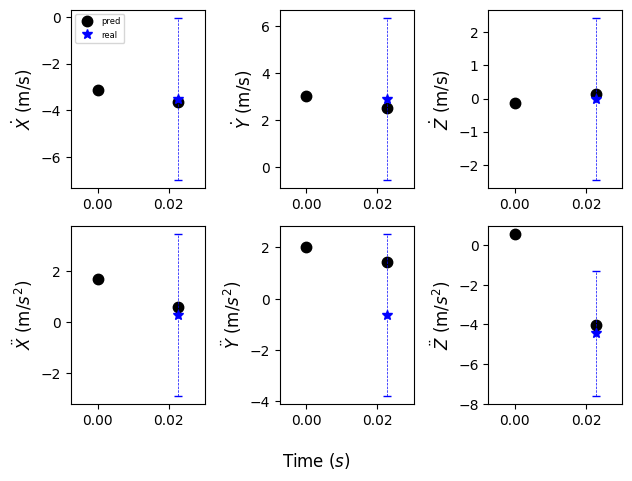

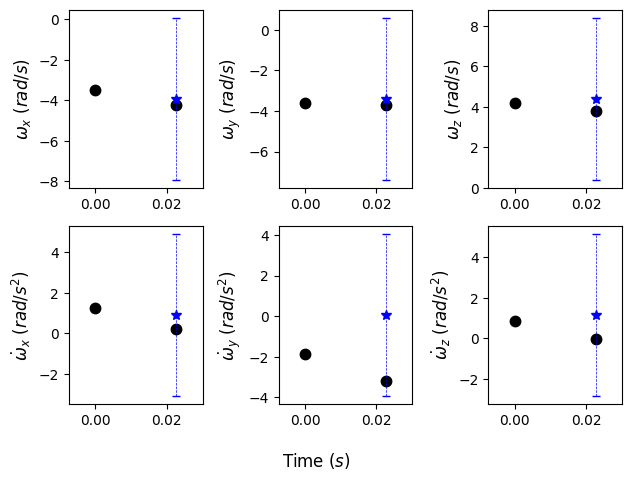

Current Batch Train Loss: -16.41445541381836

Current Batch Train Loss: -16.428823471069336

Current Batch Train Loss: -16.40294647216797

Current Batch Train Loss: -16.412561416625977

Current Batch Train Loss: -16.413793563842773

Epoch: 92, Batch Testing Loss: -16.391157150268555, Batch Testing Average RMSE: 25.732248306274414 w/ Standard Deviation: 17.356908798217773
Batch Testing Average NLL: 3.376556634902954 w/ Standard Deviation: 3.368558645248413

Average Absolute Prediction Error (AAE) of Plotted Sample: 17.796276092529297


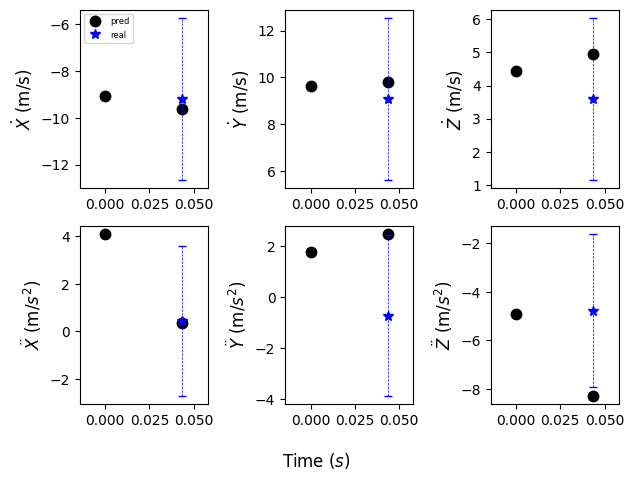

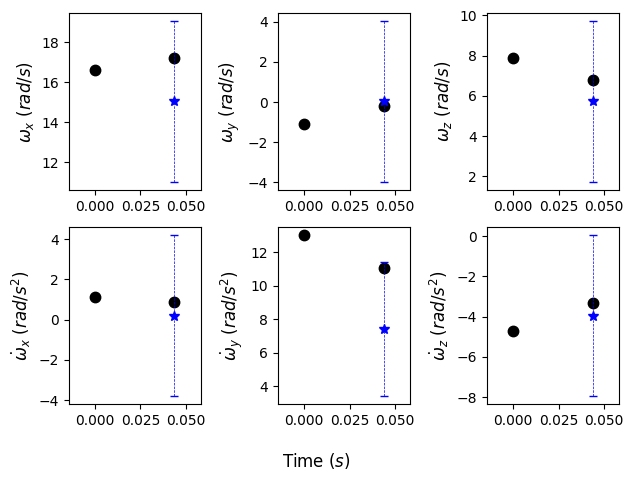

Current Batch Train Loss: -16.416404724121094

Current Batch Train Loss: -16.42403793334961

Current Batch Train Loss: -16.419218063354492

Current Batch Train Loss: -16.428709030151367

Current Batch Train Loss: -16.41724395751953

Epoch: 93, Batch Testing Loss: -16.416316986083984, Batch Testing Average RMSE: 24.660022735595703 w/ Standard Deviation: 15.876490592956543
Batch Testing Average NLL: 3.1436891555786133 w/ Standard Deviation: 2.5435097217559814

Average Absolute Prediction Error (AAE) of Plotted Sample: 19.435813903808594


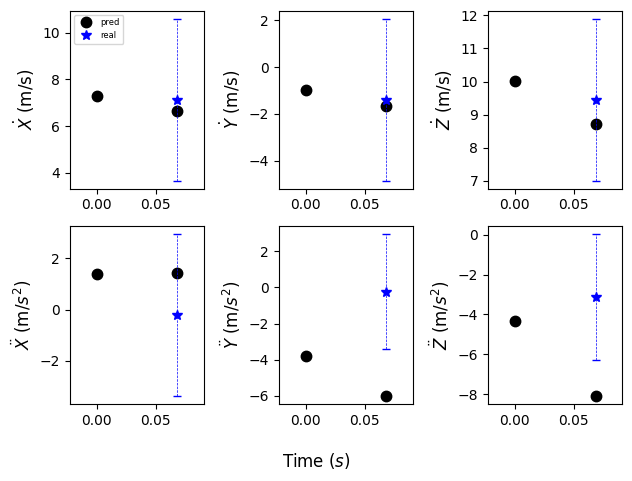

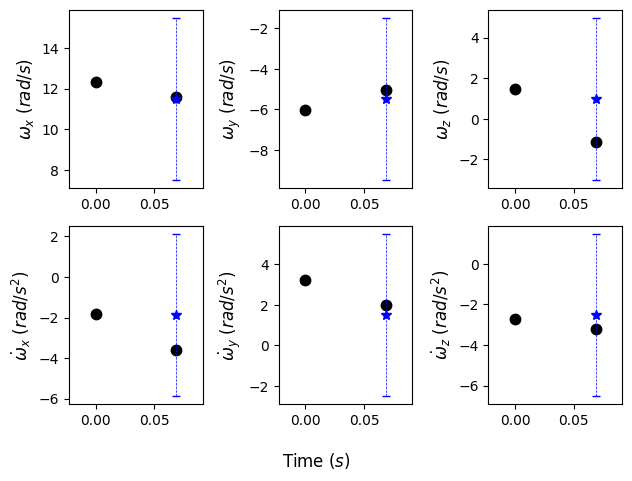

Current Batch Train Loss: -16.423738479614258

Current Batch Train Loss: -16.39550018310547

Current Batch Train Loss: -16.417245864868164

Current Batch Train Loss: -16.413532257080078

Current Batch Train Loss: -16.427366256713867

Epoch: 94, Batch Testing Loss: -16.404590606689453, Batch Testing Average RMSE: 24.801416397094727 w/ Standard Deviation: 16.889245986938477
Batch Testing Average NLL: 3.2284045219421387 w/ Standard Deviation: 3.3233730792999268

Average Absolute Prediction Error (AAE) of Plotted Sample: 13.48543930053711


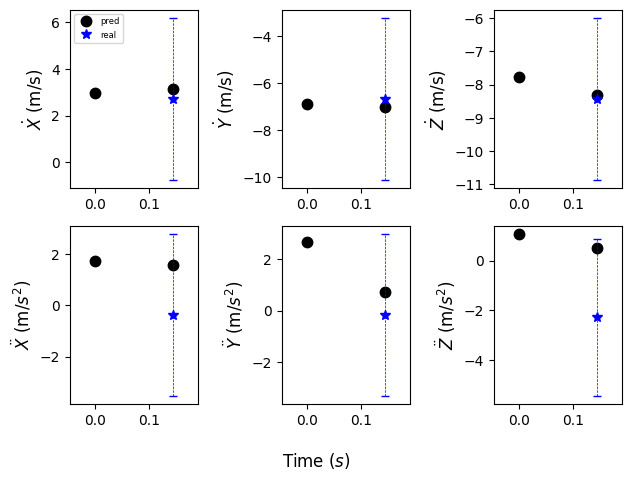

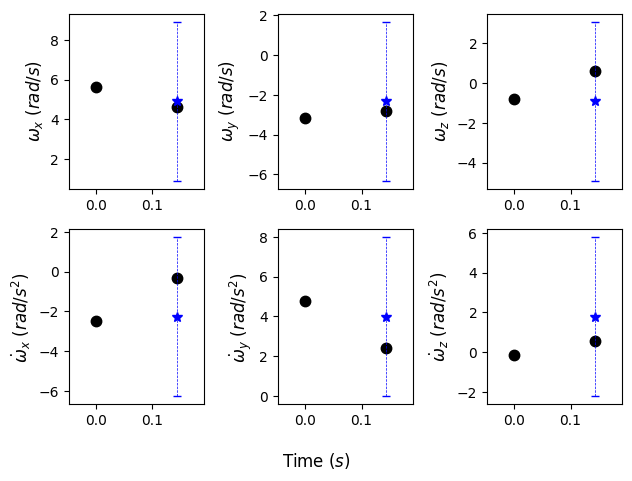

Current Batch Train Loss: -16.40875816345215

Current Batch Train Loss: -16.425674438476562

Current Batch Train Loss: -16.41431999206543

Current Batch Train Loss: -16.414722442626953

Current Batch Train Loss: -16.416301727294922

Epoch: 95, Batch Testing Loss: -16.424253463745117, Batch Testing Average RMSE: 24.189441680908203 w/ Standard Deviation: 15.863741874694824
Batch Testing Average NLL: 3.087759256362915 w/ Standard Deviation: 3.0228445529937744

Average Absolute Prediction Error (AAE) of Plotted Sample: 40.05636215209961


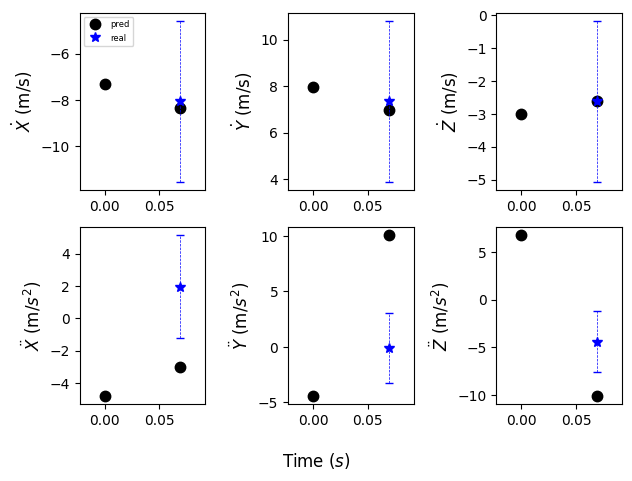

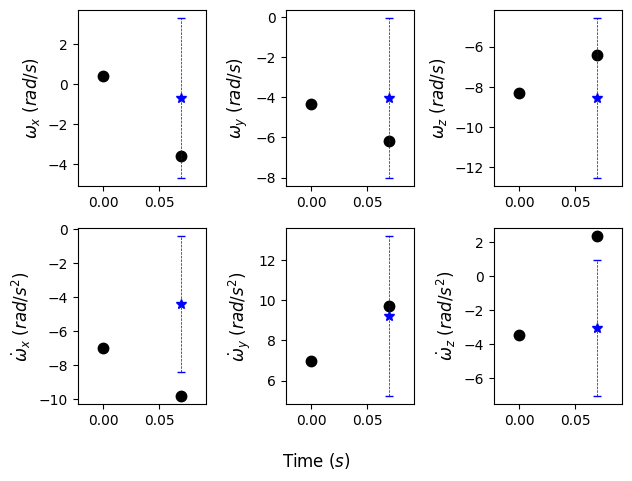

Current Batch Train Loss: -16.403324127197266

Current Batch Train Loss: -16.415164947509766

Current Batch Train Loss: -16.422748565673828

Current Batch Train Loss: -16.415950775146484

Current Batch Train Loss: -16.420316696166992

Epoch: 96, Batch Testing Loss: -16.412500381469727, Batch Testing Average RMSE: 25.023799896240234 w/ Standard Deviation: 15.192107200622559
Batch Testing Average NLL: 3.1260602474212646 w/ Standard Deviation: 2.480956792831421

Average Absolute Prediction Error (AAE) of Plotted Sample: 25.837215423583984


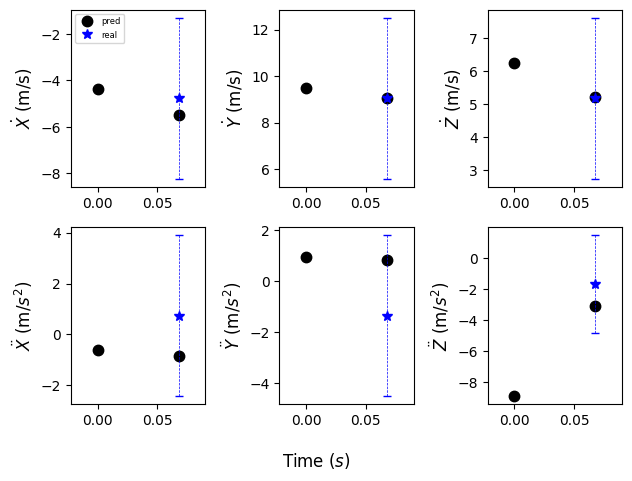

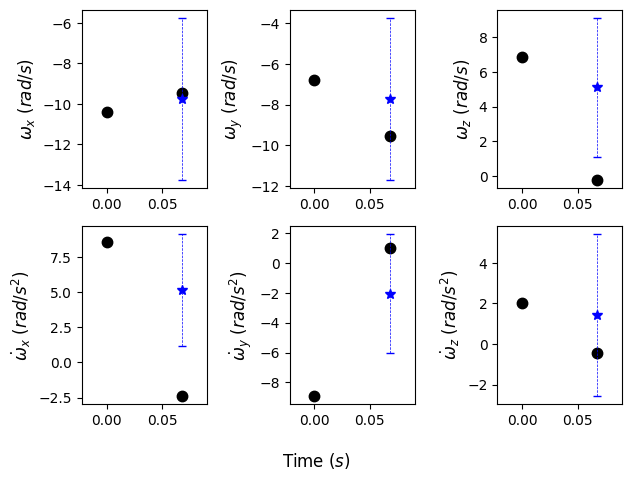

Current Batch Train Loss: -16.420705795288086

Current Batch Train Loss: -16.429065704345703

Current Batch Train Loss: -16.427627563476562

Current Batch Train Loss: -16.42205047607422

Current Batch Train Loss: -16.41397476196289

Epoch: 97, Batch Testing Loss: -16.390357971191406, Batch Testing Average RMSE: 25.73541259765625 w/ Standard Deviation: 17.17673683166504
Batch Testing Average NLL: 3.3850667476654053 w/ Standard Deviation: 4.508138656616211

Average Absolute Prediction Error (AAE) of Plotted Sample: 20.038848876953125


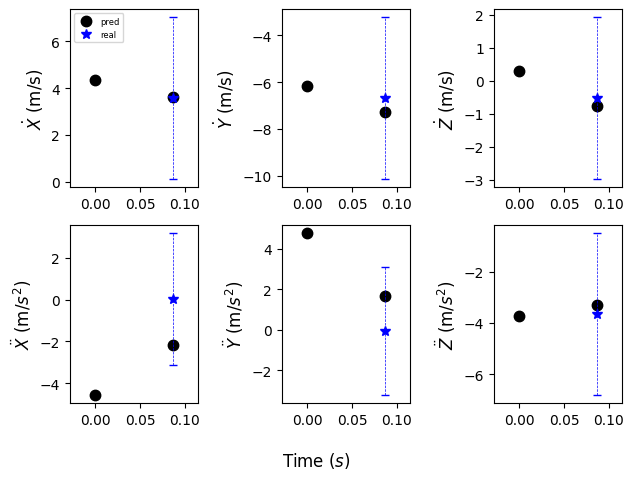

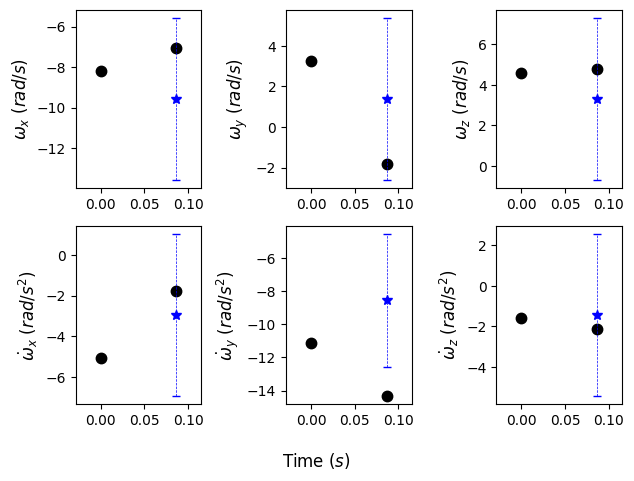

Current Batch Train Loss: -16.40146827697754

Current Batch Train Loss: -16.40165901184082

Current Batch Train Loss: -16.399324417114258

Current Batch Train Loss: -16.430572509765625

Current Batch Train Loss: -16.410852432250977

Epoch: 98, Batch Testing Loss: -16.415491104125977, Batch Testing Average RMSE: 24.03754997253418 w/ Standard Deviation: 16.67511558532715
Batch Testing Average NLL: 3.142901659011841 w/ Standard Deviation: 3.60925030708313

Average Absolute Prediction Error (AAE) of Plotted Sample: 27.987655639648438


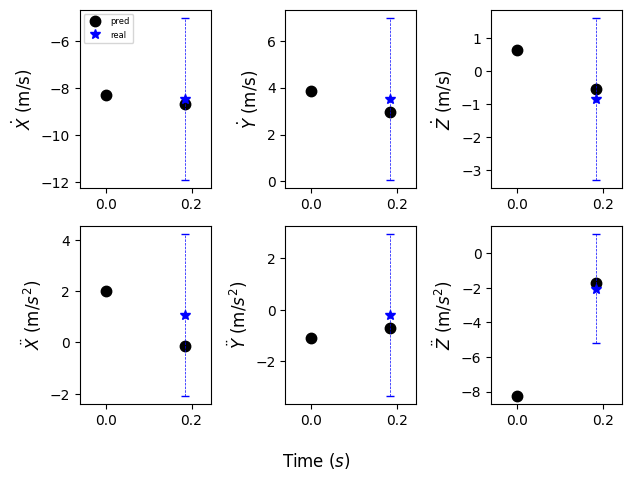

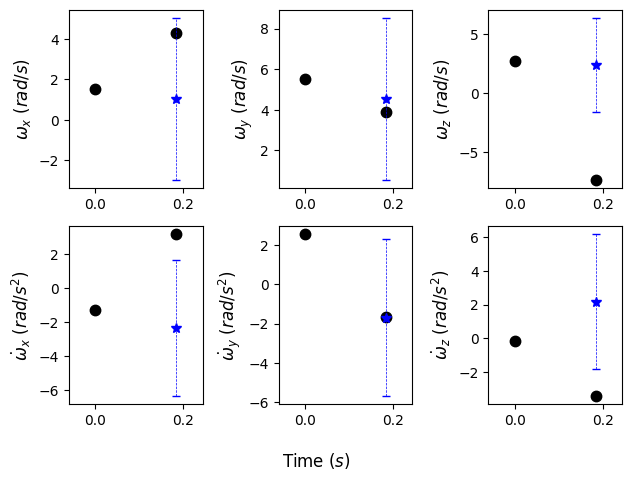

Current Batch Train Loss: -16.405899047851562

Current Batch Train Loss: -16.409719467163086

Current Batch Train Loss: -16.427570343017578

Current Batch Train Loss: -16.400054931640625

Current Batch Train Loss: -16.42645835876465

Epoch: 99, Batch Testing Loss: -16.423742294311523, Batch Testing Average RMSE: 23.934242248535156 w/ Standard Deviation: 15.344802856445312
Batch Testing Average NLL: 3.0603089332580566 w/ Standard Deviation: 2.8155317306518555

Average Absolute Prediction Error (AAE) of Plotted Sample: 14.112874984741211


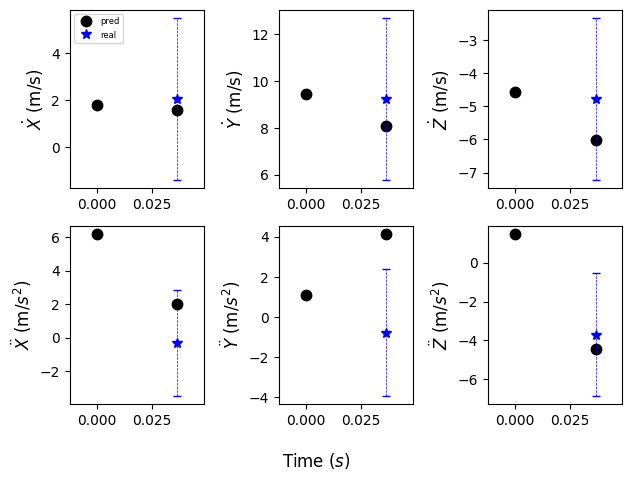

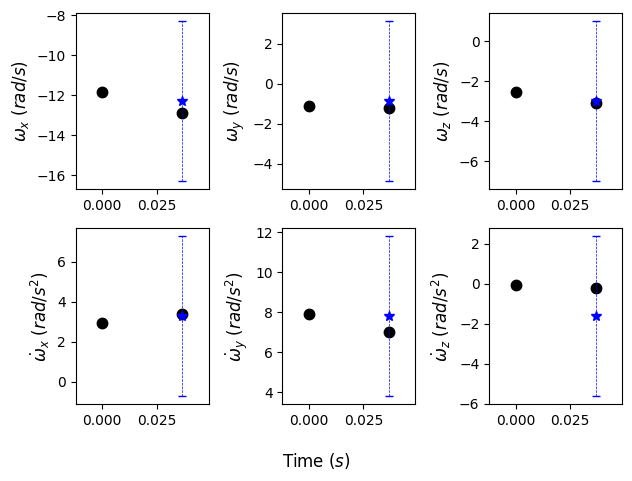

Current Batch Train Loss: -16.40924644470215

Current Batch Train Loss: -16.43299674987793

Current Batch Train Loss: -16.400075912475586

Current Batch Train Loss: -16.425987243652344

Current Batch Train Loss: -16.41206169128418

Epoch: 100, Batch Testing Loss: -16.42083168029785, Batch Testing Average RMSE: 23.863773345947266 w/ Standard Deviation: 16.221256256103516
Batch Testing Average NLL: 3.109668731689453 w/ Standard Deviation: 4.125418186187744

Average Absolute Prediction Error (AAE) of Plotted Sample: 24.618759155273438


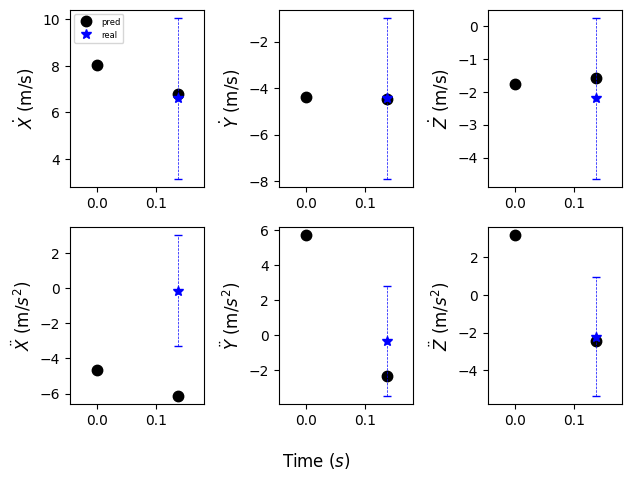

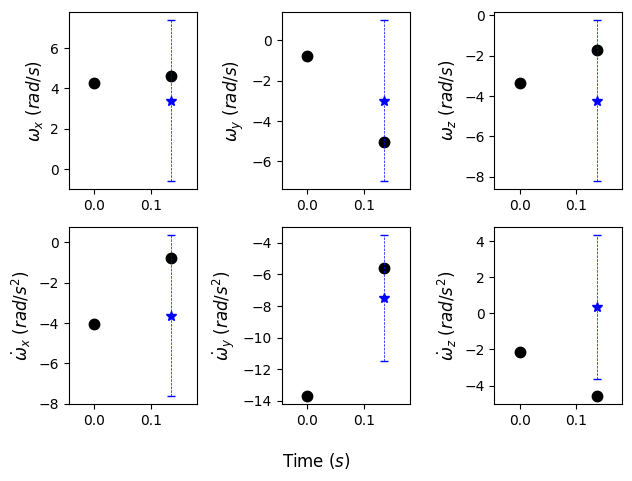

Current Batch Train Loss: -16.41118621826172

Current Batch Train Loss: -16.405284881591797

Current Batch Train Loss: -16.421363830566406

Current Batch Train Loss: -16.404083251953125

Current Batch Train Loss: -16.388856887817383



In [16]:
# Initializing LNP model
encoder_input = torch.concat([context_x, context_y], dim=-1)
encoder_size = encoder_input.shape[2]

# Move the model to the specified device (GPU or CPU)
model = AttLNP(
    state_dim=12,
    control_dim=4,
)

# Initializing model's loss function and optimizer
criterion = LossFunc().to(device)  # Move criterion to the device
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-7, amsgrad=True)

# Initializing training + validation loss tracker
train_loss_array = np.array([])
train_iter_array = np.array([])
val_loss_array = np.array([])
val_RMSE_array = np.array([])
coverage_array = np.array([])
nll_array = np.array([])
val_epoch_array = np.linspace(0, NUM_EPOCHS, int(NUM_EPOCHS/PLOT_AFTER)+1)

# Initializing training loop
i = 0
for epoch in range(NUM_EPOCHS+1):

  if epoch % PLOT_AFTER == 0:
    with torch.no_grad():

      # Sampling random validation batch
      idx = random.randint(0, test_dataset.shape[0]-BATCH_SIZE)
      batch_dataset = test_dataset[idx:idx+BATCH_SIZE,:,:]
      input = batch_dataset[:,:,:5].to(device)
      output = batch_dataset[:,:,5:].to(device)

      # Defining context and target sets
      context_x = input[:,0:1,:].clone()
      context_y = output[:,0:1,:].clone()
      target_x = input.clone()
      target_y = output.clone()
      
      # Initializing query object for model
      query = ((context_x, context_y), target_x)

      # Collecting predicted outputs + their associated variances + loss info
      # from comparing to ground-truth dynamical data
      log_p, kl, pred_y, var = model(query, target_y, is_testing=True)

      # Collecting loss from prediction
      loss_test = criterion(log_p, kl)

      # Unnormalizing data for plotting and computing AAE
      target_y, pred_y, var = db.minmax_unnorm(target_y, pred_y, var)

      # Computing average negative log-likelihood (NLL) over current testing batch
      nll, nll_std = compute_avg_nll(target_y[:,-1,:].detach().cpu(), pred_y[:,-1,:].detach().cpu(), var[:,-1,:].detach().cpu())

      # Computing root mean squared error (RMSE) over current testing batch
      batch_RMSE, batch_RMSE_std = compute_RMSE(target_y.detach().cpu().numpy(), pred_y.detach().cpu().numpy())
      val_RMSE_array = np.concatenate([val_RMSE_array, np.array([batch_RMSE])], axis=0)

      # Recording performance after every 'PLOT_AFTER' iterations
      print(f"Epoch: {epoch}, Batch Testing Loss: {loss_test.item()}, Batch Testing Average RMSE: {batch_RMSE} w/ Standard Deviation: {batch_RMSE_std}")
      print(f"Batch Testing Average NLL: {nll.item()} w/ Standard Deviation: {nll_std.item()}\n")
      plot_all_functions(context_x, context_y, target_x, target_y, pred_y, var)

      # Collecting validation loss history
      val_loss_array = np.concatenate([val_loss_array, np.array([loss_test.item()])], axis=0)
      
      # Saving model after every 'SAVE_MODEL_AFTER' epochs
      if epoch % SAVE_MODEL_AFTER == 0: torch.save(model, f'trained-model-epoch-{epoch}.pt')

  # Executing training loop
  for batch in range(0, train_dataset.shape[0], BATCH_SIZE):
    # Parsing batch dataset
    batch_dataset = train_dataset[batch: batch+BATCH_SIZE,:,:]
    input = batch_dataset[:,:,:5].to(device)
    output = batch_dataset[:,:,5:].to(device)

    # Defining context and target sets
    context_x = input[:,0:1,:].clone()
    context_y = output[:,0:1,:].clone()
    target_x = input.clone()
    target_y = output.clone()

    # Forming batch query of state transitions to be predicted by model
    query = ((context_x, context_y), target_x)

    # zero the parameter gradients for each batch
    optimizer.zero_grad()

    # forward + back propogation + optimizer step
    log_p, kl, pred_y, _ = model(query, target_y)
    loss_train = criterion(log_p, kl)
    loss_train.backward()
    optimizer.step()

    # Collecting training loss history after every 'COLLECT_TRAINING_LOSS_AFTER' iters
    if i % COLLECT_TRAINING_LOSS_AFTER == 1:
      print(f"Current Batch Train Loss: {loss_train.item()}\n")
      train_loss_array = np.concatenate([train_loss_array, np.array([loss_train.detach().cpu().item()])], axis=0)
      train_iter_array = np.concatenate([train_iter_array, np.array([i])], axis=0)
    i += 1

  # Shuffle the training dataset after each epoch
  train_dataset, train_dataset_unnorm = shuffle_data(train_dataset, train_dataset_unnorm)


#### Forward Pass Compute Wall-Time

In [79]:
import torch
import time
import random
import numpy as np

# Ensure model is on CPU
device = torch.device("cpu")
model.to(device)
model.eval()

# Parameters
BATCH_SIZE = 1000
NUM_TRIALS = 100
timings = []

for _ in range(NUM_TRIALS):
    # Sampling random validation batch
    idx = random.randint(0, test_dataset.shape[0] - BATCH_SIZE)
    batch_dataset = test_dataset[idx:idx + BATCH_SIZE, :, :]
    input = batch_dataset[:, :, :5].to(device)
    output = batch_dataset[:, :, 5:].to(device)

    # Defining context and target sets
    context_x = input[:, 0:1, :].clone()
    context_y = output[:, 0:1, :].clone()
    target_x = input.clone()
    target_y = output.clone()

    # Initializing query object for model
    query = ((context_x, context_y), target_x)

    # Timing forward pass
    start_time = time.time()
    with torch.no_grad():
        log_p, kl, pred_y, var = model(query, target_y, is_testing=True)
    end_time = time.time()

    timings.append(end_time - start_time)

# Compute mean and std
mean_time = np.mean(timings)
std_time = np.std(timings)

print(f"Average forward pass time over {NUM_TRIALS} runs: {mean_time:.4f} s ± {std_time:.4f} s")


Average forward pass time over 100 runs: 0.0071 s ± 0.0138 s


### Plotting Training Results

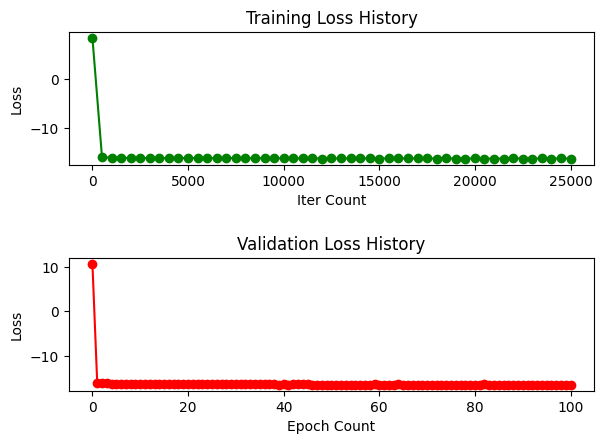

In [80]:
val_epoch_array = np.linspace(0, NUM_EPOCHS, int(NUM_EPOCHS/PLOT_AFTER)+1)

# Plotting both training+testing loss vs iteration
figure, axis = plt.subplots(2,1)
axis[0].plot(train_iter_array[::10], train_loss_array[::10], 'go-')
axis[0].set_xlabel('Iter Count')
axis[0].set_ylabel('Loss')
axis[0].set_title('Training Loss History')

axis[1].plot(val_epoch_array, val_loss_array, 'ro-')
axis[1].set_xlabel('Epoch Count')
axis[1].set_ylabel('Loss')
axis[1].set_title('Validation Loss History')


figure.tight_layout(pad=2.0)
plt.show()

Text(0.5, 1.0, 'Validation Average Absolute Prediction Error History')

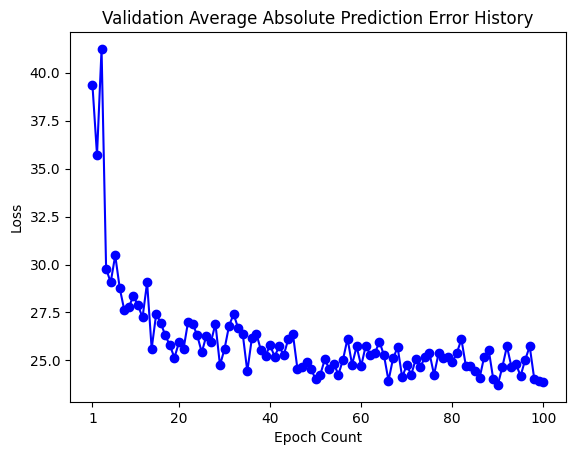

In [51]:
plt.plot(val_epoch_array[1:], val_RMSE_array[1:], 'bo-')
plt.xlabel('Epoch Count')
plt.ylabel('Loss')
plt.xticks([1, 20, 40, 60, 80, 100])
plt.title('Validation Average Absolute Prediction Error History')

### Evaluation: Predicted Context Mode

Helper Functions

In [52]:
def compute_AE(target_y, pred_y):
  # Computing absolute prediction error (AE)
  state_diff = np.abs(target_y[:,-1,:] - pred_y[:,-1,:])
  AE_array = np.sum(state_diff, axis=1)
  
  return AE_array

def scaled_compute_AE(target_y, pred_y):
  # Computing absolute prediction error (AE)
  scaled_state_diff = np.abs((target_y[:,-1,:] - pred_y[:,-1,:]) / target_y[:,-1,:]) * 100
  scaled_AE_array = np.mean(scaled_state_diff)

  return scaled_AE_array


def compute_state_RMSE(target_y, pred_y):
    """
    Compute the batch-averaged sum of RMSEs for each state at the final time step.
    
    Args:
        target_y (np.ndarray): Shape (batch_size, time_steps, state_dim)
        pred_y (np.ndarray): Shape (batch_size, time_steps, state_dim)
    
    Returns:
        float: Scalar RMSE value averaged over the batch.
    """
    # Compute squared error at the final time step
    linvel_diff_squared = (target_y[:, -1, :3] - pred_y[:, -1, :3]) ** 2  # Shape: (batch_size, state_dim)
    linacc_diff_squared = (target_y[:, -1, 3:6] - pred_y[:, -1, 3:6]) ** 2  # Shape: (batch_size, state_dim)
    angvel_diff_squared = (target_y[:, -1, 6:9] - pred_y[:, -1, 6:9]) ** 2  # Shape: (batch_size, state_dim)
    angacc_diff_squared = (target_y[:, -1, 9:12] - pred_y[:, -1, 9:12]) ** 2  # Shape: (batch_size, state_dim)
    
    # RMSE for each state in each sample
    linvel_rmse = np.sqrt(linvel_diff_squared)  # Shape: (batch_size, state_dim)
    linacc_rmse = np.sqrt(linacc_diff_squared)  # Shape: (batch_size, state_dim)
    angvel_rmse = np.sqrt(angvel_diff_squared)  # Shape: (batch_size, state_dim)
    angacc_rmse = np.sqrt(angacc_diff_squared)  # Shape: (batch_size, state_dim)
    
    # Sum RMSE across states for each sample
    summed_linvel_rmse = np.sum(linvel_rmse, axis=1)  # Shape: (batch_size,)
    summed_linacc_rmse = np.sum(linacc_rmse, axis=1)  # Shape: (batch_size,)
    summed_angvel_rmse = np.sum(angvel_rmse, axis=1)  # Shape: (batch_size,)
    summed_angacc_rmse = np.sum(angacc_rmse, axis=1)  # Shape: (batch_size,)

    return summed_linvel_rmse, summed_linacc_rmse, summed_angvel_rmse, summed_angacc_rmse


def tensor_break(traj):
    
    updated_quadout = traj.clone()
    combined_quad_array = torch.empty([updated_quadout.shape[0]*2, 35])
    for iter,i in enumerate(range(0, 2*updated_quadout.shape[0], 2)):

        added_inputs1 = updated_quadout[iter:iter+1,0,12:23]
        added_inputs2 = updated_quadout[iter:iter+1,1,12:23]

        traj1 = updated_quadout[iter:iter+1,0,:12]
        traj2 = updated_quadout[iter:iter+1,0,23:]
        traj3 = updated_quadout[iter:iter+1,1,:12]
        traj4 = updated_quadout[iter:iter+1,1,23:]
        array1 = torch.concat([traj1,added_inputs1,traj2], dim=-1)
        array2 = torch.concat([traj3,added_inputs2,traj4], dim=-1)

        traj_array = torch.concat([array1, array2], dim=0)
        combined_quad_array[i:i+2,:] = traj_array
            
    return combined_quad_array


def compute_fused_estimate(pred_y, sensor_y, pred_w=0.5, sensor_w=0.5):
    # Applying weighted average estimate
    return pred_w * pred_y + sensor_w * sensor_y


Trajectory Prediction Algorithm

In [66]:
# Initializing models used in evaluation
model_list = [model]
num_models = len(model_list)

# Initializing quadrotor sensor noise/disturbance parameters
num_perturb_profiles = 1
perturb_params = torch.zeros([num_perturb_profiles,2])
rotor_spike_profile = 200 
wind_vel_array = 50
perturb_params[0,0] = rotor_spike_profile
perturb_params[0,1] = wind_vel_array


# Sampling random trajectory data 
sample_length = 200
test_db = Quadrotor_Dynamics_Generator(normalize=False, device='cpu')
#test_traj = torch.from_numpy(np.load('test_traj_GT_NP.npy'))    # Comment out to generate random trajectory

# Uncomment to generate random trajectory
test_traj =  test_db.generate_test_traj(seq_length=sample_length, perturb_params=perturb_params[0,:], gaussian_noise=True)
test_traj = db.convert2new(test_traj)
test_traj = db.minmax_norm(test_traj)

linvel_RMSE_array = np.zeros([num_models, sample_length])
linacc_RMSE_array = np.zeros([num_models, sample_length])
angvel_RMSE_array = np.zeros([num_models, sample_length])
angacc_RMSE_array = np.zeros([num_models, sample_length])

# Defining test trajectory time array
time_array = np.zeros([sample_length,])

# Initializing array that will contain model predictions
eval_data = torch.zeros([num_models, 3, sample_length, 12])
eval_data[:,0:1,0:1,:] = torch.tile(torch.unsqueeze(test_traj[0:1,0:1,5:], dim=0), dims=[num_models, 1, 1, 1])


# Initializing plotting parameters
Xdot = np.zeros([num_models, sample_length])
Ydot = np.zeros([num_models, sample_length])
Zdot = np.zeros([num_models, sample_length])
Xddot = np.zeros([num_models, sample_length])
Yddot = np.zeros([num_models, sample_length])
Zddot = np.zeros([num_models, sample_length])

ωx = np.zeros([num_models, sample_length])
ωy = np.zeros([num_models, sample_length])
ωz = np.zeros([num_models, sample_length])
ωxdot = np.zeros([num_models, sample_length])
ωydot = np.zeros([num_models, sample_length])
ωzdot = np.zeros([num_models, sample_length])

Xdot_pred = np.zeros([num_models, sample_length])
Ydot_pred = np.zeros([num_models, sample_length])
Zdot_pred = np.zeros([num_models, sample_length])
Xddot_pred = np.zeros([num_models, sample_length])
Yddot_pred = np.zeros([num_models, sample_length])
Zddot_pred = np.zeros([num_models, sample_length])

ωx_pred = np.zeros([num_models, sample_length])
ωy_pred = np.zeros([num_models, sample_length])
ωz_pred = np.zeros([num_models, sample_length])
ωxdot_pred = np.zeros([num_models, sample_length])
ωydot_pred = np.zeros([num_models, sample_length])
ωzdot_pred = np.zeros([num_models, sample_length])

Xdot_var = np.zeros([num_models, sample_length])
Ydot_var = np.zeros([num_models, sample_length])
Zdot_var = np.zeros([num_models, sample_length])
Xddot_var = np.zeros([num_models, sample_length])
Yddot_var = np.zeros([num_models, sample_length])
Zddot_var = np.zeros([num_models, sample_length])

ωx_var = np.zeros([num_models, sample_length])
ωy_var = np.zeros([num_models, sample_length])
ωz_var = np.zeros([num_models, sample_length])
ωxdot_var = np.zeros([num_models, sample_length])
ωydot_var = np.zeros([num_models, sample_length])
ωzdot_var = np.zeros([num_models, sample_length])


# Looping through entire test trajectory
for mdl in range(num_models):

  # Setting 'curr_model' to next model in list
  curr_model = model_list[mdl]

  # Resetting time counter
  curr_time = 0

  # Initializing first context as first state estimate
  next_context = test_traj[0:1,0:1,5:]

  for i in range(1, sample_length-1):

    curr_sample = test_traj[i:i+1,:,:].clone()
    curr_sample[:,0:1,5:] = next_context
    
    #print(f'{curr_sample}\n')
    
    curr_dt = curr_sample[:,1:2,0]
    curr_time += curr_dt 
    time_array[i] = curr_time[0].detach().numpy()

    context_x, context_y = curr_sample[:,0:1,:5], curr_sample[:,0:1,5:]
    target_x, target_y = curr_sample[:,:,:5], curr_sample[:,:,5:]

    query = ((context_x, context_y), target_x)
    #input_unnorm = test_traj_unnorm[i:i+1,:23]

    with torch.no_grad():
      pred_y, var = curr_model(query, is_testing=True)
    #print(f'context_y: {context_y}\n')

    next_context = compute_fused_estimate(pred_y[:,1:2,:].clone(),test_traj[i+1:i+2,0:1,5:].clone())

    # Computing AE of current prediction
    target_y, pred_y, var = test_db.minmax_unnorm(target_y, pred_y, var)
    linvel_rmse, linacc_rmse, angvel_rmse, angacc_rmse = compute_state_RMSE(target_y.detach().numpy(), pred_y.detach().numpy())
    linvel_RMSE_array[mdl, i] = linvel_rmse
    linacc_RMSE_array[mdl, i] = linacc_rmse
    angvel_RMSE_array[mdl, i] = angvel_rmse
    angacc_RMSE_array[mdl, i] = angacc_rmse

    eval_data[mdl,0:1,i:i+1,:] = target_y[:,1:2,:]
    eval_data[mdl,1:2,i-1:i+1,:] = pred_y
    eval_data[mdl,2:3,i-1:i+1,:] = var


  # Storing true states, their predictions, and associated variances for plotting
  Xdot[mdl,:] = eval_data[mdl,0,:,0].detach().numpy()
  Ydot[mdl,:] = eval_data[mdl,0,:,1].detach().numpy() 
  Zdot[mdl,:] = eval_data[mdl,0,:,2].detach().numpy()
  Xddot[mdl,:] = eval_data[mdl,0,:,3].detach().numpy() 
  Yddot[mdl,:] = eval_data[mdl,0,:,4].detach().numpy()
  Zddot[mdl,:] = eval_data[mdl,0,:,5].detach().numpy()


  Xdot_pred[mdl,:] = eval_data[mdl,1,:,0].detach().numpy() 
  Ydot_pred[mdl,:] = eval_data[mdl,1,:,1].detach().numpy() 
  Zdot_pred[mdl,:] = eval_data[mdl,1,:,2].detach().numpy() 
  Xddot_pred[mdl,:] = eval_data[mdl,1,:,3].detach().numpy() 
  Yddot_pred[mdl,:] = eval_data[mdl,1,:,4].detach().numpy()
  Zddot_pred[mdl,:] = eval_data[mdl,1,:,5].detach().numpy()


  ωx[mdl,:] = eval_data[mdl,0,:,6].detach().numpy() 
  ωy[mdl,:] = eval_data[mdl,0,:,7].detach().numpy() 
  ωz[mdl,:] = eval_data[mdl,0,:,8].detach().numpy() 
  ωxdot[mdl,:] = eval_data[mdl,0,:,9].detach().numpy()
  ωydot[mdl,:] = eval_data[mdl,0,:,10].detach().numpy() 
  ωzdot[mdl,:] = eval_data[mdl,0,:,11].detach().numpy() 
  
  ωx_pred[mdl,:] = eval_data[mdl,1,:,6].detach().numpy() 
  ωy_pred[mdl,:] = eval_data[mdl,1,:,7].detach().numpy() 
  ωz_pred[mdl,:] = eval_data[mdl,1,:,8].detach().numpy()
  ωxdot_pred[mdl,:] = eval_data[mdl,1,:,9].detach().numpy()
  ωydot_pred[mdl,:] = eval_data[mdl,1,:,10].detach().numpy() 
  ωzdot_pred[mdl,:] = eval_data[mdl,1,:,11].detach().numpy()

  Xdot_var[mdl,:] = eval_data[mdl,2,:,0].detach().numpy() 
  Ydot_var[mdl,:] = eval_data[mdl,2,:,1].detach().numpy() 
  Zdot_var[mdl,:] = eval_data[mdl,2,:,2].detach().numpy() 
  Xddot_var[mdl,:] = eval_data[mdl,2,:,3].detach().numpy()
  Yddot_var[mdl,:] = eval_data[mdl,2,:,4].detach().numpy()
  Zddot_var[mdl,:] = eval_data[mdl,2,:,5].detach().numpy()


  ωx_var[mdl,:] = eval_data[mdl,2,:,6].detach().numpy() 
  ωy_var[mdl,:] = eval_data[mdl,2,:,7].detach().numpy() 
  ωz_var[mdl,:] = eval_data[mdl,2,:,8].detach().numpy() 
  ωxdot_var[mdl,:] = eval_data[mdl,2,:,9].detach().numpy()
  ωydot_var[mdl,:] = eval_data[mdl,2,:,10].detach().numpy()
  ωzdot_var[mdl,:] = eval_data[mdl,2,:,11].detach().numpy()


batch_linvel_rmse = np.mean(linvel_RMSE_array, axis=1)
batch_linacc_rmse = np.mean(linacc_RMSE_array, axis=1)
batch_angvel_rmse = np.mean(angvel_RMSE_array, axis=1)
batch_angacc_rmse = np.mean(angacc_RMSE_array, axis=1)

batch_linvel_rmse_std = np.std(linvel_RMSE_array, axis=1)
batch_linacc_rmse_std = np.std(linacc_RMSE_array, axis=1)
batch_angvel_rmse_std = np.std(angvel_RMSE_array, axis=1)
batch_angacc_rmse_std = np.std(angacc_RMSE_array, axis=1)

print(f'Batch Linear Velocity RMSE: {batch_linvel_rmse} ± {batch_linvel_rmse_std}')
print(f'Batch Linear Acceleration RMSE: {batch_linacc_rmse} ± {batch_linacc_rmse_std}')
print(f'Batch Angular Velocity RMSE: {batch_angvel_rmse} ± {batch_angvel_rmse_std}')
print(f'Batch Angular Acceleration RMSE: {batch_angacc_rmse} ± {batch_angacc_rmse_std}')

NP-CONVERT: Processing sample 0.
NP-CONVERT: Conversion complete. New dataset shape: torch.Size([400, 2, 17])

Starting minmax normalization of dataset...
Minmax normalization of dataset complete!



/tmp/ipykernel_156117/3725385108.py:102: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  time_array[i] = curr_time[0].detach().numpy()
/tmp/ipykernel_156117/3725385108.py:119: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  linvel_RMSE_array[mdl, i] = linvel_rmse
/tmp/ipykernel_156117/3725385108.py:120: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  linacc_RMSE_array[mdl, i] = linacc_rmse
/tmp/ipykernel_156117/3725385108.py:121: DeprecationWarning: Conversion of an arra

Batch Linear Velocity RMSE: [2.53760243] ± [2.30122671]
Batch Linear Acceleration RMSE: [9.39522497] ± [4.06284876]
Batch Angular Velocity RMSE: [4.07922161] ± [2.23831464]
Batch Angular Acceleration RMSE: [7.34743639] ± [6.78272158]


### Plotting Predictions vs Ground-Truth

In [22]:
# Defining length of plotted trajectories (ensure its <= to sample_length)
plt_idx = 199

(Text(0.5, 0, 'Time (s)'), Text(0, 0.5, '$\\dot{X}$ (m/s)'))

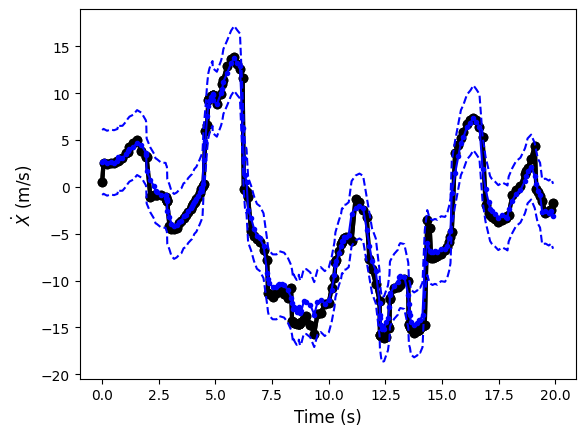

In [67]:
plt.plot(time_array[:plt_idx], Xdot[0,:plt_idx], '-ko', linewidth=3)
plt.plot(time_array[:plt_idx], Xdot[0,:plt_idx], '-ko', linewidth=3)
plt.plot(time_array[:plt_idx], Xdot_pred[0,:plt_idx], '-bo', markersize=3)

plt.plot(time_array[:plt_idx], Xdot_pred[0,:plt_idx] - Xdot_var[0,:plt_idx], '--b')
plt.plot(time_array[:plt_idx], Xdot_pred[0,:plt_idx] + Xdot_var[0,:plt_idx], '--b')


plt.xlabel("Time (s)", fontsize=12), plt.ylabel(r"$\dot{X}$ (m/s)", fontsize=12)

(Text(0.5, 0, 'Time (s)'), Text(0, 0.5, '$\\dot{Y}$ (m/s)'))

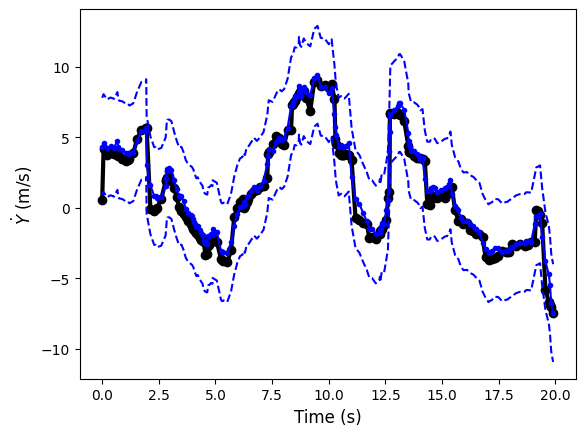

In [68]:
plt.plot(time_array[:plt_idx], Ydot[0,:plt_idx], '-ko', linewidth=3)
plt.plot(time_array[:plt_idx], Ydot_pred[0,:plt_idx], '-bo', markersize=3)

plt.plot(time_array[:plt_idx], Ydot_pred[0,:plt_idx] - Ydot_var[0,:plt_idx], '--b')
plt.plot(time_array[:plt_idx], Ydot_pred[0,:plt_idx] + Ydot_var[0,:plt_idx], '--b')

plt.xlabel("Time (s)", fontsize=12), plt.ylabel(r"$\dot{Y}$ (m/s)", fontsize=12)

(Text(0.5, 0, 'Time (s)'), Text(0, 0.5, '$\\dot{Z}$ (m)'))

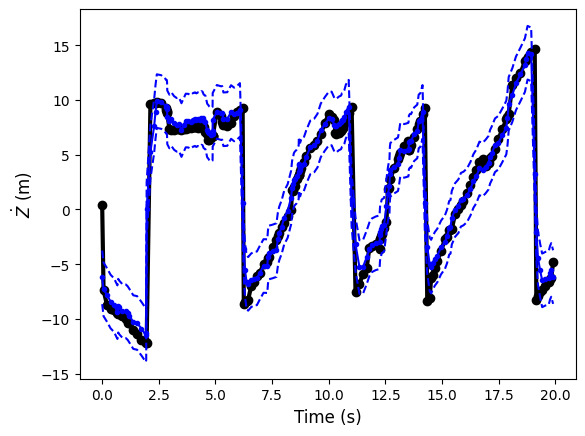

In [69]:
plt.plot(time_array[:plt_idx], Zdot[0,:plt_idx], '-ko', linewidth=3)
plt.plot(time_array[:plt_idx], Zdot_pred[0,:plt_idx], '-bo', markersize=3)

plt.plot(time_array[:plt_idx], Zdot_pred[0,:plt_idx] - Zdot_var[0,:plt_idx], '--b')
plt.plot(time_array[:plt_idx], Zdot_pred[0,:plt_idx] + Zdot_var[0,:plt_idx], '--b')

plt.xlabel("Time (s)", fontsize=12), plt.ylabel(r"$\dot{Z}$ (m)", fontsize=12)

(Text(0.5, 0, 'Time (s)'), Text(0, 0.5, '$\\ddot{X}$ (m/s)'))

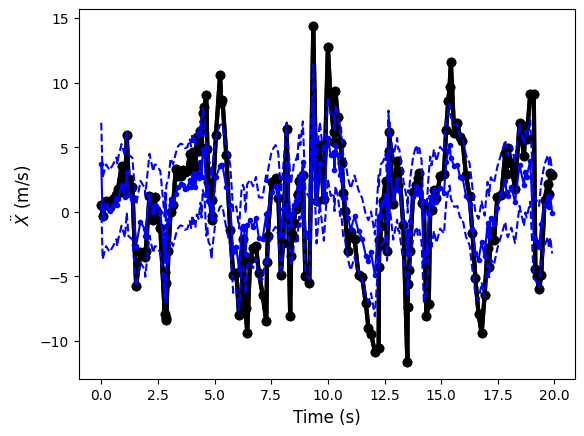

In [70]:
plt.plot(time_array[:plt_idx], Xddot[0,:plt_idx], '-ko', linewidth=3)
plt.plot(time_array[:plt_idx], Xddot[0,:plt_idx], '-ko', linewidth=3)
plt.plot(time_array[:plt_idx], Xddot_pred[0,:plt_idx], '-bo', markersize=3)

plt.plot(time_array[:plt_idx], Xddot_pred[0,:plt_idx] - Xddot_var[0,:plt_idx], '--b')
plt.plot(time_array[:plt_idx], Xddot_pred[0,:plt_idx] + Xddot_var[0,:plt_idx], '--b')


plt.xlabel("Time (s)", fontsize=12), plt.ylabel(r"$\ddot{X}$ (m/s)", fontsize=12)

(Text(0.5, 0, 'Time (s)'), Text(0, 0.5, '$\\ddot{Y}$ (m/s)'))

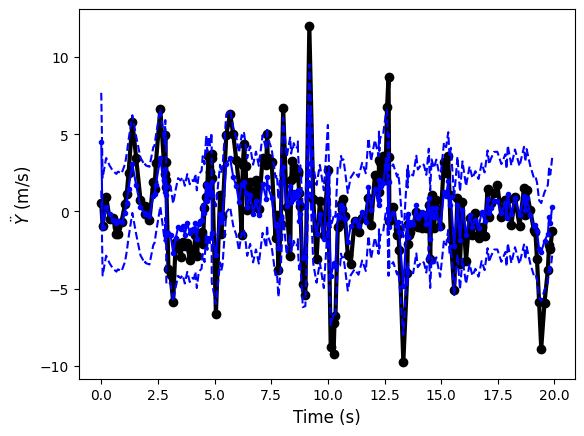

In [71]:
plt.plot(time_array[:plt_idx], Yddot[0,:plt_idx], '-ko', linewidth=3)
plt.plot(time_array[:plt_idx], Yddot_pred[0,:plt_idx], '-bo', markersize=3)

plt.plot(time_array[:plt_idx], Yddot_pred[0,:plt_idx] - Yddot_var[0,:plt_idx], '--b')
plt.plot(time_array[:plt_idx], Yddot_pred[0,:plt_idx] + Yddot_var[0,:plt_idx], '--b')

plt.xlabel("Time (s)", fontsize=12), plt.ylabel(r"$\ddot{Y}$ (m/s)", fontsize=12)

(Text(0.5, 0, 'Time (s)'), Text(0, 0.5, '$\\ddot{Z}$ (m/s)'))

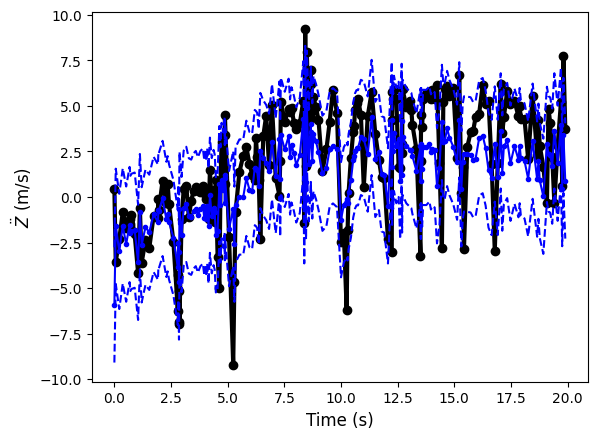

In [72]:
plt.plot(time_array[:plt_idx], Zddot[0,:plt_idx], '-ko', linewidth=3)
plt.plot(time_array[:plt_idx], Zddot_pred[0,:plt_idx], '-bo', markersize=3)

plt.plot(time_array[:plt_idx], Zddot_pred[0,:plt_idx] - Zddot_var[0,:plt_idx], '--b')
plt.plot(time_array[:plt_idx], Zddot_pred[0,:plt_idx] + Zddot_var[0,:plt_idx], '--b')


plt.xlabel("Time (s)", fontsize=12), plt.ylabel(r"$\ddot{Z}$ (m/s)", fontsize=12)

(Text(0.5, 0, 'Time (s)'), Text(0, 0.5, '$\\omega_{x}$ (rad/s)'))

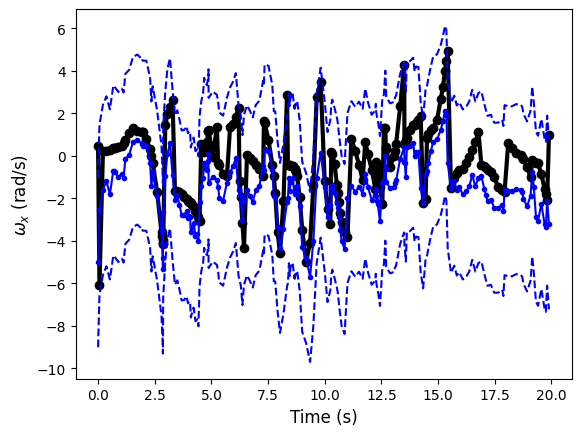

In [73]:
plt.plot(time_array[:plt_idx], ωx[0,:plt_idx], '-ko', linewidth=3)
plt.plot(time_array[:plt_idx], ωx_pred[0,:plt_idx], '-bo', markersize=3)

plt.plot(time_array[:plt_idx], ωx_pred[0,:plt_idx] - ωx_var[0,:plt_idx], '--b')
plt.plot(time_array[:plt_idx], ωx_pred[0,:plt_idx] + ωx_var[0,:plt_idx], '--b')

plt.xlabel("Time (s)", fontsize=12), plt.ylabel(r"$\omega_{x}$ (rad/s)", fontsize=12)

(Text(0.5, 0, 'Time (s)'), Text(0, 0.5, '$\\omega_y$ (rad/s)'))

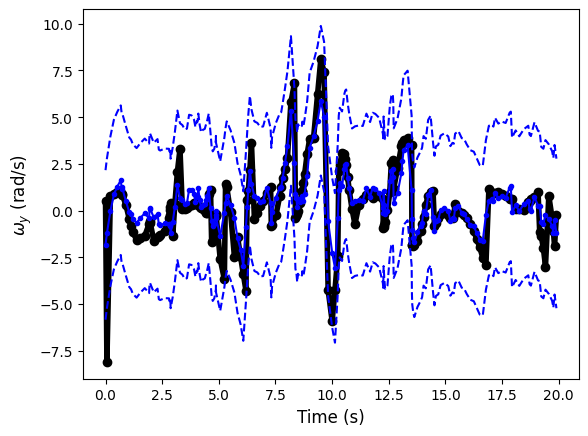

In [74]:
plt.plot(time_array[:plt_idx], ωy[0,:plt_idx], '-ko', linewidth=4)
plt.plot(time_array[:plt_idx], ωy_pred[0,:plt_idx], '-bo', markersize=3)

plt.plot(time_array[:plt_idx], ωy_pred[0,:plt_idx] - ωy_var[0,:plt_idx], '--b')
plt.plot(time_array[:plt_idx], ωy_pred[0,:plt_idx] + ωy_var[0,:plt_idx], '--b')

plt.xlabel("Time (s)", fontsize=12), plt.ylabel(r"$\omega_y$ (rad/s)", fontsize=12)

(Text(0.5, 0, 'Time (s)'), Text(0, 0.5, '$\\omega_{z}$ (rad/s)'))

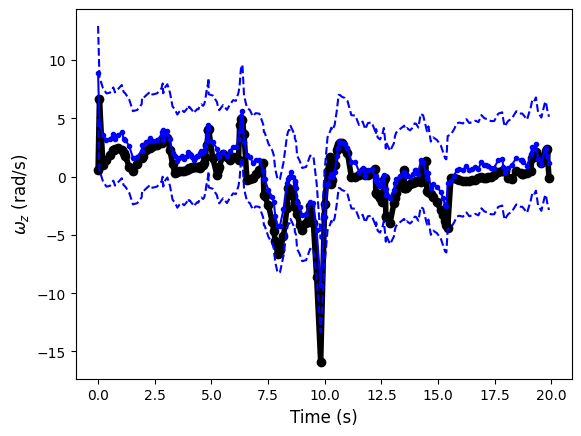

In [75]:
plt.plot(time_array[:plt_idx], ωz[0,:plt_idx], '-ko', linewidth=4)
plt.plot(time_array[:plt_idx], ωz_pred[0,:plt_idx], '-bo', markersize=3)

plt.plot(time_array[:plt_idx], ωz_pred[0,:plt_idx] - ωz_var[0,:plt_idx], '--b')
plt.plot(time_array[:plt_idx], ωz_pred[0,:plt_idx] + ωz_var[0,:plt_idx], '--b')

plt.xlabel("Time (s)", fontsize=12), plt.ylabel(r"$\omega_{z}$ (rad/s)", fontsize=12)

(Text(0.5, 0, 'Time (s)'), Text(0, 0.5, '$\\dot{\\omega}_{x}$ (rad/s^{2})'))

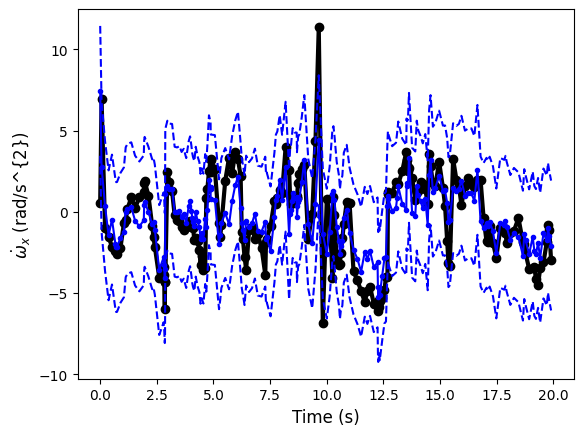

In [76]:
plt.plot(time_array[:plt_idx], ωxdot[0,:plt_idx], '-ko', linewidth=3)
plt.plot(time_array[:plt_idx], ωxdot_pred[0,:plt_idx], '-bo', markersize=3)

plt.plot(time_array[:plt_idx], ωxdot_pred[0,:plt_idx] - ωxdot_var[0,:plt_idx], '--b')
plt.plot(time_array[:plt_idx], ωxdot_pred[0,:plt_idx] + ωxdot_var[0,:plt_idx], '--b')

plt.xlabel("Time (s)", fontsize=12), plt.ylabel(r"$\dot{\omega}_{x}$ (rad/s^{2})", fontsize=12)

(Text(0.5, 0, 'Time (s)'), Text(0, 0.5, '$\\dot{\\omega}_{y}$ (rad/s^{2})'))

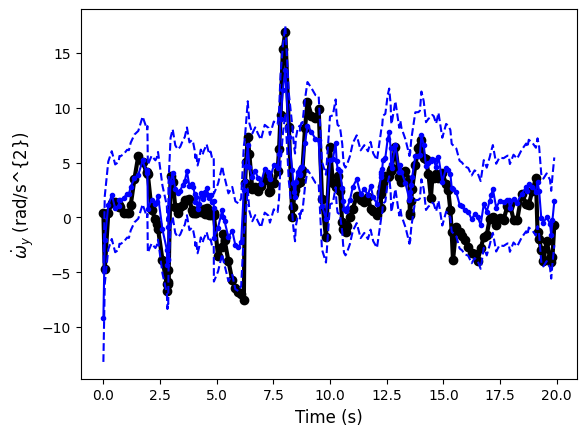

In [77]:
plt.plot(time_array[:plt_idx], ωydot[0,:plt_idx], '-ko', linewidth=3)
plt.plot(time_array[:plt_idx], ωydot_pred[0,:plt_idx], '-bo', markersize=3)

plt.plot(time_array[:plt_idx], ωydot_pred[0,:plt_idx] - ωydot_var[0,:plt_idx], '--b')
plt.plot(time_array[:plt_idx], ωydot_pred[0,:plt_idx] + ωydot_var[0,:plt_idx], '--b')

plt.xlabel("Time (s)", fontsize=12), plt.ylabel(r"$\dot{\omega}_{y}$ (rad/s^{2})", fontsize=12)

(Text(0.5, 0, 'Time (s)'), Text(0, 0.5, '$\\dot{\\omega}_{z}$ (rad/s^{2})'))

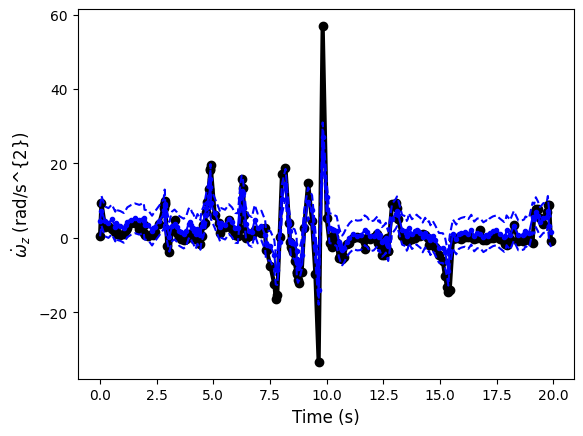

In [78]:
plt.plot(time_array[:plt_idx], ωzdot[0,:plt_idx], '-ko', linewidth=3)
plt.plot(time_array[:plt_idx], ωzdot_pred[0,:plt_idx], '-bo', markersize=3)

plt.plot(time_array[:plt_idx], ωzdot_pred[0,:plt_idx] - ωzdot_var[0,:plt_idx], '--b')
plt.plot(time_array[:plt_idx], ωzdot_pred[0,:plt_idx] + ωzdot_var[0,:plt_idx], '--b')

plt.xlabel("Time (s)", fontsize=12), plt.ylabel(r"$\dot{\omega}_{z}$ (rad/s^{2})", fontsize=12)